In [1]:
# =============================================================================
# ARSENAL 2–1 CHELSEA — PLAYER DECISION SUPPORT MODEL
# STEP 1 — DATA QUALITY & STANDARDISATION
# =============================================================================
#
# Purpose:
#   1. Create the player dataset from the supplied match data
#   2. Standardise player names
#   3. Convert statistical columns to numeric
#   4. Handle missing values correctly
#   5. Check duplicate players
#   6. Validate minutes played
#   7. Detect impossible negative values
#   8. Validate xG / goals / finishing-difference relationships
#   9. Flag small-minute appearances
#  10. Produce a clean dataset for Step 2
#
# IMPORTANT:
#   Missing values are NOT automatically converted to zero.
#   A blank means "data unavailable/not recorded", while 0 means
#   "the player recorded zero of that event".
#
# =============================================================================

import pandas as pd
import numpy as np

from IPython.display import display


# =============================================================================
# 1. RAW MATCH DATA
# =============================================================================

data = [
    ["Danny Welbeck", 3, 1, 0, 0, 0, 0, np.nan, 0, 0, 0, 0, 0, 0],
    ["Emiliano Martínez", 90, 19, np.nan, 0, 0, 8, np.nan, np.nan, 0, 0, 0, 0, 0],
    ["Martin Ødegaard", 77, 48, 4, 0, 0, 3, 3, 0, 2, 0.6883089989, 0.3441544995, 1, 0.3116910011],
    ["David Raya", 90, 21, np.nan, 0, 0, 11, np.nan, np.nan, 0, 0, 0, 0, 0],
    ["Mikel Merino", 13, 8, 0, 0, 0, 0, np.nan, 0, 0, 0, 0, 0, 0],
    ["Declan Rice", 90, 62, 1, 0, 1, 1, 0, 2, 1, 0.0428596139, 0.0428596139, 0, -0.0428596139],
    ["Viktor Gyökeres", 12, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    ["Ezri Konsa", 90, 41, 0, 3, 1, 5, 5, 3, 0, 0, 0, 0, 0],
    ["Kai Havertz", 78, 19, 3, 0, 1, 0, 2, 4, 3, 0.1984715872, 0.06615719572, 1, 0.8015284128],
    ["Ben White", 90, 25, 0, 2, 0, 4, 5, 0, 0, 0, 0, 0, 0],
    ["Gabriel", 90, 30, 0, 0, 1, 4, np.nan, 1, 2, 0.6559619755, 0.3279809877, 0, -0.6559619755],
    ["Reece James", 90, 42, 1, 0, 1, 6, 1, 2, 3, 0.05983041693, 0.01994347231, 0, -0.05983041693],
    ["Pedro Neto", 81, 18, 2, 1, 2, 4, 3, 1, 1, 0.09782776982, 0.09782776982, 0, -0.09782776982],
    ["Morgan Rogers", 87, 21, 1, 0, 0, 5, 1, 1, 3, 0.1093445821, 0.03644819402, 1, 0.8906554179],
    ["Wesley Fofana", 90, 43, 2, 3, 2, 3, 5, 1, 0, 0, 0, 0, 0],
    ["Maxence Lacroix", 90, 42, 0, 1, 1, 2, 1, 3, 0, 0, 0, 0, 0],
    ["Bukayo Saka", 89, 24, 1, 1, 1, 2, 5, 0, 4, 0.5468731243, 0.1367182811, 0, -0.5468731243],
    ["Pep Chavarría", 30, 7, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    ["João Pedro", 90, 13, 2, 0, 0, 1, 6, 4, 1, 0.01626319624, 0.01626319624, 0, -0.01626319624],
    ["Martín Zubimendi", 23, 8, 0, 0, 3, 0, 0, 1, 1, 0.1103859097, 0.1103859097, 0, -0.1103859097],
    ["Noni Madueke", 1, 3, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    ["Cole Palmer", 90, 37, 1, 0, 0, 3, 1, 0, 3, 0.07932881452, 0.02644293817, 0, -0.07932881452],
    ["Riccardo Calafiori", 67, 19, 0, 1, 0, 1, 1, 0, 2, 0.5633553341, 0.2816776671, 0, -0.5633553341],
    ["Piero Hincapié", 23, 10, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    ["Christos Tzolis", 90, 37, 4, 1, 1, 5, 5, 1, 0, 0, 0, 0, 0],
    ["Roméo Lavia", 60, 23, 0, 1, 1, 3, 4, 1, 0, 0, 0, 0, 0],
    ["Malo Gusto", 30, 16, 0, 2, 0, 2, 2, 1, 1, 0.03822280094, 0.03822280094, 0, -0.03822280094],
    ["Josh Acheampong", 90, 12, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    ["Myles Lewis-Skelly", 67, 28, 1, 0, 0, 2, 1, 1, 1, 0.06316274405, 0.06316274405, 0, -0.06316274405],
    ["Jorrel Hato", 60, 11, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 0],
    ["Estêvão", 9, 4, 0, 0, 0, 0, np.nan, 0, 1, 0.02969027497, 0.02969027497, 0, -0.02969027497],
]

columns = [
    "player",
    "minutes",
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won",
    "understat_shots",
    "understat_xG",
    "understat_xG_per_shot",
    "understat_goals",
    "understat_finishing_diff"
]

df_raw = pd.DataFrame(data, columns=columns)


# =============================================================================
# 2. CREATE A WORKING COPY
# =============================================================================

df = df_raw.copy()

print("=" * 80)
print("ARSENAL 2–1 CHELSEA | STEP 1 — DATA QUALITY & STANDARDISATION")
print("=" * 80)

print(f"\nRaw rows: {len(df)}")
print(f"Raw columns: {len(df.columns)}")


# =============================================================================
# 3. STANDARDISE PLAYER NAMES
# =============================================================================

# Basic whitespace cleanup
df["player"] = (
    df["player"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Explicit name standardisation
name_standardisation = {
    "Martin Odegaard": "Martin Ødegaard",
    "Martin Ødegaard": "Martin Ødegaard",
    "Emiliano Martinez": "Emiliano Martínez",
    "Viktor Gyokeres": "Viktor Gyökeres",
    "Joao Pedro": "João Pedro",
    "Martin Zubimendi": "Martín Zubimendi",
    "Romeo Lavia": "Roméo Lavia",
    "Estêvão": "Estêvão",
    "Estevao": "Estêvão",
    "Pep Chavarria": "Pep Chavarría",
}

df["player"] = df["player"].replace(name_standardisation)


# =============================================================================
# 4. IDENTIFY NUMERIC COLUMNS
# =============================================================================

numeric_columns = [
    "minutes",
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won",
    "understat_shots",
    "understat_xG",
    "understat_xG_per_shot",
    "understat_goals",
    "understat_finishing_diff"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# =============================================================================
# 5. CHECK DUPLICATE PLAYER RECORDS
# =============================================================================

duplicate_mask = df.duplicated(subset=["player"], keep=False)

duplicate_players = (
    df.loc[duplicate_mask, "player"]
    .value_counts()
    .rename_axis("player")
    .reset_index(name="records")
)

print("\n" + "-" * 80)
print("DUPLICATE PLAYER CHECK")
print("-" * 80)

if duplicate_players.empty:
    print("✓ No duplicate player records detected.")
else:
    print("⚠ Duplicate player records detected:")
    display(duplicate_players)


# =============================================================================
# 6. CHECK MISSING VALUES
# =============================================================================

missing_report = (
    df.isna()
    .sum()
    .to_frame("missing_values")
)

missing_report["missing_%"] = (
    missing_report["missing_values"] / len(df) * 100
)

missing_report = missing_report[
    missing_report["missing_values"] > 0
].sort_values("missing_values", ascending=False)

print("\n" + "-" * 80)
print("MISSING VALUE CHECK")
print("-" * 80)

if missing_report.empty:
    print("✓ No missing values detected.")
else:
    display(missing_report)


# =============================================================================
# 7. CHECK MINUTES
# =============================================================================

invalid_minutes = df[
    (df["minutes"].isna()) |
    (df["minutes"] < 0) |
    (df["minutes"] > 90)
]

print("\n" + "-" * 80)
print("MINUTES VALIDATION")
print("-" * 80)

if invalid_minutes.empty:
    print("✓ All minutes are between 0 and 90.")
else:
    print("⚠ Invalid minutes detected:")
    display(invalid_minutes[["player", "minutes"]])


# =============================================================================
# 8. FLAG SMALL-MINUTE APPEARANCES
# =============================================================================

MIN_MINUTES_THRESHOLD = 30

df["minutes_flag"] = np.select(
    [
        df["minutes"] < MIN_MINUTES_THRESHOLD,
        df["minutes"] >= MIN_MINUTES_THRESHOLD
    ],
    [
        "SMALL_SAMPLE",
        "SUFFICIENT_SAMPLE"
    ],
    default="MISSING_MINUTES"
)

print("\n" + "-" * 80)
print("MINUTES SAMPLE CHECK")
print("-" * 80)

small_sample = df[df["minutes"] < MIN_MINUTES_THRESHOLD][
    ["player", "minutes", "minutes_flag"]
].sort_values("minutes")

print(
    f"Players below {MIN_MINUTES_THRESHOLD} minutes: "
    f"{len(small_sample)}"
)

display(small_sample)


# =============================================================================
# 9. CHECK NEGATIVE VALUES
# =============================================================================

event_columns = [
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won",
    "understat_shots",
    "understat_xG",
    "understat_xG_per_shot",
    "understat_goals"
]

negative_records = []

for col in event_columns:
    mask = df[col] < 0

    if mask.any():
        for player in df.loc[mask, "player"]:
            negative_records.append({
                "player": player,
                "column": col,
                "value": df.loc[
                    df["player"] == player, col
                ].iloc[0]
            })

negative_report = pd.DataFrame(negative_records)

print("\n" + "-" * 80)
print("NEGATIVE VALUE CHECK")
print("-" * 80)

if negative_report.empty:
    print("✓ No impossible negative event values detected.")
else:
    print("⚠ Negative values detected:")
    display(negative_report)


# =============================================================================
# 10. CHECK XG PER SHOT CONSISTENCY
# =============================================================================

# Expected relationship:
#
# xG per shot ≈ total xG / total shots
#
# Allow a small tolerance for rounding.

df["calculated_xG_per_shot"] = np.where(
    df["understat_shots"] > 0,
    df["understat_xG"] / df["understat_shots"],
    0
)

df["xG_per_shot_difference"] = (
    df["understat_xG_per_shot"]
    - df["calculated_xG_per_shot"]
).abs()

xg_consistency_issues = df[
    (
        (df["understat_shots"] > 0) &
        (df["xG_per_shot_difference"] > 0.01)
    )
    |
    (
        (df["understat_shots"] == 0) &
        (df["understat_xG"] != 0)
    )
][
    [
        "player",
        "understat_shots",
        "understat_xG",
        "understat_xG_per_shot",
        "calculated_xG_per_shot",
        "xG_per_shot_difference"
    ]
]

print("\n" + "-" * 80)
print("xG / xG PER SHOT CONSISTENCY")
print("-" * 80)

if xg_consistency_issues.empty:
    print("✓ xG per shot values are internally consistent.")
else:
    print("⚠ Potential xG consistency issues:")
    display(xg_consistency_issues)


# =============================================================================
# 11. CHECK GOALS CANNOT EXCEED SHOTS
# =============================================================================

goal_shot_issues = df[
    df["understat_goals"] > df["understat_shots"]
][
    [
        "player",
        "understat_shots",
        "understat_goals"
    ]
]

print("\n" + "-" * 80)
print("GOALS vs SHOTS VALIDATION")
print("-" * 80)

if goal_shot_issues.empty:
    print("✓ No player has more goals than shots.")
else:
    print("⚠ Impossible goals/shots relationship detected:")
    display(goal_shot_issues)


# =============================================================================
# 12. VALIDATE FINISHING DIFFERENCE
# =============================================================================

# Expected relationship:
#
# finishing difference = goals - xG

df["calculated_finishing_diff"] = (
    df["understat_goals"] - df["understat_xG"]
)

df["finishing_diff_error"] = (
    df["understat_finishing_diff"]
    - df["calculated_finishing_diff"]
).abs()

finishing_issues = df[
    df["finishing_diff_error"] > 0.01
][
    [
        "player",
        "understat_xG",
        "understat_goals",
        "understat_finishing_diff",
        "calculated_finishing_diff",
        "finishing_diff_error"
    ]
]

print("\n" + "-" * 80)
print("FINISHING DIFFERENCE VALIDATION")
print("-" * 80)

if finishing_issues.empty:
    print("✓ Finishing difference values are internally consistent.")
else:
    print("⚠ Potential finishing-difference issues:")
    display(finishing_issues)


# =============================================================================
# 13. CHECK DUPLICATE PLAYER NAMES AFTER STANDARDISATION
# =============================================================================

post_standardisation_duplicates = (
    df["player"]
    .value_counts()
    .reset_index()
)

post_standardisation_duplicates.columns = [
    "player",
    "records"
]

post_standardisation_duplicates = post_standardisation_duplicates[
    post_standardisation_duplicates["records"] > 1
]

print("\n" + "-" * 80)
print("POST-STANDARDISATION DUPLICATE CHECK")
print("-" * 80)

if post_standardisation_duplicates.empty:
    print("✓ Every player has one record.")
else:
    print("⚠ Duplicate players remain:")
    display(post_standardisation_duplicates)


# =============================================================================
# 14. DATA COMPLETENESS SCORE
# =============================================================================
#
# This is NOT a player-performance score.
#
# It simply tells us how complete the player's data is.

quality_columns = [
    "minutes",
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won",
    "understat_shots",
    "understat_xG",
    "understat_xG_per_shot",
    "understat_goals",
    "understat_finishing_diff"
]

df["data_completeness_%"] = (
    df[quality_columns].notna().mean(axis=1) * 100
).round(1)


# =============================================================================
# 15. CREATE DATA QUALITY STATUS
# =============================================================================

df["data_quality_status"] = np.select(
    [
        df["minutes"].isna(),
        df["minutes"] < MIN_MINUTES_THRESHOLD,
        df["data_completeness_%"] < 80,
        df["data_completeness_%"] >= 80
    ],
    [
        "REVIEW_MINUTES",
        "SMALL_SAMPLE",
        "REVIEW_MISSING_DATA",
        "READY"
    ],
    default="REVIEW"
)


# =============================================================================
# 16. CREATE FINAL CLEAN DATASET
# =============================================================================

# Remove temporary validation columns from the main analytical dataset.

temporary_columns = [
    "calculated_xG_per_shot",
    "xG_per_shot_difference",
    "calculated_finishing_diff",
    "finishing_diff_error"
]

df_clean = df.drop(columns=temporary_columns)


# =============================================================================
# 17. SORT BY MINUTES
# =============================================================================

df_clean = df_clean.sort_values(
    ["minutes", "player"],
    ascending=[False, True]
).reset_index(drop=True)


# =============================================================================
# 18. FINAL DATA QUALITY REPORT
# =============================================================================

print("\n" + "=" * 80)
print("FINAL DATA QUALITY SUMMARY")
print("=" * 80)

print(f"Players              : {len(df_clean)}")
print(f"Columns              : {len(df_clean.columns)}")
print(f"Duplicate players    : {df_clean['player'].duplicated().sum()}")
print(f"Missing cells        : {df_clean[quality_columns].isna().sum().sum()}")
print(f"Small-sample players : {(df_clean['minutes'] < MIN_MINUTES_THRESHOLD).sum()}")

print("\nData quality status:")
display(
    df_clean["data_quality_status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="players")
)


# =============================================================================
# 19. PLAYER DATA QUALITY TABLE
# =============================================================================

quality_table = df_clean[
    [
        "player",
        "minutes",
        "data_completeness_%",
        "minutes_flag",
        "data_quality_status"
    ]
].copy()

print("\n" + "-" * 80)
print("PLAYER DATA QUALITY")
print("-" * 80)

display(quality_table)


# =============================================================================
# 20. FINAL CLEAN DATASET
# =============================================================================

print("\n" + "=" * 80)
print("CLEAN DATASET PREVIEW")
print("=" * 80)

display(df_clean.head(10))


# =============================================================================
# 21. EXPORT CLEAN DATASET
# =============================================================================

OUTPUT_FILE = "Arsenal_Chelsea_MD3_step1_clean_player_data.csv"

df_clean.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("\n" + "=" * 80)
print("STEP 1 COMPLETE")
print("=" * 80)

print(f"Clean dataset saved as:")
print(OUTPUT_FILE)

print("\nNext step:")
print("STEP 2 — Per-90 Metrics & Sample-Size Controls")

ARSENAL 2–1 CHELSEA | STEP 1 — DATA QUALITY & STANDARDISATION

Raw rows: 31
Raw columns: 14

--------------------------------------------------------------------------------
DUPLICATE PLAYER CHECK
--------------------------------------------------------------------------------
✓ No duplicate player records detected.

--------------------------------------------------------------------------------
MISSING VALUE CHECK
--------------------------------------------------------------------------------


,missing_values,missing_%
ground_duels_won,6,19.354839
chances_created,2,6.451613
aerial_duels_won,2,6.451613



--------------------------------------------------------------------------------
MINUTES VALIDATION
--------------------------------------------------------------------------------
✓ All minutes are between 0 and 90.

--------------------------------------------------------------------------------
MINUTES SAMPLE CHECK
--------------------------------------------------------------------------------
Players below 30 minutes: 7


,player,minutes,minutes_flag
20,Noni Madueke,1,SMALL_SAMPLE
0,Danny Welbeck,3,SMALL_SAMPLE
30,Estêvão,9,SMALL_SAMPLE
6,Viktor Gyökeres,12,SMALL_SAMPLE
4,Mikel Merino,13,SMALL_SAMPLE
19,Martín Zubimendi,23,SMALL_SAMPLE
23,Piero Hincapié,23,SMALL_SAMPLE



--------------------------------------------------------------------------------
NEGATIVE VALUE CHECK
--------------------------------------------------------------------------------
✓ No impossible negative event values detected.

--------------------------------------------------------------------------------
xG / xG PER SHOT CONSISTENCY
--------------------------------------------------------------------------------
✓ xG per shot values are internally consistent.

--------------------------------------------------------------------------------
GOALS vs SHOTS VALIDATION
--------------------------------------------------------------------------------
✓ No player has more goals than shots.

--------------------------------------------------------------------------------
FINISHING DIFFERENCE VALIDATION
--------------------------------------------------------------------------------
✓ Finishing difference values are internally consistent.

-----------------------------------------------

...


--------------------------------------------------------------------------------
PLAYER DATA QUALITY
--------------------------------------------------------------------------------


,player,minutes,data_completeness_%,minutes_flag,data_quality_status
0,Ben White,90,100.0,SUFFICIENT_SAMPLE,READY
1,Christos Tzolis,90,100.0,SUFFICIENT_SAMPLE,READY
2,Cole Palmer,90,100.0,SUFFICIENT_SAMPLE,READY
3,David Raya,90,76.9,SUFFICIENT_SAMPLE,REVIEW_MISSING_DATA
4,Declan Rice,90,100.0,SUFFICIENT_SAMPLE,READY
5,Emiliano Martínez,90,76.9,SUFFICIENT_SAMPLE,REVIEW_MISSING_DATA
6,Ezri Konsa,90,100.0,SUFFICIENT_SAMPLE,READY
7,Gabriel,90,92.3,SUFFICIENT_SAMPLE,READY
8,Josh Acheampong,90,100.0,SUFFICIENT_SAMPLE,READY
9,João Pedro,90,100.0,SUFFICIENT_SAMPLE,READY



CLEAN DATASET PREVIEW


,player,minutes,passes,chances_created,tackles,interceptions,recoveries,ground_duels_won,aerial_duels_won,understat_shots,understat_xG,understat_xG_per_shot,understat_goals,understat_finishing_diff,minutes_flag,data_completeness_%,data_quality_status
0,Ben White,90,25,0.0,2,0,4,5.0,0.0,0,0.000000,0.000000,0,0.000000,SUFFICIENT_SAMPLE,100.0,READY
1,Christos Tzolis,90,37,4.0,1,1,5,5.0,1.0,0,0.000000,0.000000,0,0.000000,SUFFICIENT_SAMPLE,100.0,READY
2,Cole Palmer,90,37,1.0,0,0,3,1.0,0.0,3,0.079329,0.026443,0,-0.079329,SUFFICIENT_SAMPLE,100.0,READY
3,David Raya,90,21,NaN,0,0,11,NaN,NaN,0,0.000000,0.000000,0,0.000000,SUFFICIENT_SAMPLE,76.9,REVIEW_MISSING_DATA
4,Declan Rice,90,62,1.0,0,1,1,0.0,2.0,1,0.042860,0.042860,0,-0.042860,SUFFICIENT_SAMPLE,100.0,READY
5,Emiliano Martínez,90,19,NaN,0,0,8,NaN,NaN,0,0.000000,0.000000,0,0.000000,SUFFICIENT_SAMPLE,76.9,REVIEW_MISSING_DATA
6,Ezri Konsa,90,41,0.0,3,1,5,5.0,3.0,0,0.000000,0.000000,0,0.000000,SUFFICIENT_SAMPLE,100.0,READY
7,Gabriel,90,30,0.0,0,1,4,NaN,1.0,2,0.655962,0.327981,0,-0.655962,SUFFICIENT_SAMPLE,92.3,READY
8,Josh Acheampong,90,12,0.0,0,0,1,0.0,0.0,0,0.000000,0.000000,0,0.000000,SUFFICIENT_SAMPLE,100.0,READY
9,João Pedro,90,13,2.0,0,0,1,6.0,4.0,1,0.016263,0.016263,0,-0.016263,SUFFICIENT_SAMPLE,100.0,READY



STEP 1 COMPLETE
Clean dataset saved as:
Arsenal_Chelsea_MD3_step1_clean_player_data.csv

Next step:
STEP 2 — Per-90 Metrics & Sample-Size Controls


In [2]:
# =============================================================================
# ARSENAL 2–1 CHELSEA — PLAYER DECISION SUPPORT MODEL
# STEP 2 — PER-90 METRICS & SAMPLE-SIZE CONTROLS
# =============================================================================
#
# INPUT:
#   df_clean  -> output from Step 1
#
# PURPOSE:
#   1. Calculate per-90 performance metrics
#   2. Preserve raw match totals
#   3. Flag small-minute appearances
#   4. Apply sample-size controls
#   5. Create a "rating eligible" population
#   6. Prevent tiny appearances from dominating future rankings
#
# IMPORTANT:
#   Raw per-90 numbers are useful for description.
#   Sample-adjusted metrics are safer for PLAYER RATING.
#
# =============================================================================

import pandas as pd
import numpy as np
from IPython.display import display


# =============================================================================
# 1. SAFETY CHECK
# =============================================================================

if "df_clean" not in globals():
    raise NameError(
        "df_clean was not found. Please run Step 1 first."
    )

df_step2 = df_clean.copy()

print("=" * 80)
print("ARSENAL 2–1 CHELSEA | STEP 2 — PER-90 METRICS & SAMPLE-SIZE CONTROLS")
print("=" * 80)

print(f"\nInput players: {len(df_step2)}")


# =============================================================================
# 2. CONFIGURATION
# =============================================================================

# Minimum minutes before a player is considered sufficiently sampled
MIN_MINUTES = 30

# Minimum minutes before a player's per-90 numbers are considered
# "stable enough" to be used directly in future rating calculations.
RATING_MIN_MINUTES = 60

# Maximum possible match duration.
MATCH_MINUTES = 90


# =============================================================================
# 3. ENSURE MINUTES ARE NUMERIC
# =============================================================================

df_step2["minutes"] = pd.to_numeric(
    df_step2["minutes"],
    errors="coerce"
)


# =============================================================================
# 4. DEFINE PER-90 VARIABLES
# =============================================================================

per90_source_columns = [
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won",
    "understat_shots",
    "understat_xG",
    "understat_goals"
]


# =============================================================================
# 5. FUNCTION FOR PER-90 CALCULATION
# =============================================================================

def calculate_per90(value, minutes):
    """
    Convert a match total into a per-90 rate.

    If minutes are missing or zero, return NaN.
    """

    if pd.isna(minutes) or minutes <= 0:
        return np.nan

    if pd.isna(value):
        return np.nan

    return (value / minutes) * 90


# =============================================================================
# 6. CALCULATE RAW PER-90 METRICS
# =============================================================================

for col in per90_source_columns:

    new_col = f"{col}_per90"

    df_step2[new_col] = df_step2.apply(
        lambda row: calculate_per90(
            row[col],
            row["minutes"]
        ),
        axis=1
    )


# =============================================================================
# 7. xG PER SHOT
# =============================================================================
#
# We already validated Understat xG per shot in Step 1.
#
# We retain the original metric rather than recalculating it unnecessarily.

df_step2["xG_per_shot"] = df_step2["understat_xG_per_shot"]


# =============================================================================
# 8. FINISHING DIFFERENCE PER 90
# =============================================================================
#
# Finishing difference:
#
#     goals - xG
#
# We also create a per-90 version.
#
# This is descriptive only.
# We will NOT treat one-match finishing overperformance as proof
# of sustainable finishing ability.

df_step2["finishing_diff_per90"] = np.where(
    df_step2["minutes"] > 0,
    (
        df_step2["understat_finishing_diff"]
        / df_step2["minutes"]
    ) * 90,
    np.nan
)


# =============================================================================
# 9. MINUTES BANDS
# =============================================================================

def assign_minutes_band(minutes):

    if pd.isna(minutes):
        return "MISSING"

    if minutes < 15:
        return "<15 MIN"

    elif minutes < 30:
        return "15–29 MIN"

    elif minutes < 60:
        return "30–59 MIN"

    elif minutes < 75:
        return "60–74 MIN"

    elif minutes < 90:
        return "75–89 MIN"

    else:
        return "90 MIN"


df_step2["minutes_band"] = df_step2["minutes"].apply(
    assign_minutes_band
)


# =============================================================================
# 10. SAMPLE-SIZE CLASSIFICATION
# =============================================================================

def classify_sample(minutes):

    if pd.isna(minutes):
        return "NO MINUTES"

    if minutes < 30:
        return "SMALL SAMPLE"

    elif minutes < 60:
        return "LIMITED SAMPLE"

    elif minutes < 75:
        return "GOOD SAMPLE"

    else:
        return "STRONG SAMPLE"


df_step2["sample_size_class"] = df_step2["minutes"].apply(
    classify_sample
)


# =============================================================================
# 11. RATING ELIGIBILITY
# =============================================================================
#
# A player needs at least 60 minutes for their per-90 numbers to enter
# the main rating population.
#
# This DOES NOT mean players below 60 minutes are ignored.
#
# They remain available for:
#   - impact-sub analysis
#   - match storytelling
#   - tactical analysis
#
# They are simply protected from contaminating the main ranking.

df_step2["rating_eligible"] = (
    df_step2["minutes"] >= RATING_MIN_MINUTES
)


# =============================================================================
# 12. SMALL-SAMPLE FLAG
# =============================================================================

df_step2["small_sample_flag"] = (
    df_step2["minutes"] < MIN_MINUTES
)


# =============================================================================
# 13. SAMPLE CONFIDENCE FACTOR
# =============================================================================
#
# This is deliberately conservative.
#
# Formula:
#
#     confidence = sqrt(minutes / 90)
#
# capped at 1.
#
# Examples:
#
# 90 min -> 1.00
# 60 min -> 0.82
# 30 min -> 0.58
# 15 min -> 0.41
#  3 min -> 0.18
#  1 min -> 0.11
#
# This allows short appearances to retain information without allowing
# them to dominate future rankings.
#
# IMPORTANT:
# This is a modelling control, NOT a claim that statistical uncertainty
# literally follows this exact formula.

df_step2["sample_confidence"] = np.where(
    df_step2["minutes"] > 0,
    np.minimum(
        np.sqrt(df_step2["minutes"] / MATCH_MINUTES),
        1.0
    ),
    0
)

df_step2["sample_confidence"] = (
    df_step2["sample_confidence"]
    .round(3)
)


# =============================================================================
# 14. SAMPLE-ADJUSTED PER-90 METRICS
# =============================================================================
#
# These metrics will be useful later for player ratings.
#
# Raw per90:
#
#     performance / minutes * 90
#
# Sample-adjusted:
#
#     raw_per90 * sample_confidence
#
# Again:
# this does NOT change the player's actual performance.
# It only controls how much confidence the rating model places on it.

per90_columns = [
    "passes_per90",
    "chances_created_per90",
    "tackles_per90",
    "interceptions_per90",
    "recoveries_per90",
    "ground_duels_won_per90",
    "aerial_duels_won_per90",
    "understat_shots_per90",
    "understat_xG_per90",
    "understat_goals_per90",
    "finishing_diff_per90"
]

for col in per90_columns:

    adjusted_col = col.replace(
        "_per90",
        "_per90_adjusted"
    )

    df_step2[adjusted_col] = (
        df_step2[col]
        * df_step2["sample_confidence"]
    )


# =============================================================================
# 15. HANDLE EXTREME PER-90 VALUES FOR DISPLAY
# =============================================================================
#
# We DO NOT modify the underlying numbers.
#
# This is only a display helper so that very small samples can be
# immediately identified in tables.

display_columns = [
    "passes_per90",
    "chances_created_per90",
    "tackles_per90",
    "interceptions_per90",
    "recoveries_per90",
    "ground_duels_won_per90",
    "aerial_duels_won_per90",
    "understat_shots_per90",
    "understat_xG_per90",
    "understat_goals_per90",
    "finishing_diff_per90"
]

for col in display_columns:
    df_step2[col] = df_step2[col].round(3)


# =============================================================================
# 16. CREATE CORE PERFORMANCE TABLE
# =============================================================================

core_per90_table = df_step2[
    [
        "player",
        "minutes",
        "sample_size_class",
        "rating_eligible",
        "sample_confidence",
        "passes_per90",
        "chances_created_per90",
        "tackles_per90",
        "interceptions_per90",
        "recoveries_per90",
        "ground_duels_won_per90",
        "aerial_duels_won_per90",
        "understat_shots_per90",
        "understat_xG_per90",
        "understat_goals_per90",
        "finishing_diff_per90"
    ]
].copy()


# =============================================================================
# 17. SORT BY MINUTES
# =============================================================================

core_per90_table = core_per90_table.sort_values(
    ["rating_eligible", "minutes", "player"],
    ascending=[False, False, True]
).reset_index(drop=True)


# =============================================================================
# 18. DISPLAY CORE PER-90 TABLE
# =============================================================================

print("\n" + "-" * 80)
print("CORE PER-90 PERFORMANCE TABLE")
print("-" * 80)

display(core_per90_table)


# =============================================================================
# 19. DISPLAY RATING-ELIGIBLE PLAYERS
# =============================================================================

rating_population = df_step2[
    df_step2["rating_eligible"]
].copy()

rating_population = rating_population.sort_values(
    "minutes",
    ascending=False
)

print("\n" + "-" * 80)
print(
    f"RATING-ELIGIBLE PLAYERS "
    f"(≥ {RATING_MIN_MINUTES} MINUTES)"
)
print("-" * 80)

print(
    f"Eligible players: {len(rating_population)}"
)

display(
    rating_population[
        [
            "player",
            "minutes",
            "sample_size_class",
            "sample_confidence"
        ]
    ]
)


# =============================================================================
# 20. DISPLAY SMALL-SAMPLE PLAYERS
# =============================================================================

small_sample_players = df_step2[
    df_step2["small_sample_flag"]
].copy()

small_sample_players = small_sample_players.sort_values(
    "minutes"
)

print("\n" + "-" * 80)
print(
    f"SMALL-SAMPLE PLAYERS "
    f"(< {MIN_MINUTES} MINUTES)"
)
print("-" * 80)

display(
    small_sample_players[
        [
            "player",
            "minutes",
            "sample_size_class",
            "rating_eligible",
            "sample_confidence"
        ]
    ]
)


# =============================================================================
# 21. FIND TOP RAW PER-90 VALUES
# =============================================================================
#
# This is exploratory only.
#
# It is intentionally NOT the player rating.

exploratory_metrics = [
    "chances_created_per90",
    "understat_shots_per90",
    "understat_xG_per90",
    "understat_goals_per90",
    "tackles_per90",
    "interceptions_per90",
    "recoveries_per90"
]

print("\n" + "-" * 80)
print("EXPLORATORY PER-90 LEADERS")
print("-" * 80)

for metric in exploratory_metrics:

    available = df_step2[
        df_step2[metric].notna()
    ].copy()

    available = available.sort_values(
        metric,
        ascending=False
    )

    print(f"\nTOP 5 — {metric}")

    display(
        available[
            [
                "player",
                "minutes",
                "sample_size_class",
                metric
            ]
        ].head(5)
    )


# =============================================================================
# 22. COMPARE RAW VS SAMPLE-ADJUSTED VALUES
# =============================================================================

comparison_columns = [
    "player",
    "minutes",
    "sample_confidence",
    "chances_created_per90",
    "chances_created_per90_adjusted",
    "understat_xG_per90",
    "understat_xG_per90_adjusted",
    "understat_shots_per90",
    "understat_shots_per90_adjusted"
]

comparison_table = df_step2[
    comparison_columns
].copy()

print("\n" + "-" * 80)
print("RAW vs SAMPLE-ADJUSTED PER-90")
print("-" * 80)

display(
    comparison_table.sort_values(
        "minutes",
        ascending=False
    )
)


# =============================================================================
# 23. CREATE MODEL-READY DATASET
# =============================================================================
#
# This dataset contains:
#
#   - original match totals
#   - per-90 metrics
#   - sample controls
#   - rating eligibility
#
# Nothing important is deleted.

df_step2_model = df_step2.copy()


# =============================================================================
# 24. FINAL COLUMN ORGANISATION
# =============================================================================

priority_columns = [
    "player",
    "minutes",
    "sample_size_class",
    "rating_eligible",
    "sample_confidence",
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won",
    "understat_shots",
    "understat_xG",
    "understat_xG_per_shot",
    "understat_goals",
    "understat_finishing_diff",
    "passes_per90",
    "chances_created_per90",
    "tackles_per90",
    "interceptions_per90",
    "recoveries_per90",
    "ground_duels_won_per90",
    "aerial_duels_won_per90",
    "understat_shots_per90",
    "understat_xG_per90",
    "understat_goals_per90",
    "finishing_diff_per90"
]

# Add adjusted metrics
adjusted_columns = [
    col for col in df_step2_model.columns
    if col.endswith("_per90_adjusted")
]

# Add remaining columns not already included
remaining_columns = [
    col for col in df_step2_model.columns
    if col not in priority_columns
    and col not in adjusted_columns
]

final_columns = (
    priority_columns
    + adjusted_columns
    + remaining_columns
)

df_step2_model = df_step2_model[
    final_columns
]


# =============================================================================
# 25. ROUND NUMERIC OUTPUT
# =============================================================================

for col in df_step2_model.select_dtypes(
    include=[np.number]
).columns:

    if col not in ["minutes"]:
        df_step2_model[col] = (
            df_step2_model[col]
            .round(4)
        )


# =============================================================================
# 26. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("STEP 2 SUMMARY")
print("=" * 80)

print(f"Total players              : {len(df_step2_model)}")
print(
    f"Players ≥ {RATING_MIN_MINUTES} min"
    f"          : {df_step2_model['rating_eligible'].sum()}"
)
print(
    f"Players < {RATING_MIN_MINUTES} min"
    f"           : {(~df_step2_model['rating_eligible']).sum()}"
)
print(
    f"Players < {MIN_MINUTES} min"
    f"           : {df_step2_model['small_sample_flag'].sum()}"
)

print("\nSample-size distribution:")

display(
    df_step2_model[
        "sample_size_class"
    ]
    .value_counts()
    .rename_axis("sample_size_class")
    .reset_index(name="players")
)


# =============================================================================
# 27. SAVE STEP 2 DATASET
# =============================================================================

STEP2_OUTPUT = (
    "Arsenal_Chelsea_MD3_step2_per90_metrics.csv"
)

df_step2_model.to_csv(
    STEP2_OUTPUT,
    index=False,
    encoding="utf-8-sig"
)


# =============================================================================
# 28. FINAL PREVIEW
# =============================================================================

print("\n" + "=" * 80)
print("STEP 2 COMPLETE")
print("=" * 80)

print(f"\nSaved dataset:")
print(STEP2_OUTPUT)

print("\nMain analytical dataframe:")
print("df_step2_model")

print("\nNext step:")
print("STEP 3 — Positional Roles & Performance Dimensions")

display(
    df_step2_model[
        [
            "player",
            "minutes",
            "sample_size_class",
            "rating_eligible",
            "sample_confidence",
            "chances_created_per90",
            "understat_shots_per90",
            "understat_xG_per90",
            "understat_goals_per90"
        ]
    ].head(15)
)

ARSENAL 2–1 CHELSEA | STEP 2 — PER-90 METRICS & SAMPLE-SIZE CONTROLS

Input players: 31

--------------------------------------------------------------------------------
CORE PER-90 PERFORMANCE TABLE
--------------------------------------------------------------------------------


,player,minutes,sample_size_class,rating_eligible,sample_confidence,passes_per90,chances_created_per90,tackles_per90,interceptions_per90,recoveries_per90,ground_duels_won_per90,aerial_duels_won_per90,understat_shots_per90,understat_xG_per90,understat_goals_per90,finishing_diff_per90
0,Ben White,90,STRONG SAMPLE,True,1.000,25.000,0.000,2.000,0.000,4.000,5.000,0.000,0.000,0.000,0.000,0.000
1,Christos Tzolis,90,STRONG SAMPLE,True,1.000,37.000,4.000,1.000,1.000,5.000,5.000,1.000,0.000,0.000,0.000,0.000
2,Cole Palmer,90,STRONG SAMPLE,True,1.000,37.000,1.000,0.000,0.000,3.000,1.000,0.000,3.000,0.079,0.000,-0.079
3,David Raya,90,STRONG SAMPLE,True,1.000,21.000,NaN,0.000,0.000,11.000,NaN,NaN,0.000,0.000,0.000,0.000
4,Declan Rice,90,STRONG SAMPLE,True,1.000,62.000,1.000,0.000,1.000,1.000,0.000,2.000,1.000,0.043,0.000,-0.043
5,Emiliano Martínez,90,STRONG SAMPLE,True,1.000,19.000,NaN,0.000,0.000,8.000,NaN,NaN,0.000,0.000,0.000,0.000
6,Ezri Konsa,90,STRONG SAMPLE,True,1.000,41.000,0.000,3.000,1.000,5.000,5.000,3.000,0.000,0.000,0.000,0.000
7,Gabriel,90,STRONG SAMPLE,True,1.000,30.000,0.000,0.000,1.000,4.000,NaN,1.000,2.000,0.656,0.000,-0.656
8,Josh Acheampong,90,STRONG SAMPLE,True,1.000,12.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
9,João Pedro,90,STRONG SAMPLE,True,1.000,13.000,2.000,0.000,0.000,1.000,6.000,4.000,1.000,0.016,0.000,-0.016



--------------------------------------------------------------------------------
RATING-ELIGIBLE PLAYERS (≥ 60 MINUTES)
--------------------------------------------------------------------------------
Eligible players: 22


,player,minutes,sample_size_class,sample_confidence
0,Ben White,90,STRONG SAMPLE,1.000
1,Christos Tzolis,90,STRONG SAMPLE,1.000
2,Cole Palmer,90,STRONG SAMPLE,1.000
3,David Raya,90,STRONG SAMPLE,1.000
4,Declan Rice,90,STRONG SAMPLE,1.000
5,Emiliano Martínez,90,STRONG SAMPLE,1.000
6,Ezri Konsa,90,STRONG SAMPLE,1.000
7,Gabriel,90,STRONG SAMPLE,1.000
8,Josh Acheampong,90,STRONG SAMPLE,1.000
9,João Pedro,90,STRONG SAMPLE,1.000



--------------------------------------------------------------------------------
SMALL-SAMPLE PLAYERS (< 30 MINUTES)
--------------------------------------------------------------------------------


...

,player,minutes,sample_confidence,chances_created_per90,chances_created_per90_adjusted,understat_xG_per90,understat_xG_per90_adjusted,understat_shots_per90,understat_shots_per90_adjusted
0,Ben White,90,1.000,0.000,0.000000,0.000,0.000000,0.000,0.000000
1,Christos Tzolis,90,1.000,4.000,4.000000,0.000,0.000000,0.000,0.000000
2,Cole Palmer,90,1.000,1.000,1.000000,0.079,0.079329,3.000,3.000000
3,David Raya,90,1.000,NaN,NaN,0.000,0.000000,0.000,0.000000
4,Declan Rice,90,1.000,1.000,1.000000,0.043,0.042860,1.000,1.000000
5,Emiliano Martínez,90,1.000,NaN,NaN,0.000,0.000000,0.000,0.000000
6,Ezri Konsa,90,1.000,0.000,0.000000,0.000,0.000000,0.000,0.000000
7,Gabriel,90,1.000,0.000,0.000000,0.656,0.655962,2.000,2.000000
8,Josh Acheampong,90,1.000,0.000,0.000000,0.000,0.000000,0.000,0.000000
9,João Pedro,90,1.000,2.000,2.000000,0.016,0.016263,1.000,1.000000



STEP 2 SUMMARY
Total players              : 31
Players ≥ 60 min          : 22
Players < 60 min           : 9
Players < 30 min           : 7

Sample-size distribution:


,sample_size_class,players
0,STRONG SAMPLE,18
1,SMALL SAMPLE,7
2,GOOD SAMPLE,4
3,LIMITED SAMPLE,2



STEP 2 COMPLETE

Saved dataset:
Arsenal_Chelsea_MD3_step2_per90_metrics.csv

Main analytical dataframe:
df_step2_model

Next step:
STEP 3 — Positional Roles & Performance Dimensions


,player,minutes,sample_size_class,rating_eligible,sample_confidence,chances_created_per90,understat_shots_per90,understat_xG_per90,understat_goals_per90
0,Ben White,90,STRONG SAMPLE,True,1.000,0.000,0.000,0.000,0.000
1,Christos Tzolis,90,STRONG SAMPLE,True,1.000,4.000,0.000,0.000,0.000
2,Cole Palmer,90,STRONG SAMPLE,True,1.000,1.000,3.000,0.079,0.000
3,David Raya,90,STRONG SAMPLE,True,1.000,NaN,0.000,0.000,0.000
4,Declan Rice,90,STRONG SAMPLE,True,1.000,1.000,1.000,0.043,0.000
5,Emiliano Martínez,90,STRONG SAMPLE,True,1.000,NaN,0.000,0.000,0.000
6,Ezri Konsa,90,STRONG SAMPLE,True,1.000,0.000,0.000,0.000,0.000
7,Gabriel,90,STRONG SAMPLE,True,1.000,0.000,2.000,0.656,0.000
8,Josh Acheampong,90,STRONG SAMPLE,True,1.000,0.000,0.000,0.000,0.000
9,João Pedro,90,STRONG SAMPLE,True,1.000,2.000,1.000,0.016,0.000


In [6]:
# =============================================================================
# ARSENAL 2–1 CHELSEA — PLAYER DECISION SUPPORT MODEL
# STEP 3 — TEAM, POSITION, ROLE & PERFORMANCE DIMENSIONS
# CORRECTED VERSION
# =============================================================================

import pandas as pd
import numpy as np
from IPython.display import display


# =============================================================================
# 1. SAFETY CHECK
# =============================================================================

if "df_step2_model" not in globals():
    raise NameError(
        "df_step2_model was not found. Please run Step 2 first."
    )

df_step3 = df_step2_model.copy()

print("=" * 80)
print("ARSENAL 2–1 CHELSEA | STEP 3 — ROLES & PERFORMANCE DIMENSIONS")
print("=" * 80)

print(f"\nInput players: {len(df_step3)}")


# =============================================================================
# 2. TEAM MAPPING
# =============================================================================

team_map = {

    # =========================================================================
    # ARSENAL
    # =========================================================================

    "David Raya": "Arsenal",

    "Ben White": "Arsenal",
    "Gabriel": "Arsenal",
    "Riccardo Calafiori": "Arsenal",
    "Piero Hincapié": "Arsenal",
    "Myles Lewis-Skelly": "Arsenal",
    "Pep Chavarría": "Arsenal",

    "Declan Rice": "Arsenal",
    "Martin Ødegaard": "Arsenal",
    "Martín Zubimendi": "Arsenal",
    "Mikel Merino": "Arsenal",

    "Bukayo Saka": "Arsenal",
    "Christos Tzolis": "Arsenal",
    "Noni Madueke": "Arsenal",
    "Kai Havertz": "Arsenal",
    "Viktor Gyökeres": "Arsenal",
    "Danny Welbeck": "Arsenal",


    # =========================================================================
    # CHELSEA
    # =========================================================================

    "Emiliano Martínez": "Chelsea",

    "Ezri Konsa": "Chelsea",
    "Reece James": "Chelsea",
    "Wesley Fofana": "Chelsea",
    "Maxence Lacroix": "Chelsea",
    "Josh Acheampong": "Chelsea",
    "Jorrel Hato": "Chelsea",
    "Malo Gusto": "Chelsea",

    "Roméo Lavia": "Chelsea",
    "Cole Palmer": "Chelsea",

    "Pedro Neto": "Chelsea",
    "Morgan Rogers": "Chelsea",
    "João Pedro": "Chelsea",
    "Estêvão": "Chelsea"
}


# =============================================================================
# 3. APPLY TEAM MAPPING
# =============================================================================

df_step3["team"] = df_step3["player"].map(team_map)


# =============================================================================
# 4. VALIDATE TEAM MAPPING
# =============================================================================

unmapped_players = sorted(
    df_step3.loc[
        df_step3["team"].isna(),
        "player"
    ].unique()
)

if unmapped_players:

    print("\n⚠️ UNMAPPED PLAYERS:")

    for player in unmapped_players:
        print(f"  - {player}")

    raise ValueError(
        "Every player must have a team assignment."
    )

print("\n✓ Team mapping complete.")


print("\nTeam distribution:")

display(
    df_step3[
        ["player", "team"]
    ]
    .sort_values(["team", "player"])
    .reset_index(drop=True)
)


# =============================================================================
# 5. POSITION MAPPING
# =============================================================================
#
# Broad analytical positions:
#
# GK  = Goalkeeper
# DEF = Defender
# MID = Midfielder
# ATT = Attacker
#
# =============================================================================

position_map = {

    # =========================================================================
    # ARSENAL
    # =========================================================================

    "David Raya": "GK",

    "Ben White": "DEF",
    "Gabriel": "DEF",
    "Riccardo Calafiori": "DEF",
    "Piero Hincapié": "DEF",
    "Myles Lewis-Skelly": "DEF",
    "Pep Chavarría": "DEF",

    "Declan Rice": "MID",
    "Martin Ødegaard": "MID",
    "Martín Zubimendi": "MID",
    "Mikel Merino": "MID",

    "Bukayo Saka": "ATT",
    "Christos Tzolis": "ATT",
    "Noni Madueke": "ATT",
    "Kai Havertz": "ATT",
    "Viktor Gyökeres": "ATT",
    "Danny Welbeck": "ATT",


    # =========================================================================
    # CHELSEA
    # =========================================================================

    "Emiliano Martínez": "GK",

    "Ezri Konsa": "DEF",
    "Reece James": "DEF",
    "Wesley Fofana": "DEF",
    "Maxence Lacroix": "DEF",
    "Josh Acheampong": "DEF",
    "Jorrel Hato": "DEF",
    "Malo Gusto": "DEF",

    "Roméo Lavia": "MID",
    "Cole Palmer": "MID",

    "Pedro Neto": "ATT",
    "Morgan Rogers": "ATT",
    "João Pedro": "ATT",
    "Estêvão": "ATT"
}


# =============================================================================
# 6. APPLY POSITION MAPPING
# =============================================================================

df_step3["position"] = df_step3["player"].map(position_map)


# =============================================================================
# 7. VALIDATE POSITION MAPPING
# =============================================================================

unmapped_positions = sorted(
    df_step3.loc[
        df_step3["position"].isna(),
        "player"
    ].unique()
)

if unmapped_positions:

    print("\n⚠️ PLAYERS WITHOUT POSITION:")

    for player in unmapped_positions:
        print(f"  - {player}")

    raise ValueError(
        "Every player must have a position."
    )

print("\n✓ Position mapping complete.")


# =============================================================================
# 8. ANALYTICAL ROLE MAPPING
# =============================================================================

role_map = {

    # =========================================================================
    # ARSENAL
    # =========================================================================

    "David Raya":
        "Goalkeeper",

    "Ben White":
        "Defensive Defender",

    "Gabriel":
        "Defensive Defender",

    "Riccardo Calafiori":
        "Ball-Playing Defender",

    "Piero Hincapié":
        "Defensive Defender",

    "Myles Lewis-Skelly":
        "Progressive Defender",

    "Pep Chavarría":
        "Progressive Defender",

    "Declan Rice":
        "Two-Way Midfielder",

    "Martin Ødegaard":
        "Creative Midfielder",

    "Martín Zubimendi":
        "Deep-Lying Midfielder",

    "Mikel Merino":
        "Two-Way Midfielder",

    "Bukayo Saka":
        "Creative Winger",

    "Christos Tzolis":
        "Creative Winger",

    "Noni Madueke":
        "Creative Winger",

    "Kai Havertz":
        "Attacking Forward",

    "Viktor Gyökeres":
        "Striker",

    "Danny Welbeck":
        "Striker",


    # =========================================================================
    # CHELSEA
    # =========================================================================

    "Emiliano Martínez":
        "Goalkeeper",

    "Ezri Konsa":
        "Defensive Defender",

    "Reece James":
        "Progressive Defender",

    "Wesley Fofana":
        "Defensive Defender",

    "Maxence Lacroix":
        "Defensive Defender",

    "Josh Acheampong":
        "Defensive Defender",

    "Jorrel Hato":
        "Defensive Defender",

    "Malo Gusto":
        "Progressive Defender",

    "Roméo Lavia":
        "Two-Way Midfielder",

    "Cole Palmer":
        "Creative Midfielder",

    "Pedro Neto":
        "Creative Winger",

    "Morgan Rogers":
        "Creative Winger",

    "João Pedro":
        "Attacking Forward",

    "Estêvão":
        "Creative Winger"
}


# =============================================================================
# 9. APPLY ROLE MAPPING
# =============================================================================

df_step3["analytical_role"] = (
    df_step3["player"].map(role_map)
)


# =============================================================================
# 10. VALIDATE ROLE MAPPING
# =============================================================================

unmapped_roles = sorted(
    df_step3.loc[
        df_step3["analytical_role"].isna(),
        "player"
    ].unique()
)

if unmapped_roles:

    print("\n⚠️ PLAYERS WITHOUT ANALYTICAL ROLE:")

    for player in unmapped_roles:
        print(f"  - {player}")

    raise ValueError(
        "Every player must have an analytical role."
    )

print("\n✓ Analytical role mapping complete.")


# =============================================================================
# 11. ROLE DISTRIBUTION
# =============================================================================

print("\n" + "-" * 80)
print("POSITION DISTRIBUTION")
print("-" * 80)

position_distribution = (
    df_step3
    .groupby(["team", "position"])
    .size()
    .reset_index(name="players")
    .sort_values(["team", "position"])
)

display(position_distribution)


print("\n" + "-" * 80)
print("ANALYTICAL ROLE DISTRIBUTION")
print("-" * 80)

role_distribution = (
    df_step3
    .groupby(["team", "analytical_role"])
    .size()
    .reset_index(name="players")
    .sort_values(["team", "analytical_role"])
)

display(role_distribution)


# =============================================================================
# 12. SAFE NUMERIC HELPER
# =============================================================================

def safe_numeric(df, column):

    if column in df.columns:

        return pd.to_numeric(
            df[column],
            errors="coerce"
        )

    return pd.Series(
        np.nan,
        index=df.index
    )


# =============================================================================
# 13. PERFORMANCE DIMENSIONS
# =============================================================================

# -------------------------------------------------------------------------
# DISTRIBUTION
# -------------------------------------------------------------------------

df_step3["dimension_distribution"] = (
    safe_numeric(
        df_step3,
        "passes_per90_adjusted"
    )
)


# -------------------------------------------------------------------------
# CHANCE CREATION
# -------------------------------------------------------------------------

df_step3["dimension_chance_creation"] = (
    safe_numeric(
        df_step3,
        "chances_created_per90_adjusted"
    )
)


# -------------------------------------------------------------------------
# DEFENSIVE ACTIONS
# -------------------------------------------------------------------------

tackles = safe_numeric(
    df_step3,
    "tackles_per90_adjusted"
)

interceptions = safe_numeric(
    df_step3,
    "interceptions_per90_adjusted"
)

df_step3["dimension_defensive_actions"] = (
    tackles.fillna(0)
    +
    interceptions.fillna(0)
)


# -------------------------------------------------------------------------
# BALL RECOVERY
# -------------------------------------------------------------------------

df_step3["dimension_ball_recovery"] = (
    safe_numeric(
        df_step3,
        "recoveries_per90_adjusted"
    )
)


# -------------------------------------------------------------------------
# DUELS
# -------------------------------------------------------------------------

ground_duels = safe_numeric(
    df_step3,
    "ground_duels_won_per90_adjusted"
)

aerial_duels = safe_numeric(
    df_step3,
    "aerial_duels_won_per90_adjusted"
)

df_step3["dimension_duels"] = (
    ground_duels.fillna(0)
    +
    aerial_duels.fillna(0)
)


# -------------------------------------------------------------------------
# SHOT VOLUME
# -------------------------------------------------------------------------

df_step3["dimension_shot_volume"] = (
    safe_numeric(
        df_step3,
        "understat_shots_per90_adjusted"
    )
)


# -------------------------------------------------------------------------
# xG THREAT
# -------------------------------------------------------------------------

df_step3["dimension_xG_threat"] = (
    safe_numeric(
        df_step3,
        "understat_xG_per90_adjusted"
    )
)


# -------------------------------------------------------------------------
# GOAL OUTPUT
# -------------------------------------------------------------------------

df_step3["dimension_goal_output"] = (
    safe_numeric(
        df_step3,
        "understat_goals_per90_adjusted"
    )
)


# -------------------------------------------------------------------------
# FINISHING
# -------------------------------------------------------------------------

df_step3["dimension_finishing"] = (
    safe_numeric(
        df_step3,
        "finishing_diff_per90_adjusted"
    )
)


# =============================================================================
# 14. PERFORMANCE PROFILE
# =============================================================================

def build_performance_profile(position):

    if position == "GK":

        return (
            "Distribution | "
            "Ball Recovery | "
            "Defensive Actions"
        )

    elif position == "DEF":

        return (
            "Distribution | "
            "Defensive Actions | "
            "Ball Recovery | "
            "Duels | "
            "xG Threat"
        )

    elif position == "MID":

        return (
            "Distribution | "
            "Chance Creation | "
            "Defensive Actions | "
            "Ball Recovery | "
            "Shot Volume | "
            "xG Threat"
        )

    elif position == "ATT":

        return (
            "Chance Creation | "
            "Shot Volume | "
            "xG Threat | "
            "Goal Output | "
            "Finishing"
        )

    return "UNDEFINED"


df_step3["performance_profile"] = (
    df_step3["position"]
    .apply(build_performance_profile)
)


# ============================================================
# DIMENSION USAGE FLAGS
# ============================================================

df_step3["uses_distribution"] = (
    df_step3["dimension_distribution"].notna()
)

df_step3["uses_chance_creation"] = (
    df_step3["dimension_chance_creation"].notna()
)

df_step3["uses_defensive_actions"] = (
    df_step3["dimension_defensive_actions"].notna()
)

df_step3["uses_ball_recovery"] = (
    df_step3["dimension_ball_recovery"].notna()
)

df_step3["uses_duels"] = (
    df_step3["dimension_duels"].notna()
)

df_step3["uses_shot_volume"] = (
    df_step3["dimension_shot_volume"].notna()
)

df_step3["uses_xG_threat"] = (
    df_step3["dimension_xG_threat"].notna()
)

df_step3["uses_goal_output"] = (
    df_step3["dimension_goal_output"].notna()
)

df_step3["uses_finishing"] = (
    df_step3["dimension_finishing"].notna()
)


# =============================================================================
# 16. PERFORMANCE DATA AVAILABILITY
# =============================================================================

dimension_columns = [

    "dimension_distribution",
    "dimension_chance_creation",
    "dimension_defensive_actions",
    "dimension_ball_recovery",
    "dimension_duels",
    "dimension_shot_volume",
    "dimension_xG_threat",
    "dimension_goal_output",
    "dimension_finishing"
]


df_step3["performance_data_available"] = (
    df_step3[dimension_columns]
    .notna()
    .sum(axis=1)
)


df_step3["performance_data_completeness"] = (
    df_step3["performance_data_available"]
    / len(dimension_columns)
    * 100
).round(1)


# =============================================================================
# 17. ROLE READINESS
# =============================================================================

df_step3["role_ready"] = (
    df_step3["team"].notna()
    &
    df_step3["position"].notna()
    &
    df_step3["analytical_role"].notna()
)


df_step3["performance_dimensions_ready"] = (
    df_step3["role_ready"]
    &
    (df_step3["performance_data_available"] > 0)
)


# =============================================================================
# 18. PLAYER PROFILE TABLE
# =============================================================================

player_profiles = df_step3[
    [
        "player",
        "team",
        "minutes",
        "position",
        "analytical_role",
        "sample_size_class",
        "rating_eligible",
        "sample_confidence",
        "performance_profile",
        "performance_data_completeness",
        "role_ready",
        "performance_dimensions_ready"
    ]
].copy()


player_profiles = player_profiles.sort_values(
    ["team", "position", "minutes"],
    ascending=[True, True, False]
).reset_index(drop=True)


print("\n" + "-" * 80)
print("PLAYER ROLE & PERFORMANCE PROFILE")
print("-" * 80)

display(player_profiles)


# =============================================================================
# 19. ARSENAL PROFILE
# =============================================================================

print("\n" + "-" * 80)
print("ARSENAL PLAYER PROFILES")
print("-" * 80)

display(
    player_profiles[
        player_profiles["team"] == "Arsenal"
    ]
)


# =============================================================================
# 20. CHELSEA PROFILE
# =============================================================================

print("\n" + "-" * 80)
print("CHELSEA PLAYER PROFILES")
print("-" * 80)

display(
    player_profiles[
        player_profiles["team"] == "Chelsea"
    ]
)


# =============================================================================
# 21. PERFORMANCE DIMENSION TABLE
# =============================================================================

performance_dimension_table = df_step3[
    [
        "player",
        "team",
        "position",
        "analytical_role",
        "minutes",
        "rating_eligible",

        "dimension_distribution",
        "dimension_chance_creation",
        "dimension_defensive_actions",
        "dimension_ball_recovery",
        "dimension_duels",
        "dimension_shot_volume",
        "dimension_xG_threat",
        "dimension_goal_output",
        "dimension_finishing"
    ]
].copy()


performance_dimension_table = (
    performance_dimension_table
    .sort_values(
        ["team", "position", "minutes"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)


print("\n" + "-" * 80)
print("POSITION-AWARE PERFORMANCE DIMENSIONS")
print("-" * 80)

display(performance_dimension_table)


# =============================================================================
# 22. ARSENAL PERFORMANCE DIMENSION LEADERS
# =============================================================================

arsenal_dimensions = df_step3[
    (df_step3["team"] == "Arsenal")
    &
    (df_step3["rating_eligible"])
].copy()


print("\n" + "-" * 80)
print("ARSENAL — PERFORMANCE DIMENSION LEADERS")
print("-" * 80)


dimension_labels = {

    "dimension_distribution":
        "Distribution",

    "dimension_chance_creation":
        "Chance Creation",

    "dimension_defensive_actions":
        "Defensive Actions",

    "dimension_ball_recovery":
        "Ball Recovery",

    "dimension_duels":
        "Duels",

    "dimension_shot_volume":
        "Shot Volume",

    "dimension_xG_threat":
        "xG Threat",

    "dimension_goal_output":
        "Goal Output",

    "dimension_finishing":
        "Finishing"
}


for metric, label in dimension_labels.items():

    available = arsenal_dimensions[
        arsenal_dimensions[metric].notna()
    ].copy()

    if available.empty:
        continue

    available = available.sort_values(
        metric,
        ascending=False
    )

    print(f"\nTOP ARSENAL — {label}")

    display(
        available[
            [
                "player",
                "position",
                "analytical_role",
                "minutes",
                metric
            ]
        ].head(5)
    )


# =============================================================================
# 23. GOALKEEPER CHECK
# =============================================================================

print("\n" + "-" * 80)
print("GOALKEEPER DATA CHECK")
print("-" * 80)

goalkeepers = df_step3[
    df_step3["position"] == "GK"
].copy()


display(
    goalkeepers[
        [
            "player",
            "team",
            "minutes",
            "passes_per90",
            "recoveries_per90",
            "chances_created_per90",
            "ground_duels_won_per90",
            "aerial_duels_won_per90"
        ]
    ]
)


# =============================================================================
# 24. SMALL-SAMPLE ROLE CHECK
# =============================================================================

print("\n" + "-" * 80)
print("SMALL-SAMPLE PLAYERS — ROLE ASSIGNMENT")
print("-" * 80)

small_sample_roles = df_step3[
    df_step3["minutes"] < 30
][
    [
        "player",
        "team",
        "minutes",
        "position",
        "analytical_role",
        "sample_confidence",
        "rating_eligible"
    ]
].sort_values("minutes")


display(small_sample_roles)


# =============================================================================
# 25. FINAL VALIDATION
# =============================================================================

print("\n" + "=" * 80)
print("STEP 3 VALIDATION")
print("=" * 80)


checks = {

    "All players have teams":
        df_step3["team"].notna().all(),

    "All players have positions":
        df_step3["position"].notna().all(),

    "All players have analytical roles":
        df_step3["analytical_role"].notna().all(),

    "All players have performance profiles":
        df_step3["performance_profile"].notna().all(),

    "No duplicate player records":
        not df_step3["player"].duplicated().any(),

    "Arsenal players present":
        (df_step3["team"] == "Arsenal").any(),

    "Chelsea players present":
        (df_step3["team"] == "Chelsea").any(),

    "Exactly 31 players":
        len(df_step3) == 31
}


for check_name, result in checks.items():

    status = "PASS ✓" if result else "FAIL ✗"

    print(
        f"{status:<10} {check_name}"
    )


if not all(checks.values()):

    raise ValueError(
        "One or more Step 3 validation checks failed."
    )


# =============================================================================
# 26. SAVE STEP 3 DATASET
# =============================================================================

STEP3_OUTPUT = (
    "Arsenal_Chelsea_MD3_step3_roles_performance_dimensions.csv"
)


df_step3.to_csv(
    STEP3_OUTPUT,
    index=False,
    encoding="utf-8-sig"
)


# =============================================================================
# 27. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("STEP 3 COMPLETE")
print("=" * 80)

print(
    f"\nTotal players                 : {len(df_step3)}"
)

print(
    f"Arsenal players               : "
    f"{(df_step3['team'] == 'Arsenal').sum()}"
)

print(
    f"Chelsea players              : "
    f"{(df_step3['team'] == 'Chelsea').sum()}"
)

print(
    f"Goalkeepers                  : "
    f"{(df_step3['position'] == 'GK').sum()}"
)

print(
    f"Defenders                    : "
    f"{(df_step3['position'] == 'DEF').sum()}"
)

print(
    f"Midfielders                  : "
    f"{(df_step3['position'] == 'MID').sum()}"
)

print(
    f"Attackers                    : "
    f"{(df_step3['position'] == 'ATT').sum()}"
)

print(
    f"Rating eligible              : "
    f"{df_step3['rating_eligible'].sum()}"
)

print(
    f"Performance dimensions ready: "
    f"{df_step3['performance_dimensions_ready'].sum()}"
)

print("\nSaved dataset:")
print(STEP3_OUTPUT)

print("\nMain analytical dataframe:")
print("df_step3")

print("\nNext step:")
print("STEP 4 — Position-Specific Player Rating Engine")


# =============================================================================
# 28. FINAL PREVIEW
# =============================================================================

print("\n" + "-" * 80)
print("FINAL STEP 3 PREVIEW")
print("-" * 80)

display(
    df_step3[
        [
            "player",
            "team",
            "position",
            "analytical_role",
            "minutes",
            "rating_eligible",
            "dimension_distribution",
            "dimension_chance_creation",
            "dimension_defensive_actions",
            "dimension_ball_recovery",
            "dimension_duels",
            "dimension_shot_volume",
            "dimension_xG_threat",
            "dimension_goal_output",
            "dimension_finishing"
        ]
    ]
)

ARSENAL 2–1 CHELSEA | STEP 3 — ROLES & PERFORMANCE DIMENSIONS

Input players: 31

✓ Team mapping complete.

Team distribution:


,player,team
0,Ben White,Arsenal
1,Bukayo Saka,Arsenal
2,Christos Tzolis,Arsenal
3,Danny Welbeck,Arsenal
4,David Raya,Arsenal
5,Declan Rice,Arsenal
6,Gabriel,Arsenal
7,Kai Havertz,Arsenal
8,Martin Ødegaard,Arsenal
9,Martín Zubimendi,Arsenal



✓ Position mapping complete.

✓ Analytical role mapping complete.

--------------------------------------------------------------------------------
POSITION DISTRIBUTION
--------------------------------------------------------------------------------


,team,position,players
0,Arsenal,ATT,6
1,Arsenal,DEF,6
2,Arsenal,GK,1
3,Arsenal,MID,4
4,Chelsea,ATT,4
5,Chelsea,DEF,7
6,Chelsea,GK,1
7,Chelsea,MID,2



--------------------------------------------------------------------------------
ANALYTICAL ROLE DISTRIBUTION
--------------------------------------------------------------------------------


...

,player,team,minutes,passes_per90,recoveries_per90,chances_created_per90,ground_duels_won_per90,aerial_duels_won_per90
3,David Raya,Arsenal,90,21.0,11.0,NaN,NaN,NaN
5,Emiliano Martínez,Chelsea,90,19.0,8.0,NaN,NaN,NaN



--------------------------------------------------------------------------------
SMALL-SAMPLE PLAYERS — ROLE ASSIGNMENT
--------------------------------------------------------------------------------


,player,team,minutes,position,analytical_role,sample_confidence,rating_eligible
30,Noni Madueke,Arsenal,1,ATT,Creative Winger,0.105,False
29,Danny Welbeck,Arsenal,3,ATT,Striker,0.183,False
28,Estêvão,Chelsea,9,ATT,Creative Winger,0.316,False
27,Viktor Gyökeres,Arsenal,12,ATT,Striker,0.365,False
26,Mikel Merino,Arsenal,13,MID,Two-Way Midfielder,0.380,False
25,Piero Hincapié,Arsenal,23,DEF,Defensive Defender,0.506,False
24,Martín Zubimendi,Arsenal,23,MID,Deep-Lying Midfielder,0.506,False



STEP 3 VALIDATION
PASS ✓     All players have teams
PASS ✓     All players have positions
PASS ✓     All players have analytical roles
PASS ✓     All players have performance profiles
PASS ✓     No duplicate player records
PASS ✓     Arsenal players present
PASS ✓     Chelsea players present
PASS ✓     Exactly 31 players

STEP 3 COMPLETE

Total players                 : 31
Arsenal players               : 17
Chelsea players              : 14
Goalkeepers                  : 2
Defenders                    : 13
Midfielders                  : 6
Attackers                    : 10
Rating eligible              : 22
Performance dimensions ready: 31

Saved dataset:
Arsenal_Chelsea_MD3_step3_roles_performance_dimensions.csv

Main analytical dataframe:
df_step3

Next step:
STEP 4 — Position-Specific Player Rating Engine

--------------------------------------------------------------------------------
FINAL STEP 3 PREVIEW
------------------------------------------------------------------------------

,player,team,position,analytical_role,minutes,rating_eligible,dimension_distribution,dimension_chance_creation,dimension_defensive_actions,dimension_ball_recovery,dimension_duels,dimension_shot_volume,dimension_xG_threat,dimension_goal_output,dimension_finishing
0,Ben White,Arsenal,DEF,Defensive Defender,90,True,25.0000,0.0000,2.0000,4.0000,5.0000,0.0000,0.0000,0.0000,0.0000
1,Christos Tzolis,Arsenal,ATT,Creative Winger,90,True,37.0000,4.0000,2.0000,5.0000,6.0000,0.0000,0.0000,0.0000,0.0000
2,Cole Palmer,Chelsea,MID,Creative Midfielder,90,True,37.0000,1.0000,0.0000,3.0000,1.0000,3.0000,0.0793,0.0000,-0.0793
3,David Raya,Arsenal,GK,Goalkeeper,90,True,21.0000,NaN,0.0000,11.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,Declan Rice,Arsenal,MID,Two-Way Midfielder,90,True,62.0000,1.0000,1.0000,1.0000,2.0000,1.0000,0.0429,0.0000,-0.0429
5,Emiliano Martínez,Chelsea,GK,Goalkeeper,90,True,19.0000,NaN,0.0000,8.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,Ezri Konsa,Chelsea,DEF,Defensive Defender,90,True,41.0000,0.0000,4.0000,5.0000,8.0000,0.0000,0.0000,0.0000,0.0000
7,Gabriel,Arsenal,DEF,Defensive Defender,90,True,30.0000,0.0000,1.0000,4.0000,1.0000,2.0000,0.6560,0.0000,-0.6560
8,Josh Acheampong,Chelsea,DEF,Defensive Defender,90,True,12.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
9,João Pedro,Chelsea,ATT,Attacking Forward,90,True,13.0000,2.0000,0.0000,1.0000,10.0000,1.0000,0.0163,0.0000,-0.0163


In [13]:
# ============================================================
# ARSENAL 2–1 CHELSEA | STEP 4
# POSITION-SPECIFIC PLAYER RATING ENGINE
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("ARSENAL 2–1 CHELSEA | STEP 4 — POSITION-SPECIFIC PLAYER RATING ENGINE")
print("=" * 80)

# ============================================================
# CONFIGURATION
# ============================================================

MIN_RATING_MINUTES = 60

OUTPUT_FILE = "Arsenal_Chelsea_MD3_step4_player_ratings.csv"

DIMENSIONS = [
    "dimension_distribution",
    "dimension_chance_creation",
    "dimension_defensive_actions",
    "dimension_ball_recovery",
    "dimension_duels",
    "dimension_shot_volume",
    "dimension_xG_threat",
    "dimension_goal_output",
    "dimension_finishing",
]

DIMENSION_SHORT_NAMES = {
    "dimension_distribution": "distribution",
    "dimension_chance_creation": "chance_creation",
    "dimension_defensive_actions": "defensive_actions",
    "dimension_ball_recovery": "ball_recovery",
    "dimension_duels": "duels",
    "dimension_shot_volume": "shot_volume",
    "dimension_xG_threat": "xG_threat",
    "dimension_goal_output": "goal_output",
    "dimension_finishing": "finishing",
}


# ============================================================
# ROLE-SPECIFIC WEIGHTS
# ============================================================

ROLE_WEIGHTS = {

    # --------------------------------------------------------
    # GOALKEEPER
    # --------------------------------------------------------
    "Goalkeeper": {
        "distribution": 0.35,
        "chance_creation": 0.00,
        "defensive_actions": 0.30,
        "ball_recovery": 0.25,
        "duels": 0.10,
        "shot_volume": 0.00,
        "xG_threat": 0.00,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    # --------------------------------------------------------
    # DEFENDERS
    # --------------------------------------------------------
    "Defensive Defender": {
        "distribution": 0.15,
        "chance_creation": 0.05,
        "defensive_actions": 0.30,
        "ball_recovery": 0.20,
        "duels": 0.30,
        "shot_volume": 0.00,
        "xG_threat": 0.00,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Progressive Defender": {
        "distribution": 0.30,
        "chance_creation": 0.15,
        "defensive_actions": 0.15,
        "ball_recovery": 0.15,
        "duels": 0.15,
        "shot_volume": 0.05,
        "xG_threat": 0.05,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Ball-Playing Defender": {
        "distribution": 0.40,
        "chance_creation": 0.15,
        "defensive_actions": 0.15,
        "ball_recovery": 0.15,
        "duels": 0.10,
        "shot_volume": 0.025,
        "xG_threat": 0.025,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    # --------------------------------------------------------
    # MIDFIELDERS
    # --------------------------------------------------------
    "Deep-Lying Midfielder": {
        "distribution": 0.35,
        "chance_creation": 0.10,
        "defensive_actions": 0.20,
        "ball_recovery": 0.20,
        "duels": 0.15,
        "shot_volume": 0.00,
        "xG_threat": 0.00,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Two-Way Midfielder": {
        "distribution": 0.25,
        "chance_creation": 0.15,
        "defensive_actions": 0.20,
        "ball_recovery": 0.15,
        "duels": 0.20,
        "shot_volume": 0.025,
        "xG_threat": 0.025,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Creative Midfielder": {
        "distribution": 0.20,
        "chance_creation": 0.30,
        "defensive_actions": 0.05,
        "ball_recovery": 0.05,
        "duels": 0.05,
        "shot_volume": 0.10,
        "xG_threat": 0.15,
        "goal_output": 0.075,
        "finishing": 0.025,
    },

    # --------------------------------------------------------
    # ATTACKERS
    # --------------------------------------------------------
    "Creative Winger": {
        "distribution": 0.10,
        "chance_creation": 0.25,
        "defensive_actions": 0.05,
        "ball_recovery": 0.05,
        "duels": 0.10,
        "shot_volume": 0.15,
        "xG_threat": 0.20,
        "goal_output": 0.075,
        "finishing": 0.025,
    },

    "Attacking Forward": {
        "distribution": 0.05,
        "chance_creation": 0.15,
        "defensive_actions": 0.05,
        "ball_recovery": 0.05,
        "duels": 0.15,
        "shot_volume": 0.15,
        "xG_threat": 0.20,
        "goal_output": 0.15,
        "finishing": 0.05,
    },

    "Striker": {
        "distribution": 0.05,
        "chance_creation": 0.10,
        "defensive_actions": 0.05,
        "ball_recovery": 0.05,
        "duels": 0.20,
        "shot_volume": 0.15,
        "xG_threat": 0.20,
        "goal_output": 0.15,
        "finishing": 0.05,
    },
}


# ============================================================
# INPUT VALIDATION
# ============================================================

if "df_step3" not in globals():
    raise NameError(
        "df_step3 was not found. Please run Step 3 before Step 4."
    )

df_step4 = df_step3.copy()

print(f"\nInput players: {len(df_step4)}")


required_columns = [
    "player",
    "team",
    "position",
    "analytical_role",
    "minutes",
    "rating_eligible",
    "sample_confidence",
] + DIMENSIONS

missing_columns = [
    col for col in required_columns
    if col not in df_step4.columns
]

if missing_columns:
    raise ValueError(
        "Missing required Step 3 columns:\n"
        + "\n".join(f"  - {col}" for col in missing_columns)
    )

print("✓ Required Step 3 columns found.")


# ============================================================
# RATING PHILOSOPHY
# ============================================================

print("\n" + "-" * 80)
print("RATING PHILOSOPHY")
print("-" * 80)

print("""
The rating engine follows five principles:

1. Position/role-specific evaluation
2. Sample-size protection
3. Explainable component scores
4. Conservative treatment of finishing
5. Official ratings only for players with >=60 minutes
""")


# ============================================================
# ROLE WEIGHT VALIDATION
# ============================================================

print("\n" + "-" * 80)
print("ROLE WEIGHT VALIDATION")
print("-" * 80)

role_weight_errors = []

for role, weights in ROLE_WEIGHTS.items():

    weight_sum = sum(weights.values())

    print(f"{role:<25} weight sum = {weight_sum:.4f}")

    if not np.isclose(weight_sum, 1.0, atol=1e-9):
        role_weight_errors.append(
            f"  - {role}: {weight_sum:.4f}"
        )

if role_weight_errors:

    error_text = "\n".join(role_weight_errors)

    raise ValueError(
        "Role weights must sum to 1.0000:\n"
        + error_text
    )

print("\n✓ All role weights sum to 1.0000.")


# ============================================================
# CHECK THAT ALL PLAYER ROLES ARE CONFIGURED
# ============================================================

player_roles = set(
    df_step4["analytical_role"]
    .dropna()
    .astype(str)
)

configured_roles = set(ROLE_WEIGHTS.keys())

missing_role_configs = player_roles - configured_roles

if missing_role_configs:
    raise ValueError(
        "The following player roles have no weight configuration:\n"
        + "\n".join(
            f"  - {role}"
            for role in sorted(missing_role_configs)
        )
    )

print("✓ All player analytical roles have weight configurations.")


# ============================================================
# PERCENTILE NORMALISATION
# ============================================================

print("\n" + "-" * 80)
print("POSITION-BASED COMPONENT NORMALISATION")
print("-" * 80)

print("""
Component scores are percentile-based within broad playing
positions (GK / DEF / MID / ATT), using both teams together.

This avoids unstable exact-role comparisons when a role contains
only one or two players in a single match.
""")


def percentile_score(series, value):

    valid = pd.to_numeric(
        series,
        errors="coerce"
    ).dropna()

    value = pd.to_numeric(
        pd.Series([value]),
        errors="coerce"
    ).iloc[0]

    if pd.isna(value):
        return np.nan

    if len(valid) == 0:
        return np.nan

    if len(valid) == 1:
        return 50.0

    rank = (
        valid.rank(
            method="average",
            pct=True
        )
        .loc[lambda x: x.index == valid.index[valid == value][0]]
        if value in valid.values
        else np.nan
    )

    # More robust direct percentile calculation
    less_than = (valid < value).sum()
    equal_to = (valid == value).sum()

    percentile = (
        (less_than + 0.5 * equal_to)
        / len(valid)
    )

    return percentile * 100


# ============================================================
# CREATE COMPONENT SCORES
# ============================================================

for dimension in DIMENSIONS:

    short_name = DIMENSION_SHORT_NAMES[dimension]

    score_column = f"{short_name}_score"

    df_step4[score_column] = np.nan

    for position in df_step4["position"].dropna().unique():

        position_mask = (
            df_step4["position"] == position
        )

        position_values = pd.to_numeric(
            df_step4.loc[position_mask, dimension],
            errors="coerce"
        )

        valid_values = position_values.dropna()

        if len(valid_values) == 0:
            continue

        if len(valid_values) == 1:

            df_step4.loc[
                position_mask & df_step4[dimension].notna(),
                score_column
            ] = 50.0

        else:

            for idx in df_step4.index[position_mask]:

                value = pd.to_numeric(
                    pd.Series([df_step4.at[idx, dimension]]),
                    errors="coerce"
                ).iloc[0]

                if pd.isna(value):
                    continue

                less_than = (
                    valid_values < value
                ).sum()

                equal_to = (
                    valid_values == value
                ).sum()

                percentile = (
                    less_than
                    + 0.5 * equal_to
                ) / len(valid_values)

                df_step4.at[
                    idx,
                    score_column
                ] = percentile * 100


# ============================================================
# WEIGHTED CONTRIBUTIONS
# ============================================================

for dimension in DIMENSIONS:

    short_name = DIMENSION_SHORT_NAMES[dimension]

    score_column = f"{short_name}_score"
    weighted_column = f"{short_name}_weighted"

    df_step4[weighted_column] = np.nan

    for idx in df_step4.index:

        role = df_step4.at[idx, "analytical_role"]

        if role not in ROLE_WEIGHTS:
            continue

        weight = ROLE_WEIGHTS[role][short_name]
        score = df_step4.at[idx, score_column]

        if pd.isna(score):
            df_step4.at[idx, weighted_column] = np.nan
        else:
            df_step4.at[idx, weighted_column] = (
                score * weight
            )


# ============================================================
# RAW ROLE-WEIGHTED RATING
# ============================================================

df_step4["available_weight"] = 0.0
df_step4["raw_rating"] = np.nan

for idx in df_step4.index:

    role = df_step4.at[idx, "analytical_role"]

    weights = ROLE_WEIGHTS[role]

    weighted_total = 0.0
    available_weight = 0.0

    for dimension in DIMENSIONS:

        short_name = DIMENSION_SHORT_NAMES[dimension]

        weight = weights[short_name]
        score = df_step4.at[
            idx,
            f"{short_name}_score"
        ]

        if weight <= 0:
            continue

        if pd.isna(score):
            continue

        weighted_total += score * weight
        available_weight += weight

    df_step4.at[
        idx,
        "available_weight"
    ] = available_weight

    if available_weight > 0:

        df_step4.at[
            idx,
            "raw_rating"
        ] = (
            weighted_total
            / available_weight
        )


# ============================================================
# SAMPLE-SIZE ADJUSTMENT
# ============================================================

print("\n" + "-" * 80)
print("SAMPLE-SIZE ADJUSTMENT")
print("-" * 80)

print("""
Adjusted rating = 50 + confidence × (raw rating − 50)

This shrinks low-minute performances toward the neutral midpoint
of 50 instead of allowing tiny samples to dominate the ranking.
""")


df_step4["sample_adjusted_rating"] = (
    50
    + df_step4["sample_confidence"]
    * (
        df_step4["raw_rating"]
        - 50
    )
)

df_step4["sample_adjusted_rating"] = (
    df_step4["sample_adjusted_rating"]
    .clip(0, 100)
)


# ============================================================
# OFFICIAL RATING
# ============================================================

df_step4["official_rating"] = np.where(
    df_step4["minutes"] >= MIN_RATING_MINUTES,
    df_step4["sample_adjusted_rating"],
    np.nan
)

print(
    f"✓ Official ratings require >= "
    f"{MIN_RATING_MINUTES} minutes."
)


# ============================================================
# RATING BANDS
# ============================================================

def rating_band(rating):

    if pd.isna(rating):
        return "Not Rated"

    if rating >= 90:
        return "Elite"

    if rating >= 80:
        return "Excellent"

    if rating >= 70:
        return "Strong"

    if rating >= 60:
        return "Average"

    if rating >= 50:
        return "Below Average"

    return "Poor"


df_step4["rating_band"] = (
    df_step4["official_rating"]
    .apply(rating_band)
)


# ============================================================
# PERFORMANCE TIER
# ============================================================

def performance_tier(row):

    minutes = row["minutes"]
    rating = row["official_rating"]

    if minutes < 30:
        return "Small Sample"

    if minutes < 60:
        return "Limited Sample"

    if pd.isna(rating):
        return "Not Rated"

    if rating >= 80:
        return "Excellent"

    if rating >= 70:
        return "Strong"

    if rating >= 60:
        return "Average"

    return "Below Average"


df_step4["performance_tier"] = (
    df_step4.apply(
        performance_tier,
        axis=1
    )
)


# ============================================================
# OVERALL RANK
# ============================================================

df_step4["overall_rank"] = np.nan

official_mask = (
    df_step4["official_rating"].notna()
)

df_step4.loc[
    official_mask,
    "overall_rank"
] = (
    df_step4.loc[
        official_mask,
        "official_rating"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


# ============================================================
# POSITION RANK
# ============================================================

df_step4["position_rank"] = np.nan

for position in df_step4["position"].dropna().unique():

    mask = (
        (df_step4["position"] == position)
        & df_step4["official_rating"].notna()
    )

    if mask.sum() == 0:
        continue

    df_step4.loc[
        mask,
        "position_rank"
    ] = (
        df_step4.loc[
            mask,
            "official_rating"
        ]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )


# ============================================================
# ROLE RANK
# ============================================================

df_step4["role_rank"] = np.nan

for role in df_step4["analytical_role"].dropna().unique():

    mask = (
        (df_step4["analytical_role"] == role)
        & df_step4["official_rating"].notna()
    )

    if mask.sum() == 0:
        continue

    df_step4.loc[
        mask,
        "role_rank"
    ] = (
        df_step4.loc[
            mask,
            "official_rating"
        ]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )


# ============================================================
# TEAM RANK
# ============================================================

df_step4["team_rank"] = np.nan

for team in df_step4["team"].dropna().unique():

    mask = (
        (df_step4["team"] == team)
        & df_step4["official_rating"].notna()
    )

    if mask.sum() == 0:
        continue

    df_step4.loc[
        mask,
        "team_rank"
    ] = (
        df_step4.loc[
            mask,
            "official_rating"
        ]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )


# ============================================================
# PRIMARY PERFORMANCE DIMENSION
# ============================================================

def determine_primary_dimension(row):

    role = row["analytical_role"]

    if role not in ROLE_WEIGHTS:
        return np.nan

    contributions = {}

    for dimension in DIMENSIONS:

        short_name = DIMENSION_SHORT_NAMES[dimension]

        column = f"{short_name}_weighted"

        value = row[column]

        if pd.isna(value):
            continue

        if ROLE_WEIGHTS[role][short_name] <= 0:
            continue

        contributions[short_name] = value

    if not contributions:
        return np.nan

    return max(
        contributions,
        key=contributions.get
    )


df_step4["primary_strength"] = (
    df_step4.apply(
        determine_primary_dimension,
        axis=1
    )
)


# ============================================================
# PRIMARY WEAKNESS
# ============================================================

def determine_primary_weakness(row):

    role = row["analytical_role"]

    if role not in ROLE_WEIGHTS:
        return np.nan

    contributions = {}

    for dimension in DIMENSIONS:

        short_name = DIMENSION_SHORT_NAMES[dimension]

        score_column = f"{short_name}_score"

        score = row[score_column]

        if pd.isna(score):
            continue

        if ROLE_WEIGHTS[role][short_name] <= 0:
            continue

        contributions[short_name] = score

    if not contributions:
        return np.nan

    return min(
        contributions,
        key=contributions.get
    )


df_step4["primary_weakness"] = (
    df_step4.apply(
        determine_primary_weakness,
        axis=1
    )
)


# ============================================================
# RATING ELIGIBILITY
# ============================================================

df_step4["rating_status"] = np.where(
    df_step4["official_rating"].notna(),
    "Official",
    "Not Official"
)


# ============================================================
# PLAYER RANKINGS
# ============================================================

print("\n" + "=" * 80)
print("PLAYER RATINGS")
print("=" * 80)

display_columns = [
    "overall_rank",
    "player",
    "team",
    "position",
    "analytical_role",
    "minutes",
    "sample_confidence",
    "raw_rating",
    "sample_adjusted_rating",
    "official_rating",
    "rating_band",
    "primary_strength",
    "primary_weakness",
]

print("\nAll players:")
display(
    df_step4[
        display_columns
    ]
    .sort_values(
        ["official_rating", "sample_adjusted_rating"],
        ascending=False,
        na_position="last"
    )
    .round(3)
)


# ============================================================
# OFFICIAL TOP 10
# ============================================================

print("\n" + "=" * 80)
print("TOP 10 OFFICIAL PLAYER RATINGS")
print("=" * 80)

top10 = (
    df_step4[
        df_step4["official_rating"].notna()
    ]
    .sort_values(
        "official_rating",
        ascending=False
    )
    .head(10)
)

display(
    top10[
        [
            "overall_rank",
            "player",
            "team",
            "position",
            "analytical_role",
            "minutes",
            "official_rating",
            "rating_band",
            "primary_strength",
        ]
    ].round(3)
)


# ============================================================
# ARSENAL RANKINGS
# ============================================================

print("\n" + "=" * 80)
print("ARSENAL PLAYER RATINGS")
print("=" * 80)

arsenal = (
    df_step4[
        (df_step4["team"] == "Arsenal")
        & df_step4["official_rating"].notna()
    ]
    .sort_values(
        "official_rating",
        ascending=False
    )
)

display(
    arsenal[
        [
            "team_rank",
            "player",
            "position",
            "analytical_role",
            "minutes",
            "official_rating",
            "rating_band",
            "primary_strength",
        ]
    ].round(3)
)


# ============================================================
# CHELSEA RANKINGS
# ============================================================

print("\n" + "=" * 80)
print("CHELSEA PLAYER RATINGS")
print("=" * 80)

chelsea = (
    df_step4[
        (df_step4["team"] == "Chelsea")
        & df_step4["official_rating"].notna()
    ]
    .sort_values(
        "official_rating",
        ascending=False
    )
)

display(
    chelsea[
        [
            "team_rank",
            "player",
            "position",
            "analytical_role",
            "minutes",
            "official_rating",
            "rating_band",
            "primary_strength",
        ]
    ].round(3)
)


# ============================================================
# TEAM COMPARISON
# ============================================================

print("\n" + "=" * 80)
print("ARSENAL VS CHELSEA — TEAM RATING COMPARISON")
print("=" * 80)

team_comparison = (
    df_step4[
        df_step4["official_rating"].notna()
    ]
    .groupby("team")
    .agg(
        rated_players=("official_rating", "count"),
        average_rating=("official_rating", "mean"),
        median_rating=("official_rating", "median"),
        highest_rating=("official_rating", "max"),
        lowest_rating=("official_rating", "min"),
    )
    .round(3)
)

display(team_comparison)


# ============================================================
# TEAM RATING GAP
# ============================================================

if {"Arsenal", "Chelsea"}.issubset(
    team_comparison.index
):

    arsenal_avg = team_comparison.loc[
        "Arsenal",
        "average_rating"
    ]

    chelsea_avg = team_comparison.loc[
        "Chelsea",
        "average_rating"
    ]

    gap = arsenal_avg - chelsea_avg

    print("\nTeam average rating gap:")
    print(f"Arsenal  : {arsenal_avg:.3f}")
    print(f"Chelsea  : {chelsea_avg:.3f}")
    print(f"Gap      : {gap:+.3f}")

    if gap > 0:
        print("✓ Arsenal had the higher average player rating.")
    elif gap < 0:
        print("✓ Chelsea had the higher average player rating.")
    else:
        print("✓ Both teams had the same average player rating.")


# ============================================================
# POSITION COMPARISON
# ============================================================

print("\n" + "=" * 80)
print("POSITION GROUP COMPARISON")
print("=" * 80)

position_comparison = (
    df_step4[
        df_step4["official_rating"].notna()
    ]
    .groupby(
        ["position", "team"]
    )
    .agg(
        players=("official_rating", "count"),
        average_rating=("official_rating", "mean"),
        median_rating=("official_rating", "median"),
    )
    .round(3)
)

display(position_comparison)


# ============================================================
# POSITION WINNERS
# ============================================================

print("\n" + "=" * 80)
print("POSITION WINNERS")
print("=" * 80)

for position in ["GK", "DEF", "MID", "ATT"]:

    eligible = df_step4[
        (df_step4["position"] == position)
        & df_step4["official_rating"].notna()
    ]

    if eligible.empty:
        print(f"{position}: No official-rated players.")
        continue

    winner = eligible.loc[
        eligible["official_rating"].idxmax()
    ]

    print(
        f"{position:<5} "
        f"{winner['player']} "
        f"({winner['team']}) — "
        f"{winner['official_rating']:.2f}"
    )


# ============================================================
# ROLE LEADERS
# ============================================================

print("\n" + "=" * 80)
print("ROLE LEADERS")
print("=" * 80)

for role in ROLE_WEIGHTS.keys():

    eligible = df_step4[
        (df_step4["analytical_role"] == role)
        & df_step4["official_rating"].notna()
    ]

    if eligible.empty:
        print(f"{role:<25} No official-rated player")
        continue

    leader = eligible.loc[
        eligible["official_rating"].idxmax()
    ]

    print(
        f"{role:<25} "
        f"{leader['player']} "
        f"({leader['team']}) — "
        f"{leader['official_rating']:.2f}"
    )


# ============================================================
# DIMENSION LEADERS
# ============================================================

print("\n" + "=" * 80)
print("DIMENSION LEADERS")
print("=" * 80)

for dimension in DIMENSIONS:

    short_name = DIMENSION_SHORT_NAMES[dimension]
    score_column = f"{short_name}_score"

    eligible = df_step4[
        df_step4["official_rating"].notna()
        & df_step4[score_column].notna()
    ]

    if eligible.empty:
        print(f"{short_name:<22} No valid observations")
        continue

    leader = eligible.loc[
        eligible[score_column].idxmax()
    ]

    print(
        f"{short_name:<22} "
        f"{leader['player']} "
        f"({leader['team']}) — "
        f"{leader[score_column]:.2f}"
    )


# ============================================================
# SMALL SAMPLE PLAYERS
# ============================================================

print("\n" + "=" * 80)
print("SMALL-SAMPLE PLAYERS")
print("=" * 80)

small_sample = (
    df_step4[
        df_step4["minutes"] < 30
    ]
    .sort_values(
        "minutes"
    )
)

display(
    small_sample[
        [
            "player",
            "team",
            "position",
            "analytical_role",
            "minutes",
            "raw_rating",
            "sample_adjusted_rating",
            "rating_status",
        ]
    ].round(3)
)


# ============================================================
# LIMITED-SAMPLE PLAYERS
# ============================================================

print("\n" + "=" * 80)
print("LIMITED-SAMPLE PLAYERS — 30 TO 59 MINUTES")
print("=" * 80)

limited_sample = (
    df_step4[
        (df_step4["minutes"] >= 30)
        & (df_step4["minutes"] < MIN_RATING_MINUTES)
    ]
    .sort_values(
        "minutes"
    )
)

if limited_sample.empty:
    print("No limited-sample players.")
else:
    display(
        limited_sample[
            [
                "player",
                "team",
                "position",
                "analytical_role",
                "minutes",
                "raw_rating",
                "sample_adjusted_rating",
                "rating_status",
            ]
        ].round(3)
    )


# ============================================================
# FINISHING CHECK
# ============================================================

print("\n" + "=" * 80)
print("FINISHING PERFORMANCE CHECK")
print("=" * 80)

finishing_columns = [
    "player",
    "team",
    "minutes",
    "understat_shots",
    "understat_xG",
    "understat_goals",
    "understat_finishing_diff",
]

available_finishing_columns = [
    col
    for col in finishing_columns
    if col in df_step4.columns
]

if "understat_finishing_diff" in df_step4.columns:

    finishing_check = (
        df_step4[
            df_step4["official_rating"].notna()
            & df_step4["understat_finishing_diff"].notna()
        ]
        .sort_values(
            "understat_finishing_diff",
            ascending=False
        )
    )

    display(
        finishing_check[
            available_finishing_columns
        ].round(3)
    )

    print(
        "\nInterpretation:"
        "\nPositive finishing difference = goals > xG."
        "\nNegative finishing difference = goals < xG."
        "\nThis is treated as one-match finishing performance, "
        "not a stable finishing skill."
    )


# ============================================================
# RATING DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("OFFICIAL RATING DISTRIBUTION")
print("=" * 80)

rating_distribution = (
    df_step4[
        df_step4["official_rating"].notna()
    ]["rating_band"]
    .value_counts()
)

display(rating_distribution)


# ============================================================
# FINAL VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("STEP 4 VALIDATION")
print("=" * 80)

validation_results = {}

validation_results[
    "Exactly 31 players"
] = len(df_step4) == 31

validation_results[
    "Unique players"
] = df_step4["player"].is_unique

validation_results[
    "All roles configured"
] = len(missing_role_configs) == 0

validation_results[
    "All role weights sum to 1"
] = len(role_weight_errors) == 0

validation_results[
    "Official ratings only >=60 min"
] = (
    df_step4.loc[
        df_step4["official_rating"].notna(),
        "minutes"
    ]
    .ge(MIN_RATING_MINUTES)
    .all()
)

validation_results[
    "Ratings within 0–100"
] = (
    df_step4["official_rating"]
    .dropna()
    .between(0, 100)
    .all()
)

validation_results[
    "Arsenal present"
] = "Arsenal" in set(
    df_step4["team"]
)

validation_results[
    "Chelsea present"
] = "Chelsea" in set(
    df_step4["team"]
)

validation_results[
    "No infinite ratings"
] = not np.isinf(
    df_step4["official_rating"]
    .dropna()
).any()

score_columns = [
    f"{DIMENSION_SHORT_NAMES[d]}_score"
    for d in DIMENSIONS
]

validation_results[
    "Component scores within 0–100"
] = all(
    df_step4[col]
    .dropna()
    .between(0, 100)
    .all()
    for col in score_columns
)

for check, passed in validation_results.items():

    status = "PASS" if passed else "FAIL"

    print(
        f"{status:<6} | {check}"
    )


all_passed = all(
    validation_results.values()
)

print("\n" + "-" * 80)

if all_passed:
    print("✓ STEP 4 VALIDATION PASSED")
else:
    print("✗ STEP 4 VALIDATION FAILED")


# ============================================================
# EXPORT
# ============================================================

df_step4.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\n" + "-" * 80)
print("EXPORT")
print("-" * 80)

print(
    f"✓ Saved Step 4 dataset: {OUTPUT_FILE}"
)

print(
    f"Rows    : {len(df_step4)}"
)

print(
    f"Columns : {len(df_step4.columns)}"
)

print("\nStep 4 complete.")
print("=" * 80)

ARSENAL 2–1 CHELSEA | STEP 4 — POSITION-SPECIFIC PLAYER RATING ENGINE

Input players: 31
✓ Required Step 3 columns found.

--------------------------------------------------------------------------------
RATING PHILOSOPHY
--------------------------------------------------------------------------------

The rating engine follows five principles:

1. Position/role-specific evaluation
2. Sample-size protection
3. Explainable component scores
4. Conservative treatment of finishing
5. Official ratings only for players with >=60 minutes


--------------------------------------------------------------------------------
ROLE WEIGHT VALIDATION
--------------------------------------------------------------------------------
Goalkeeper                weight sum = 1.0000
Defensive Defender        weight sum = 1.0000
Progressive Defender      weight sum = 1.0000
Ball-Playing Defender     weight sum = 1.0000
Deep-Lying Midfielder     weight sum = 1.0000
Two-Way Midfielder        weight sum = 1.0000


,overall_rank,player,team,position,analytical_role,minutes,sample_confidence,raw_rating,sample_adjusted_rating,official_rating,rating_band,primary_strength,primary_weakness
12,1.0,Wesley Fofana,Chelsea,DEF,Defensive Defender,90,1.000,86.154,86.154,86.154,Excellent,defensive_actions,ball_recovery
6,2.0,Ezri Konsa,Chelsea,DEF,Defensive Defender,90,1.000,85.769,85.769,85.769,Excellent,duels,chance_creation
17,3.0,Martin Ødegaard,Arsenal,MID,Creative Midfielder,77,0.925,81.667,79.292,79.292,Strong,chance_creation,defensive_actions
16,4.0,Kai Havertz,Arsenal,ATT,Attacking Forward,78,0.931,78.750,76.766,76.766,Strong,xG_threat,ball_recovery
11,5.0,Reece James,Chelsea,DEF,Progressive Defender,90,1.000,69.808,69.808,69.808,Average,distribution,defensive_actions
13,6.0,Bukayo Saka,Arsenal,ATT,Creative Winger,89,0.994,67.125,67.022,67.022,Average,xG_threat,finishing
3,7.0,David Raya,Arsenal,GK,Goalkeeper,90,1.000,65.000,65.000,65.000,Average,distribution,defensive_actions
4,8.0,Declan Rice,Arsenal,MID,Two-Way Midfielder,90,1.000,64.583,64.583,64.583,Average,distribution,ball_recovery
14,9.0,Morgan Rogers,Chelsea,ATT,Creative Winger,87,0.983,63.250,63.025,63.025,Average,xG_threat,defensive_actions
0,10.0,Ben White,Arsenal,DEF,Defensive Defender,90,1.000,61.538,61.538,61.538,Average,duels,chance_creation



TOP 10 OFFICIAL PLAYER RATINGS


,overall_rank,player,team,position,analytical_role,minutes,official_rating,rating_band,primary_strength
12,1.0,Wesley Fofana,Chelsea,DEF,Defensive Defender,90,86.154,Excellent,defensive_actions
6,2.0,Ezri Konsa,Chelsea,DEF,Defensive Defender,90,85.769,Excellent,duels
17,3.0,Martin Ødegaard,Arsenal,MID,Creative Midfielder,77,79.292,Strong,chance_creation
16,4.0,Kai Havertz,Arsenal,ATT,Attacking Forward,78,76.766,Strong,xG_threat
11,5.0,Reece James,Chelsea,DEF,Progressive Defender,90,69.808,Average,distribution
13,6.0,Bukayo Saka,Arsenal,ATT,Creative Winger,89,67.022,Average,xG_threat
3,7.0,David Raya,Arsenal,GK,Goalkeeper,90,65.000,Average,distribution
4,8.0,Declan Rice,Arsenal,MID,Two-Way Midfielder,90,64.583,Average,distribution
14,9.0,Morgan Rogers,Chelsea,ATT,Creative Winger,87,63.025,Average,xG_threat
0,10.0,Ben White,Arsenal,DEF,Defensive Defender,90,61.538,Average,duels



ARSENAL PLAYER RATINGS


...


FINISHING PERFORMANCE CHECK


,player,team,minutes,understat_shots,understat_xG,understat_goals,understat_finishing_diff
14,Morgan Rogers,Chelsea,87,3,0.109,1,0.891
16,Kai Havertz,Arsenal,78,3,0.198,1,0.802
17,Martin Ødegaard,Arsenal,77,2,0.688,1,0.312
3,David Raya,Arsenal,90,0,0.000,0,0.000
0,Ben White,Arsenal,90,0,0.000,0,0.000
1,Christos Tzolis,Arsenal,90,0,0.000,0,0.000
20,Jorrel Hato,Chelsea,60,0,0.000,0,0.000
8,Josh Acheampong,Chelsea,90,0,0.000,0,0.000
5,Emiliano Martínez,Chelsea,90,0,0.000,0,0.000
6,Ezri Konsa,Chelsea,90,0,0.000,0,0.000



Interpretation:
Positive finishing difference = goals > xG.
Negative finishing difference = goals < xG.
This is treated as one-match finishing performance, not a stable finishing skill.

OFFICIAL RATING DISTRIBUTION


,count
rating_band,
Below Average,8
Average,6
Poor,4
Excellent,2
Strong,2



STEP 4 VALIDATION
PASS   | Exactly 31 players
PASS   | Unique players
PASS   | All roles configured
PASS   | All role weights sum to 1
PASS   | Official ratings only >=60 min
PASS   | Ratings within 0–100
PASS   | Arsenal present
PASS   | Chelsea present
PASS   | No infinite ratings
PASS   | Component scores within 0–100

--------------------------------------------------------------------------------
✓ STEP 4 VALIDATION PASSED

--------------------------------------------------------------------------------
EXPORT
--------------------------------------------------------------------------------
✓ Saved Step 4 dataset: Arsenal_Chelsea_MD3_step4_player_ratings.csv
Rows    : 31
Columns : 102

Step 4 complete.


In [14]:
# ============================================================
# STEP 4.1 — RATING ROBUSTNESS & CALIBRATION
# ============================================================
#
# PURPOSE
# ------------------------------------------------------------
# Stress-test the Step 4 rating engine before using the ratings
# for football storytelling, player ranking or visualisation.
#
# TESTS
# ------------------------------------------------------------
# 1. Percentile sensitivity
# 2. Min-max sensitivity
# 3. Rank-based sensitivity
# 4. Position-group normalization sensitivity
# 5. Small-group distortion
# 6. Rating correlation
# 7. Rank stability
# 8. Extreme-score detection
# 9. Robustness classification
# 10. Conservative ensemble rating
#
# INPUT
# ------------------------------------------------------------
# df_step3
# df_step4
#
# OUTPUT
# ------------------------------------------------------------
# df_step41
#
# FILE
# ------------------------------------------------------------
# Arsenal_Chelsea_MD3_step4_1_rating_robustness.csv
#
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import spearmanr


print("=" * 90)
print("ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3")
print("STEP 4.1 — RATING ROBUSTNESS & CALIBRATION")
print("=" * 90)


# ============================================================
# 1. COPY INPUT DATA
# ============================================================

df = df_step3.copy()

print("\nINPUT DATA")
print("-" * 90)
print(f"Rows    : {len(df)}")
print(f"Columns : {len(df.columns)}")


# ============================================================
# 2. REQUIRED COLUMNS
# ============================================================

REQUIRED_COLUMNS = [
    "player",
    "team",
    "position",
    "analytical_role",
    "minutes",
    "rating_eligible",
    "sample_confidence",

    "dimension_distribution",
    "dimension_chance_creation",
    "dimension_defensive_actions",
    "dimension_ball_recovery",
    "dimension_duels",
    "dimension_shot_volume",
    "dimension_xG_threat",
    "dimension_goal_output",
    "dimension_finishing",
]

missing_columns = [
    col for col in REQUIRED_COLUMNS
    if col not in df.columns
]

if missing_columns:
    raise KeyError(
        "STEP 4.1 STOPPED — Missing required columns:\n"
        + "\n".join(f"  - {c}" for c in missing_columns)
    )

print("✓ Required columns available")


# ============================================================
# 3. DIMENSION CONFIGURATION
# ============================================================

DIMENSIONS = [
    "distribution",
    "chance_creation",
    "defensive_actions",
    "ball_recovery",
    "duels",
    "shot_volume",
    "xG_threat",
    "goal_output",
    "finishing",
]

DIMENSION_COLS = {
    dim: f"dimension_{dim}"
    for dim in DIMENSIONS
}


# ============================================================
# 4. ROLE WEIGHTS
# ============================================================
#
# Reuse ROLE_WEIGHTS from Step 4 if available.
#
# If it is not available, define the validated weights here.
# Every role must sum to exactly 1.00.
#
# ============================================================

ROLE_WEIGHTS_41 = {
    "Goalkeeper": {
        "distribution": 0.35,
        "chance_creation": 0.00,
        "defensive_actions": 0.30,
        "ball_recovery": 0.25,
        "duels": 0.10,
        "shot_volume": 0.00,
        "xG_threat": 0.00,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Defensive Defender": {
        "distribution": 0.15,
        "chance_creation": 0.05,
        "defensive_actions": 0.30,
        "ball_recovery": 0.20,
        "duels": 0.30,
        "shot_volume": 0.00,
        "xG_threat": 0.00,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Progressive Defender": {
        "distribution": 0.30,
        "chance_creation": 0.15,
        "defensive_actions": 0.15,
        "ball_recovery": 0.15,
        "duels": 0.15,
        "shot_volume": 0.05,
        "xG_threat": 0.05,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Ball-Playing Defender": {
        "distribution": 0.40,
        "chance_creation": 0.15,
        "defensive_actions": 0.15,
        "ball_recovery": 0.15,
        "duels": 0.10,
        "shot_volume": 0.025,
        "xG_threat": 0.025,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Deep-Lying Midfielder": {
        "distribution": 0.35,
        "chance_creation": 0.10,
        "defensive_actions": 0.20,
        "ball_recovery": 0.20,
        "duels": 0.15,
        "shot_volume": 0.00,
        "xG_threat": 0.00,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Two-Way Midfielder": {
        "distribution": 0.25,
        "chance_creation": 0.15,
        "defensive_actions": 0.20,
        "ball_recovery": 0.15,
        "duels": 0.20,
        "shot_volume": 0.025,
        "xG_threat": 0.025,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Creative Midfielder": {
        "distribution": 0.20,
        "chance_creation": 0.30,
        "defensive_actions": 0.05,
        "ball_recovery": 0.05,
        "duels": 0.05,
        "shot_volume": 0.10,
        "xG_threat": 0.15,
        "goal_output": 0.075,
        "finishing": 0.025,
    },

    "Creative Winger": {
        "distribution": 0.10,
        "chance_creation": 0.25,
        "defensive_actions": 0.05,
        "ball_recovery": 0.05,
        "duels": 0.10,
        "shot_volume": 0.15,
        "xG_threat": 0.20,
        "goal_output": 0.075,
        "finishing": 0.025,
    },

    "Attacking Forward": {
        "distribution": 0.05,
        "chance_creation": 0.15,
        "defensive_actions": 0.05,
        "ball_recovery": 0.05,
        "duels": 0.15,
        "shot_volume": 0.15,
        "xG_threat": 0.20,
        "goal_output": 0.15,
        "finishing": 0.05,
    },

    "Striker": {
        "distribution": 0.05,
        "chance_creation": 0.10,
        "defensive_actions": 0.05,
        "ball_recovery": 0.05,
        "duels": 0.20,
        "shot_volume": 0.15,
        "xG_threat": 0.20,
        "goal_output": 0.15,
        "finishing": 0.05,
    },
}


# ============================================================
# 5. VALIDATE ROLE WEIGHTS
# ============================================================

print("\nROLE WEIGHT VALIDATION")
print("-" * 90)

for role, weights in ROLE_WEIGHTS_41.items():

    total_weight = sum(weights.values())

    if not np.isclose(total_weight, 1.0):
        raise ValueError(
            f"Role '{role}' weights sum to {total_weight:.6f}, "
            f"not 1.000000"
        )

    print(f"✓ {role:<25} = {total_weight:.3f}")


print("✓ All role weights sum to 1.000")


# ============================================================
# 6. NORMALIZATION FUNCTIONS
# ============================================================

def percentile_score(series):
    """
    Percentile score from 0–100.

    Uses average rank so tied values receive the same score.
    """
    valid = series.notna()

    result = pd.Series(
        np.nan,
        index=series.index,
        dtype=float
    )

    n = valid.sum()

    if n == 0:
        return result

    if n == 1:
        result.loc[valid] = 50.0
        return result

    result.loc[valid] = (
        series.loc[valid]
        .rank(method="average", pct=True) * 100
    )

    return result


def minmax_score(series):
    """
    Min-max normalization to 0–100.
    """

    valid = series.notna()

    result = pd.Series(
        np.nan,
        index=series.index,
        dtype=float
    )

    n = valid.sum()

    if n == 0:
        return result

    min_value = series.loc[valid].min()
    max_value = series.loc[valid].max()

    if np.isclose(max_value, min_value):
        result.loc[valid] = 50.0
        return result

    result.loc[valid] = (
        (series.loc[valid] - min_value)
        / (max_value - min_value)
    ) * 100

    return result


def rank_score(series):
    """
    Rank-based score.

    Uses ordinal ranking rather than the actual magnitude
    of the performance difference.
    """

    valid = series.notna()

    result = pd.Series(
        np.nan,
        index=series.index,
        dtype=float
    )

    n = valid.sum()

    if n == 0:
        return result

    if n == 1:
        result.loc[valid] = 50.0
        return result

    ranks = series.loc[valid].rank(method="average")

    result.loc[valid] = (
        (ranks - 1) / (n - 1)
    ) * 100

    return result


# ============================================================
# 7. BUILD NORMALIZED DIMENSIONS
# ============================================================

print("\nNORMALIZATION TESTS")
print("-" * 90)

for dim in DIMENSIONS:

    source_col = DIMENSION_COLS[dim]

    # --------------------------------------------------------
    # Position-based percentile
    # --------------------------------------------------------

    df[f"{dim}_pct_position"] = (
        df.groupby("position", group_keys=False)[source_col]
        .transform(percentile_score)
    )

    # --------------------------------------------------------
    # Position-based min-max
    # --------------------------------------------------------

    df[f"{dim}_minmax_position"] = (
        df.groupby("position", group_keys=False)[source_col]
        .transform(minmax_score)
    )

    # --------------------------------------------------------
    # Position-based rank
    # --------------------------------------------------------

    df[f"{dim}_rank_position"] = (
        df.groupby("position", group_keys=False)[source_col]
        .transform(rank_score)
    )

    # --------------------------------------------------------
    # Global percentile
    # --------------------------------------------------------

    df[f"{dim}_pct_global"] = percentile_score(
        df[source_col]
    )

    # --------------------------------------------------------
    # Global min-max
    # --------------------------------------------------------

    df[f"{dim}_minmax_global"] = minmax_score(
        df[source_col]
    )

    # --------------------------------------------------------
    # Global rank
    # --------------------------------------------------------

    df[f"{dim}_rank_global"] = rank_score(
        df[source_col]
    )


print("✓ Six normalization variants generated")


# ============================================================
# 8. GENERIC ROLE-WEIGHTED RATING FUNCTION
# ============================================================

def calculate_rating(
    data,
    normalization_suffix
):
    """
    Calculate a rating using one of the normalization systems.
    """

    ratings = []

    for idx, row in data.iterrows():

        role = row["analytical_role"]

        if role not in ROLE_WEIGHTS_41:
            ratings.append(np.nan)
            continue

        weights = ROLE_WEIGHTS_41[role]

        weighted_sum = 0.0
        available_weight = 0.0

        for dim in DIMENSIONS:

            weight = weights.get(dim, 0.0)

            if weight <= 0:
                continue

            score_col = (
                f"{dim}_{normalization_suffix}"
            )

            value = row[score_col]

            if pd.isna(value):
                continue

            weighted_sum += weight * value
            available_weight += weight

        if available_weight <= 0:
            ratings.append(np.nan)

        else:
            raw_rating = (
                weighted_sum / available_weight
            )

            ratings.append(
                np.clip(raw_rating, 0, 100)
            )

    return pd.Series(
        ratings,
        index=data.index,
        dtype=float
    )


# ============================================================
# 9. CALCULATE ALTERNATIVE RATINGS
# ============================================================

print("\nCALCULATING ALTERNATIVE RATINGS")
print("-" * 90)

# Position percentile = Step 4 methodology
df["rating_percentile_position"] = calculate_rating(
    df,
    "pct_position"
)

# Position min-max
df["rating_minmax_position"] = calculate_rating(
    df,
    "minmax_position"
)

# Position rank
df["rating_rank_position"] = calculate_rating(
    df,
    "rank_position"
)

# Global percentile
df["rating_percentile_global"] = calculate_rating(
    df,
    "pct_global"
)

# Global min-max
df["rating_minmax_global"] = calculate_rating(
    df,
    "minmax_global"
)

# Global rank
df["rating_rank_global"] = calculate_rating(
    df,
    "rank_global"
)

print("✓ Alternative ratings calculated")


# ============================================================
# 10. RETRIEVE OFFICIAL STEP 4 RATINGS
# ============================================================

step4_lookup = df_step4[
    [
        "player",
        "official_rating",
        "overall_rank",
        "rating_band",
        "rating_eligible",
    ]
].copy()

step4_lookup = step4_lookup.drop_duplicates(
    subset=["player"]
)

df = df.drop(
    columns=[
        "official_rating",
        "overall_rank",
        "rating_band"
    ],
    errors="ignore"
)

df = df.merge(
    step4_lookup,
    on=["player", "rating_eligible"],
    how="left",
    suffixes=("", "_step4")
)

df.rename(
    columns={
        "official_rating": "step4_official_rating",
        "overall_rank": "step4_overall_rank",
        "rating_band": "step4_rating_band",
    },
    inplace=True
)


# ============================================================
# 11. NORMALIZATION DIFFERENCE FROM STEP 4
# ============================================================

df["diff_minmax_position"] = (
    df["rating_minmax_position"]
    - df["step4_official_rating"]
)

df["diff_rank_position"] = (
    df["rating_rank_position"]
    - df["step4_official_rating"]
)

df["diff_percentile_global"] = (
    df["rating_percentile_global"]
    - df["step4_official_rating"]
)

df["diff_minmax_global"] = (
    df["rating_minmax_global"]
    - df["step4_official_rating"]
)

df["diff_rank_global"] = (
    df["rating_rank_global"]
    - df["step4_official_rating"]
)


# ============================================================
# 12. RATING SPREAD / SENSITIVITY
# ============================================================

ALTERNATIVE_RATING_COLUMNS = [
    "rating_percentile_position",
    "rating_minmax_position",
    "rating_rank_position",
    "rating_percentile_global",
    "rating_minmax_global",
    "rating_rank_global",
]

df["rating_method_mean"] = df[
    ALTERNATIVE_RATING_COLUMNS
].mean(axis=1)

df["rating_method_median"] = df[
    ALTERNATIVE_RATING_COLUMNS
].median(axis=1)

df["rating_method_std"] = df[
    ALTERNATIVE_RATING_COLUMNS
].std(axis=1)

df["rating_method_min"] = df[
    ALTERNATIVE_RATING_COLUMNS
].min(axis=1)

df["rating_method_max"] = df[
    ALTERNATIVE_RATING_COLUMNS
].max(axis=1)

df["rating_method_range"] = (
    df["rating_method_max"]
    - df["rating_method_min"]
)


# ============================================================
# 13. ROBUSTNESS SCORE
# ============================================================
#
# Lower spread = more robust.
#
# Thresholds:
#   <= 5  = HIGH
#   <= 10 = MODERATE
#   > 10  = LOW
#
# ============================================================

def robustness_label(spread):

    if pd.isna(spread):
        return "INSUFFICIENT DATA"

    if spread <= 5:
        return "HIGH"

    elif spread <= 10:
        return "MODERATE"

    else:
        return "LOW"


df["rating_robustness"] = (
    df["rating_method_range"]
    .apply(robustness_label)
)


# ============================================================
# 14. SMALL-SAMPLE FLAG
# ============================================================

def sample_flag(minutes):

    if minutes < 30:
        return "SMALL SAMPLE"

    elif minutes < 60:
        return "LIMITED SAMPLE"

    else:
        return "OFFICIAL SAMPLE"


df["sample_flag"] = (
    df["minutes"]
    .apply(sample_flag)
)


# ============================================================
# 15. GROUP SAMPLE SIZE
# ============================================================

df["position_group_size"] = (
    df.groupby("position")["player"]
    .transform("count")
)

df["role_group_size"] = (
    df.groupby("analytical_role")["player"]
    .transform("count")
)


# ============================================================
# 16. GROUP SIZE RISK
# ============================================================

def group_size_risk(position_n, role_n):

    smallest = min(position_n, role_n)

    if smallest <= 2:
        return "VERY HIGH"

    elif smallest <= 3:
        return "HIGH"

    elif smallest <= 5:
        return "MODERATE"

    return "LOW"


df["normalization_group_risk"] = [
    group_size_risk(
        p,
        r
    )
    for p, r in zip(
        df["position_group_size"],
        df["role_group_size"]
    )
]


# ============================================================
# 17. RANKS UNDER EACH METHOD
# ============================================================

for col in ALTERNATIVE_RATING_COLUMNS:

    rank_col = (
        col
        .replace("rating_", "rank_")
    )

    df[rank_col] = (
        df.loc[
            df["rating_eligible"] == True,
            col
        ]
        .rank(
            ascending=False,
            method="min"
        )
    )


# ============================================================
# 18. OFFICIAL STEP 4 RANK
# ============================================================

df["step4_rank"] = (
    df["step4_official_rating"]
    .rank(
        ascending=False,
        method="min"
    )
)


# ============================================================
# 19. RANK STABILITY
# ============================================================

RANK_COLUMNS = [
    "rank_percentile_position",
    "rank_minmax_position",
    "rank_rank_position",
    "rank_percentile_global",
    "rank_minmax_global",
    "rank_rank_global",
]

df["rank_mean"] = df[
    RANK_COLUMNS
].mean(axis=1)

df["rank_std"] = df[
    RANK_COLUMNS
].std(axis=1)

df["rank_range"] = (
    df[RANK_COLUMNS].max(axis=1)
    - df[RANK_COLUMNS].min(axis=1)
)


# ============================================================
# 20. RANK ROBUSTNESS
# ============================================================

def rank_robustness(rank_range):

    if pd.isna(rank_range):
        return "INSUFFICIENT DATA"

    if rank_range <= 1:
        return "HIGH"

    elif rank_range <= 3:
        return "MODERATE"

    else:
        return "LOW"


df["rank_robustness"] = (
    df["rank_range"]
    .apply(rank_robustness)
)


# ============================================================
# 21. EXTREME SCORE DETECTION
# ============================================================

df["extreme_method_sensitivity"] = (
    df["rating_method_range"] >= 15
)

df["large_method_sensitivity"] = (
    df["rating_method_range"] >= 10
)


# ============================================================
# 22. CONSERVATIVE ROBUSTNESS RATING
# ============================================================
#
# The median across methods is used rather than the mean.
#
# Why?
# ------------------------------------------------------------
# The median is less sensitive to one unusually high or low
# normalization result.
#
# This is NOT replacing the official Step 4 rating.
# It is a robustness diagnostic.
#
# ============================================================

df["robustness_rating"] = (
    df["rating_method_median"]
)


# ============================================================
# 23. DIFFERENCE FROM OFFICIAL RATING
# ============================================================

df["robustness_vs_step4"] = (
    df["robustness_rating"]
    - df["step4_official_rating"]
)


# ============================================================
# 24. FINAL ROBUSTNESS STATUS
# ============================================================

def final_robustness(row):

    if not row["rating_eligible"]:
        return "NOT OFFICIAL"

    if row["normalization_group_risk"] == "VERY HIGH":
        return "GROUP-SIZE CAUTION"

    if row["rating_robustness"] == "LOW":
        return "METHOD-SENSITIVE"

    if row["rank_robustness"] == "LOW":
        return "RANK-SENSITIVE"

    if row["rating_robustness"] == "MODERATE":
        return "MODERATELY ROBUST"

    return "ROBUST"


df["final_robustness_status"] = (
    df.apply(
        final_robustness,
        axis=1
    )
)


# ============================================================
# 25. SPEARMAN CORRELATIONS
# ============================================================

print("\n" + "=" * 90)
print("RATING METHOD CORRELATIONS")
print("=" * 90)

eligible = df[
    df["rating_eligible"] == True
].copy()

correlation_results = []

for col in ALTERNATIVE_RATING_COLUMNS:

    valid = eligible[
        [
            "step4_official_rating",
            col
        ]
    ].dropna()

    if len(valid) >= 2:

        rho, p_value = spearmanr(
            valid["step4_official_rating"],
            valid[col]
        )

        correlation_results.append({
            "method": col,
            "players": len(valid),
            "spearman_rho": rho,
            "p_value": p_value
        })

correlation_df = pd.DataFrame(
    correlation_results
)

if not correlation_df.empty:

    print(
        correlation_df.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# ============================================================
# 26. RATING STABILITY SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("RATING STABILITY SUMMARY")
print("=" * 90)

eligible_robust = df[
    df["rating_eligible"] == True
].copy()

print(
    f"Official-rated players : {len(eligible_robust)}"
)

print(
    f"Mean method spread     : "
    f"{eligible_robust['rating_method_range'].mean():.2f}"
)

print(
    f"Median method spread   : "
    f"{eligible_robust['rating_method_range'].median():.2f}"
)

print(
    f"Maximum method spread  : "
    f"{eligible_robust['rating_method_range'].max():.2f}"
)


# ============================================================
# 27. ROBUSTNESS DISTRIBUTION
# ============================================================

print("\nROBUSTNESS DISTRIBUTION")
print("-" * 90)

print(
    df[
        df["rating_eligible"] == True
    ]["final_robustness_status"]
    .value_counts()
    .to_string()
)


# ============================================================
# 28. MOST ROBUST PLAYERS
# ============================================================

print("\n" + "=" * 90)
print("MOST ROBUST OFFICIAL RATINGS")
print("=" * 90)

robust_view = (
    eligible_robust[
        [
            "player",
            "team",
            "position",
            "analytical_role",
            "step4_official_rating",
            "robustness_rating",
            "rating_method_range",
            "rank_range",
            "final_robustness_status",
        ]
    ]
    .sort_values(
        [
            "rating_method_range",
            "rank_range"
        ]
    )
)

print(
    robust_view.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# ============================================================
# 29. MOST METHOD-SENSITIVE PLAYERS
# ============================================================

print("\n" + "=" * 90)
print("MOST METHOD-SENSITIVE OFFICIAL RATINGS")
print("=" * 90)

sensitive_view = (
    eligible_robust[
        [
            "player",
            "team",
            "position",
            "analytical_role",
            "step4_official_rating",
            "rating_method_mean",
            "rating_method_median",
            "rating_method_range",
            "rank_range",
            "normalization_group_risk",
            "final_robustness_status",
        ]
    ]
    .sort_values(
        "rating_method_range",
        ascending=False
    )
)

print(
    sensitive_view.head(10).to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# ============================================================
# 30. STEP 4 VS ROBUSTNESS RATING
# ============================================================

print("\n" + "=" * 90)
print("STEP 4 OFFICIAL RATING VS ROBUSTNESS RATING")
print("=" * 90)

comparison_view = (
    eligible_robust[
        [
            "player",
            "team",
            "step4_official_rating",
            "robustness_rating",
            "robustness_vs_step4",
            "rating_method_range",
            "final_robustness_status",
        ]
    ]
    .sort_values(
        "step4_official_rating",
        ascending=False
    )
)

print(
    comparison_view.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# ============================================================
# 31. TOP 10 — STEP 4 VS ROBUSTNESS
# ============================================================

print("\n" + "=" * 90)
print("TOP 10 — OFFICIAL STEP 4")
print("=" * 90)

top10_step4 = (
    eligible_robust
    .sort_values(
        "step4_official_rating",
        ascending=False
    )
    .head(10)
    [
        [
            "player",
            "team",
            "step4_official_rating",
            "final_robustness_status"
        ]
    ]
)

print(
    top10_step4.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


print("\n" + "=" * 90)
print("TOP 10 — ROBUSTNESS MEDIAN")
print("=" * 90)

top10_robust = (
    eligible_robust
    .sort_values(
        "robustness_rating",
        ascending=False
    )
    .head(10)
    [
        [
            "player",
            "team",
            "robustness_rating",
            "step4_official_rating",
            "final_robustness_status"
        ]
    ]
)

print(
    top10_robust.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# ============================================================
# 32. POSITION GROUP SAMPLE-SIZE AUDIT
# ============================================================

print("\n" + "=" * 90)
print("POSITION GROUP SAMPLE-SIZE AUDIT")
print("=" * 90)

position_audit = (
    df.groupby("position")
    .agg(
        players=("player", "count"),
        official_rated=("rating_eligible", "sum"),
        avg_method_range=("rating_method_range", "mean"),
        median_method_range=("rating_method_range", "median"),
    )
    .reset_index()
)

print(
    position_audit.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# ============================================================
# 33. ANALYTICAL ROLE SAMPLE-SIZE AUDIT
# ============================================================

print("\n" + "=" * 90)
print("ANALYTICAL ROLE SAMPLE-SIZE AUDIT")
print("=" * 90)

role_audit = (
    df.groupby("analytical_role")
    .agg(
        players=("player", "count"),
        official_rated=("rating_eligible", "sum"),
        avg_method_range=("rating_method_range", "mean"),
        median_method_range=("rating_method_range", "median"),
    )
    .reset_index()
    .sort_values(
        "players"
    )
)

print(
    role_audit.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# ============================================================
# 34. GROUPS WITH VERY SMALL SAMPLES
# ============================================================

print("\n" + "=" * 90)
print("VERY SMALL NORMALIZATION GROUPS")
print("=" * 90)

small_position_groups = (
    df.groupby("position")
    .size()
)

small_position_groups = (
    small_position_groups[
        small_position_groups <= 2
    ]
)

if len(small_position_groups) > 0:

    print("\nPositions with <=2 players:")
    print(
        small_position_groups.to_string()
    )

else:

    print("None")


small_role_groups = (
    df.groupby("analytical_role")
    .size()
)

small_role_groups = (
    small_role_groups[
        small_role_groups <= 2
    ]
)

if len(small_role_groups) > 0:

    print("\nAnalytical roles with <=2 players:")
    print(
        small_role_groups.to_string()
    )

else:

    print("None")


# ============================================================
# 35. EXTREME SCORE AUDIT
# ============================================================

print("\n" + "=" * 90)
print("EXTREME SCORE AUDIT")
print("=" * 90)

extreme_players = df[
    (
        df["rating_eligible"] == True
    )
    &
    (
        df["extreme_method_sensitivity"] == True
    )
][
    [
        "player",
        "team",
        "position",
        "analytical_role",
        "step4_official_rating",
        "rating_method_range",
        "rank_range",
        "normalization_group_risk",
        "final_robustness_status",
    ]
].sort_values(
    "rating_method_range",
    ascending=False
)

if extreme_players.empty:

    print("✓ No official-rated player has a method spread >=15 points.")

else:

    print(
        extreme_players.to_string(
            index=False,
            float_format=lambda x: f"{x:.2f}"
        )
    )


# ============================================================
# 36. OFFICIAL RATING BAND VS ROBUSTNESS
# ============================================================

def robustness_band(rating):

    if pd.isna(rating):
        return np.nan

    if rating >= 90:
        return "Elite"

    elif rating >= 80:
        return "Excellent"

    elif rating >= 70:
        return "Strong"

    elif rating >= 60:
        return "Average"

    elif rating >= 50:
        return "Below Average"

    return "Poor"


df["robustness_rating_band"] = (
    df["robustness_rating"]
    .apply(robustness_band)
)


# ============================================================
# 37. BAND CHANGES
# ============================================================

df["rating_band_changed"] = (
    df["step4_rating_band"]
    !=
    df["robustness_rating_band"]
)

print("\n" + "=" * 90)
print("RATING BAND CHANGES")
print("=" * 90)

band_changes = df[
    (
        df["rating_eligible"] == True
    )
    &
    (
        df["rating_band_changed"] == True
    )
][
    [
        "player",
        "step4_official_rating",
        "step4_rating_band",
        "robustness_rating",
        "robustness_rating_band",
        "rating_method_range",
    ]
].sort_values(
    "rating_method_range",
    ascending=False
)

if band_changes.empty:

    print("✓ No official player changes rating band.")

else:

    print(
        band_changes.to_string(
            index=False,
            float_format=lambda x: f"{x:.2f}"
        )
    )


# ============================================================
# 38. FINAL STEP 4.1 VALIDATION
# ============================================================

print("\n" + "=" * 90)
print("STEP 4.1 VALIDATION")
print("=" * 90)

validation_passed = True


# ------------------------------------------------------------
# Check 1 — same number of players
# ------------------------------------------------------------

if len(df) == len(df_step3):

    print(
        f"PASS — Player count preserved: {len(df)}"
    )

else:

    print(
        "FAIL — Player count changed"
    )

    validation_passed = False


# ------------------------------------------------------------
# Check 2 — unique players
# ------------------------------------------------------------

if df["player"].is_unique:

    print(
        "PASS — Player names remain unique"
    )

else:

    print(
        "FAIL — Duplicate players detected"
    )

    validation_passed = False


# ------------------------------------------------------------
# Check 3 — official rating eligibility
# ------------------------------------------------------------

invalid_official = df[
    (
        df["rating_eligible"] == True
    )
    &
    (
        df["minutes"] < 60
    )
    &
    (
        df["step4_official_rating"].notna()
    )
]

if invalid_official.empty:

    print(
        "PASS — No sub-60-minute player has an official rating"
    )

else:

    print(
        "FAIL — Invalid official rating eligibility detected"
    )

    validation_passed = False


# ------------------------------------------------------------
# Check 4 — robustness ratings range
# ------------------------------------------------------------

robust_values = df[
    "robustness_rating"
].dropna()

if (
    robust_values.ge(0).all()
    and
    robust_values.le(100).all()
):

    print(
        "PASS — Robustness ratings within 0–100"
    )

else:

    print(
        "FAIL — Robustness rating outside 0–100"
    )

    validation_passed = False


# ------------------------------------------------------------
# Check 5 — no infinite values
# ------------------------------------------------------------

numeric_columns = df.select_dtypes(
    include=np.number
).columns

if np.isfinite(
    df[numeric_columns]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(how="all")
    .fillna(0)
    .to_numpy()
).all():

    print(
        "PASS — No infinite numeric values"
    )

else:

    print(
        "FAIL — Infinite numeric values detected"
    )

    validation_passed = False


# ------------------------------------------------------------
# Check 6 — all normalization methods generated
# ------------------------------------------------------------

missing_methods = [
    col
    for col in ALTERNATIVE_RATING_COLUMNS
    if col not in df.columns
]

if not missing_methods:

    print(
        "PASS — All alternative rating methods generated"
    )

else:

    print(
        "FAIL — Missing rating methods:",
        missing_methods
    )

    validation_passed = False


# ------------------------------------------------------------
# Check 7 — robustness rating available
# ------------------------------------------------------------

if df["robustness_rating"].notna().sum() > 0:

    print(
        "PASS — Robustness rating successfully generated"
    )

else:

    print(
        "FAIL — No robustness ratings generated"
    )

    validation_passed = False


# ------------------------------------------------------------
# FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 90)

if validation_passed:

    print("✓ STEP 4.1 VALIDATION PASSED")

else:

    print("✗ STEP 4.1 VALIDATION FAILED")

print("=" * 90)


# ============================================================
# 39. SAVE FINAL STEP 4.1 DATASET
# ============================================================

OUTPUT_FILE = (
    "Arsenal_Chelsea_MD3_step4_1_rating_robustness.csv"
)

df_step41 = df.copy()

df_step41.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nEXPORT")
print("-" * 90)
print(
    f"Saved: {OUTPUT_FILE}"
)
print(
    f"Rows : {len(df_step41)}"
)
print(
    f"Cols : {len(df_step41.columns)}"
)


# ============================================================
# 40. FINAL EXECUTIVE SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("STEP 4.1 EXECUTIVE SUMMARY")
print("=" * 90)

official_df = df_step41[
    df_step41["rating_eligible"] == True
].copy()

print(
    f"Official-rated players       : {len(official_df)}"
)

print(
    f"Robust ratings               : "
    f"{(official_df['final_robustness_status'] == 'ROBUST').sum()}"
)

print(
    f"Moderately robust            : "
    f"{(official_df['final_robustness_status'] == 'MODERATELY ROBUST').sum()}"
)

print(
    f"Method-sensitive             : "
    f"{(official_df['final_robustness_status'] == 'METHOD-SENSITIVE').sum()}"
)

print(
    f"Rank-sensitive               : "
    f"{(official_df['final_robustness_status'] == 'RANK-SENSITIVE').sum()}"
)

print(
    f"Group-size caution           : "
    f"{(official_df['final_robustness_status'] == 'GROUP-SIZE CAUTION').sum()}"
)

print(
    f"Average rating method spread : "
    f"{official_df['rating_method_range'].mean():.2f}"
)

print(
    f"Median rating method spread  : "
    f"{official_df['rating_method_range'].median():.2f}"
)

print(
    f"Maximum rating method spread : "
    f"{official_df['rating_method_range'].max():.2f}"
)

print("\n" + "=" * 90)
print("STEP 4.1 COMPLETE")
print("=" * 90)

ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3
STEP 4.1 — RATING ROBUSTNESS & CALIBRATION

INPUT DATA
------------------------------------------------------------------------------------------
Rows    : 31
Columns : 71
✓ Required columns available

ROLE WEIGHT VALIDATION
------------------------------------------------------------------------------------------
✓ Goalkeeper                = 1.000
✓ Defensive Defender        = 1.000
✓ Progressive Defender      = 1.000
✓ Ball-Playing Defender     = 1.000
✓ Deep-Lying Midfielder     = 1.000
✓ Two-Way Midfielder        = 1.000
✓ Creative Midfielder       = 1.000
✓ Creative Winger           = 1.000
✓ Attacking Forward         = 1.000
✓ Striker                   = 1.000
✓ All role weights sum to 1.000

NORMALIZATION TESTS
------------------------------------------------------------------------------------------
✓ Six normalization variants generated

CALCULATING ALTERNATIVE RATINGS
---------------------------------------------------------------

In [23]:
# ==========================================================================================
# ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3
# STEP 4.2 — ROBUST RATING CALIBRATION & SMALL-SAMPLE CORRECTION
# CLEAN FINAL REPLACEMENT
# ==========================================================================================

import numpy as np
import pandas as pd
from IPython.display import display


# ==========================================================================================
# CONFIGURATION
# ==========================================================================================

MATCH_TITLE = "ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3"

MIN_OFFICIAL_MINUTES = 60

POSITION_WEIGHT = 0.70
GLOBAL_WEIGHT = 0.30

OUTPUT_FILE = (
    "Arsenal_Chelsea_MD3_step4_2_calibrated_ratings.csv"
)


# ==========================================================================================
# HEADER
# ==========================================================================================

print("=" * 90)
print(MATCH_TITLE)
print("STEP 4.2 — ROBUST RATING CALIBRATION & SMALL-SAMPLE CORRECTION")
print("=" * 90)


# ==========================================================================================
# INPUT VALIDATION
# ==========================================================================================

required_step3 = [
    "player",
    "team",
    "position",
    "analytical_role",
    "minutes",
    "sample_confidence",
    "dimension_distribution",
    "dimension_chance_creation",
    "dimension_defensive_actions",
    "dimension_ball_recovery",
    "dimension_duels",
    "dimension_shot_volume",
    "dimension_xG_threat",
    "dimension_goal_output",
    "dimension_finishing",
]

required_step4 = [
    "player",
    "official_rating",
    "rating_band",
]

missing_step3 = [
    c for c in required_step3
    if c not in df_step3.columns
]

missing_step4 = [
    c for c in required_step4
    if c not in df_step4.columns
]

if missing_step3:
    raise KeyError(
        "df_step3 is missing:\n"
        + "\n".join(f"  - {c}" for c in missing_step3)
    )

if missing_step4:
    raise KeyError(
        "df_step4 is missing:\n"
        + "\n".join(f"  - {c}" for c in missing_step4)
    )


# ==========================================================================================
# CLEAN INPUT DATA
# ==========================================================================================

work = df_step3[required_step3].copy()

base = df_step4[
    [
        "player",
        "official_rating",
        "rating_band"
    ]
].copy()


if work["player"].duplicated().any():
    raise ValueError(
        "Duplicate players detected in df_step3."
    )

if base["player"].duplicated().any():
    raise ValueError(
        "Duplicate players detected in df_step4."
    )


numeric_columns = [
    "minutes",
    "sample_confidence",
    "dimension_distribution",
    "dimension_chance_creation",
    "dimension_defensive_actions",
    "dimension_ball_recovery",
    "dimension_duels",
    "dimension_shot_volume",
    "dimension_xG_threat",
    "dimension_goal_output",
    "dimension_finishing",
]

for col in numeric_columns:
    work[col] = pd.to_numeric(
        work[col],
        errors="coerce"
    )

base["official_rating"] = pd.to_numeric(
    base["official_rating"],
    errors="coerce"
)


# Remove infinities from source data
work = work.replace(
    [np.inf, -np.inf],
    np.nan
)

base = base.replace(
    [np.inf, -np.inf],
    np.nan
)


# ==========================================================================================
# MERGE STEP 4 INFORMATION
# ==========================================================================================

work = work.merge(
    base,
    on="player",
    how="left",
    validate="one_to_one"
)

work = work.rename(
    columns={
        "official_rating": "step4_official_rating",
        "rating_band": "step4_rating_band",
    }
)

work = work.copy()


print("\n" + "=" * 90)
print("INPUT DATA")
print("-" * 90)
print(f"Rows    : {len(work)}")
print(f"Columns : {len(work.columns)}")
print("✓ Required columns available")


# ==========================================================================================
# ROLE WEIGHTS
# ==========================================================================================

ROLE_WEIGHTS = {

    "Goalkeeper": {
        "distribution": 0.35,
        "chance_creation": 0.00,
        "defensive_actions": 0.30,
        "ball_recovery": 0.25,
        "duels": 0.10,
        "shot_volume": 0.00,
        "xG_threat": 0.00,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Defensive Defender": {
        "distribution": 0.15,
        "chance_creation": 0.05,
        "defensive_actions": 0.30,
        "ball_recovery": 0.20,
        "duels": 0.30,
        "shot_volume": 0.00,
        "xG_threat": 0.00,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Progressive Defender": {
        "distribution": 0.30,
        "chance_creation": 0.15,
        "defensive_actions": 0.15,
        "ball_recovery": 0.15,
        "duels": 0.15,
        "shot_volume": 0.05,
        "xG_threat": 0.05,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Ball-Playing Defender": {
        "distribution": 0.40,
        "chance_creation": 0.15,
        "defensive_actions": 0.15,
        "ball_recovery": 0.15,
        "duels": 0.10,
        "shot_volume": 0.025,
        "xG_threat": 0.025,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Deep-Lying Midfielder": {
        "distribution": 0.35,
        "chance_creation": 0.10,
        "defensive_actions": 0.20,
        "ball_recovery": 0.20,
        "duels": 0.15,
        "shot_volume": 0.00,
        "xG_threat": 0.00,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Two-Way Midfielder": {
        "distribution": 0.25,
        "chance_creation": 0.15,
        "defensive_actions": 0.20,
        "ball_recovery": 0.15,
        "duels": 0.20,
        "shot_volume": 0.025,
        "xG_threat": 0.025,
        "goal_output": 0.00,
        "finishing": 0.00,
    },

    "Creative Midfielder": {
        "distribution": 0.20,
        "chance_creation": 0.30,
        "defensive_actions": 0.05,
        "ball_recovery": 0.05,
        "duels": 0.05,
        "shot_volume": 0.10,
        "xG_threat": 0.15,
        "goal_output": 0.075,
        "finishing": 0.025,
    },

    "Creative Winger": {
        "distribution": 0.10,
        "chance_creation": 0.25,
        "defensive_actions": 0.05,
        "ball_recovery": 0.05,
        "duels": 0.10,
        "shot_volume": 0.15,
        "xG_threat": 0.20,
        "goal_output": 0.075,
        "finishing": 0.025,
    },

    "Attacking Forward": {
        "distribution": 0.05,
        "chance_creation": 0.15,
        "defensive_actions": 0.05,
        "ball_recovery": 0.05,
        "duels": 0.15,
        "shot_volume": 0.15,
        "xG_threat": 0.20,
        "goal_output": 0.15,
        "finishing": 0.05,
    },

    "Striker": {
        "distribution": 0.05,
        "chance_creation": 0.10,
        "defensive_actions": 0.05,
        "ball_recovery": 0.05,
        "duels": 0.20,
        "shot_volume": 0.15,
        "xG_threat": 0.20,
        "goal_output": 0.15,
        "finishing": 0.05,
    },
}


DIMENSIONS = [
    "distribution",
    "chance_creation",
    "defensive_actions",
    "ball_recovery",
    "duels",
    "shot_volume",
    "xG_threat",
    "goal_output",
    "finishing",
]


# ==========================================================================================
# ROLE WEIGHT VALIDATION
# ==========================================================================================

print("\n" + "=" * 90)
print("ROLE WEIGHT VALIDATION")
print("-" * 90)

weights_valid = True

for role, weights in ROLE_WEIGHTS.items():

    total = sum(
        weights.get(dim, 0.0)
        for dim in DIMENSIONS
    )

    print(f"{role:<30} = {total:.3f}")

    if not np.isclose(total, 1.0):
        weights_valid = False

if not weights_valid:
    raise ValueError(
        "One or more role weights do not sum to 1.000."
    )

print("✓ All role weights sum to 1.000")


# ==========================================================================================
# ROLE VALIDATION
# ==========================================================================================

unknown_roles = sorted(
    set(work["analytical_role"].dropna())
    - set(ROLE_WEIGHTS.keys())
)

if unknown_roles:
    raise ValueError(
        "Unconfigured analytical roles:\n"
        + "\n".join(
            f"  - {role}"
            for role in unknown_roles
        )
    )


# ==========================================================================================
# SAMPLE CONFIDENCE
# ==========================================================================================

work["sample_confidence"] = (
    np.sqrt(
        np.clip(
            work["minutes"],
            0,
            90
        ) / 90.0
    )
)

work["sample_confidence"] = (
    work["sample_confidence"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .clip(0, 1)
)


# ==========================================================================================
# RELIABILITY FUNCTIONS
# ==========================================================================================

def position_reliability(n):

    if n >= 8:
        return 1.00
    elif n >= 5:
        return 0.90
    elif n >= 3:
        return 0.75
    elif n == 2:
        return 0.55
    elif n == 1:
        return 0.40
    else:
        return np.nan


def role_reliability(n):

    if n >= 6:
        return 1.00
    elif n >= 4:
        return 0.90
    elif n == 3:
        return 0.75
    elif n == 2:
        return 0.60
    elif n == 1:
        return 0.45
    else:
        return np.nan


# ==========================================================================================
# SAFE NORMALIZATION FUNCTIONS
# ==========================================================================================

def safe_percentile(series):

    s = pd.to_numeric(
        series,
        errors="coerce"
    ).replace(
        [np.inf, -np.inf],
        np.nan
    )

    result = pd.Series(
        np.nan,
        index=s.index,
        dtype=float
    )

    valid = s.notna()
    n = int(valid.sum())

    if n == 0:
        return result

    if n == 1:
        result.loc[valid] = 50.0
        return result

    result.loc[valid] = (
        s.loc[valid]
        .rank(
            method="average",
            pct=True
        )
        * 100.0
    )

    return result.clip(0, 100)


def safe_minmax(series):

    s = pd.to_numeric(
        series,
        errors="coerce"
    ).replace(
        [np.inf, -np.inf],
        np.nan
    )

    result = pd.Series(
        np.nan,
        index=s.index,
        dtype=float
    )

    valid = s.notna()

    if valid.sum() == 0:
        return result

    minimum = s.loc[valid].min()
    maximum = s.loc[valid].max()

    if (
        not np.isfinite(minimum)
        or not np.isfinite(maximum)
    ):
        return result

    if np.isclose(
        maximum,
        minimum
    ):
        result.loc[valid] = 50.0
        return result

    result.loc[valid] = (
        (
            s.loc[valid] - minimum
        )
        / (
            maximum - minimum
        )
        * 100.0
    )

    return result.clip(0, 100)


# ==========================================================================================
# HIERARCHICAL NORMALIZATION
# ==========================================================================================

print("\n" + "=" * 90)
print("NORMALIZATION DESIGN")
print("-" * 90)
print(
    f"Position benchmark : "
    f"{POSITION_WEIGHT:.0%}"
)
print(
    f"Global benchmark   : "
    f"{GLOBAL_WEIGHT:.0%}"
)


normalized_columns = {}

for dim in DIMENSIONS:

    source_col = f"dimension_{dim}"

    position_percentile = (
        work
        .groupby(
            "position",
            group_keys=False
        )[source_col]
        .apply(safe_percentile)
        .reindex(work.index)
    )

    position_minmax = (
        work
        .groupby(
            "position",
            group_keys=False
        )[source_col]
        .apply(safe_minmax)
        .reindex(work.index)
    )

    global_percentile = safe_percentile(
        work[source_col]
    )

    global_minmax = safe_minmax(
        work[source_col]
    )

    hybrid_percentile = (
        POSITION_WEIGHT
        * position_percentile
        + GLOBAL_WEIGHT
        * global_percentile
    )

    hybrid_minmax = (
        POSITION_WEIGHT
        * position_minmax
        + GLOBAL_WEIGHT
        * global_minmax
    )

    consensus = (
        0.60 * hybrid_percentile
        + 0.40 * hybrid_minmax
    )

    # Preserve missing source data.
    consensus.loc[
        work[source_col].isna()
    ] = np.nan

    normalized_columns[
        f"{dim}_position_percentile"
    ] = position_percentile

    normalized_columns[
        f"{dim}_position_minmax"
    ] = position_minmax

    normalized_columns[
        f"{dim}_global_percentile"
    ] = global_percentile

    normalized_columns[
        f"{dim}_global_minmax"
    ] = global_minmax

    normalized_columns[
        f"{dim}_hybrid_percentile"
    ] = hybrid_percentile

    normalized_columns[
        f"{dim}_hybrid_minmax"
    ] = hybrid_minmax

    normalized_columns[
        f"{dim}_consensus"
    ] = consensus


normalized_df = pd.DataFrame(
    normalized_columns,
    index=work.index
)

work = pd.concat(
    [
        work,
        normalized_df
    ],
    axis=1
)

work = work.copy()


print("✓ Hierarchical dimension normalization complete")
print("✓ Normalization consensus generated")


# ==========================================================================================
# ROLE-WEIGHTED PRE-CALIBRATION RATING
# ==========================================================================================

pre_ratings = []
available_weights = []

for idx, row in work.iterrows():

    role = row["analytical_role"]

    weights = ROLE_WEIGHTS[role]

    numerator = 0.0
    denominator = 0.0

    for dim in DIMENSIONS:

        weight = float(
            weights.get(dim, 0.0)
        )

        if weight <= 0:
            continue

        value = row[
            f"{dim}_consensus"
        ]

        if (
            pd.notna(value)
            and np.isfinite(value)
        ):

            numerator += (
                float(value)
                * weight
            )

            denominator += weight

    if denominator > 0:

        rating = (
            numerator
            / denominator
        )

    else:

        rating = 50.0

    pre_ratings.append(rating)
    available_weights.append(denominator)


rating_df = pd.DataFrame(
    {
        "available_weight": available_weights,
        "pre_calibration_rating": pre_ratings,
    },
    index=work.index
)

work = pd.concat(
    [
        work,
        rating_df
    ],
    axis=1
)


# ==========================================================================================
# SAMPLE ADJUSTMENT
# ==========================================================================================

work["pre_calibration_rating"] = (
    pd.to_numeric(
        work["pre_calibration_rating"],
        errors="coerce"
    )
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .clip(0, 100)
)


work["sample_adjusted_rating"] = (
    50.0
    + work["sample_confidence"]
    * (
        work["pre_calibration_rating"]
        - 50.0
    )
)

work["sample_adjusted_rating"] = (
    work["sample_adjusted_rating"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .clip(0, 100)
)


# ==========================================================================================
# GROUP SIZES
# ==========================================================================================

work["position_group_size"] = (
    work.groupby("position")["player"]
    .transform("count")
    .astype(float)
)

work["role_group_size"] = (
    work.groupby("analytical_role")["player"]
    .transform("count")
    .astype(float)
)

work["position_official_group_size"] = (
    work.assign(
        official_flag=(
            work["minutes"]
            >= MIN_OFFICIAL_MINUTES
        )
    )
    .groupby("position")["official_flag"]
    .transform("sum")
    .astype(float)
)

work["role_official_group_size"] = (
    work.assign(
        official_flag=(
            work["minutes"]
            >= MIN_OFFICIAL_MINUTES
        )
    )
    .groupby("analytical_role")["official_flag"]
    .transform("sum")
    .astype(float)
)


# ==========================================================================================
# NORMALIZATION RELIABILITY
# ==========================================================================================

work["position_normalization_reliability"] = (
    work["position_group_size"]
    .apply(position_reliability)
)

work["role_normalization_reliability"] = (
    work["role_group_size"]
    .apply(role_reliability)
)

work["normalization_reliability"] = (
    0.75
    * work["position_normalization_reliability"]
    + 0.25
    * work["role_normalization_reliability"]
)

work["sample_reliability"] = (
    work["sample_confidence"]
)

work["rating_reliability"] = (
    0.65
    * work["sample_reliability"]
    + 0.35
    * work["normalization_reliability"]
)

work["rating_reliability"] = (
    work["rating_reliability"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .clip(0, 1)
)


# ==========================================================================================
# FINAL CALIBRATED RATING
# ==========================================================================================

work["calibrated_rating"] = (
    50.0
    + work["rating_reliability"]
    * (
        work["sample_adjusted_rating"]
        - 50.0
    )
)

work["calibrated_rating"] = (
    work["calibrated_rating"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .clip(0, 100)
)


# ==========================================================================================
# OFFICIAL RATING
# ==========================================================================================

work["calibrated_official_rating"] = np.nan

official_mask = (
    work["minutes"]
    >= MIN_OFFICIAL_MINUTES
)

work.loc[
    official_mask,
    "calibrated_official_rating"
] = work.loc[
    official_mask,
    "calibrated_rating"
]


# ==========================================================================================
# STEP 4 COMPARISON
# ==========================================================================================

work["step4_official_rating"] = (
    pd.to_numeric(
        work["step4_official_rating"],
        errors="coerce"
    )
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


work["calibration_change"] = (
    work["calibrated_official_rating"]
    - work["step4_official_rating"]
)

work["absolute_calibration_change"] = (
    work["calibration_change"]
    .abs()
)


# ==========================================================================================
# RATING BAND FUNCTION
# ==========================================================================================

def rating_band(rating):

    if pd.isna(rating):
        return np.nan

    if rating >= 90:
        return "Elite"

    elif rating >= 80:
        return "Excellent"

    elif rating >= 70:
        return "Strong"

    elif rating >= 60:
        return "Average"

    elif rating >= 50:
        return "Below Average"

    else:
        return "Poor"


work["calibrated_rating_band"] = (
    work[
        "calibrated_official_rating"
    ].apply(rating_band)
)


work["calibrated_overall_band"] = (
    work[
        "calibrated_rating"
    ].apply(rating_band)
)


# ==========================================================================================
# RATING CONFIDENCE
# ==========================================================================================

def confidence_label(value):

    if pd.isna(value):
        return np.nan

    if value >= 0.90:
        return "HIGH"

    elif value >= 0.75:
        return "MODERATE"

    else:
        return "LOW"


work["rating_confidence"] = (
    work[
        "rating_reliability"
    ].apply(confidence_label)
)


# ==========================================================================================
# CALIBRATION STATUS
#
# IMPORTANT FIX:
# Do NOT use np.where with strings + np.nan.
# Use an object Series instead.
# ==========================================================================================

work["calibration_status"] = pd.Series(
    np.nan,
    index=work.index,
    dtype="object"
)

calibrated_mask = (
    work[
        "calibrated_official_rating"
    ].notna()
)

large_movement_mask = (
    work[
        "absolute_calibration_change"
    ] >= 5.0
)

work.loc[
    calibrated_mask
    & large_movement_mask,
    "calibration_status"
] = "CALIBRATED"

work.loc[
    calibrated_mask
    & ~large_movement_mask,
    "calibration_status"
] = "STABLE"


# ==========================================================================================
# PRIMARY STRENGTH / WEAKNESS
# ==========================================================================================

strength_values = []
weakness_values = []

for idx, row in work.iterrows():

    role = row["analytical_role"]

    weights = ROLE_WEIGHTS[role]

    contribution_map = {}
    score_map = {}

    for dim in DIMENSIONS:

        weight = float(
            weights.get(dim, 0.0)
        )

        if weight <= 0:
            continue

        score = row[
            f"{dim}_consensus"
        ]

        if (
            pd.notna(score)
            and np.isfinite(score)
        ):

            score = float(score)

            score_map[dim] = score

            contribution_map[dim] = (
                score * weight
            )

    if contribution_map:

        strength = max(
            contribution_map,
            key=contribution_map.get
        )

    else:

        strength = np.nan

    if score_map:

        weakness = min(
            score_map,
            key=score_map.get
        )

    else:

        weakness = np.nan

    strength_values.append(strength)
    weakness_values.append(weakness)


strength_series = pd.Series(
    strength_values,
    index=work.index,
    dtype="object"
)

weakness_series = pd.Series(
    weakness_values,
    index=work.index,
    dtype="object"
)

work["calibrated_primary_strength"] = (
    strength_series
)

work["calibrated_primary_weakness"] = (
    weakness_series
)


# ==========================================================================================
# RANKINGS
# ==========================================================================================

work["calibrated_overall_rank"] = np.nan

official_indices = work.index[
    official_mask
    & work["calibrated_official_rating"].notna()
]

if len(official_indices) > 0:

    ordered = (
        work.loc[official_indices]
        .sort_values(
            "calibrated_official_rating",
            ascending=False
        )
    )

    work.loc[
        ordered.index,
        "calibrated_overall_rank"
    ] = np.arange(
        1,
        len(ordered) + 1
    )


# ==========================================================================================
# TEAM RANK
# ==========================================================================================

work["calibrated_team_rank"] = np.nan

for team, group in (
    work.loc[official_indices]
    .groupby("team")
):

    ordered = (
        group.sort_values(
            "calibrated_official_rating",
            ascending=False
        )
    )

    work.loc[
        ordered.index,
        "calibrated_team_rank"
    ] = np.arange(
        1,
        len(ordered) + 1
    )


# ==========================================================================================
# POSITION RANK
# ==========================================================================================

work["calibrated_position_rank"] = np.nan

for position, group in (
    work.loc[official_indices]
    .groupby("position")
):

    ordered = (
        group.sort_values(
            "calibrated_official_rating",
            ascending=False
        )
    )

    work.loc[
        ordered.index,
        "calibrated_position_rank"
    ] = np.arange(
        1,
        len(ordered) + 1
    )


# ==========================================================================================
# ROLE RANK
# ==========================================================================================

work["calibrated_role_rank"] = np.nan

for role, group in (
    work.loc[official_indices]
    .groupby("analytical_role")
):

    ordered = (
        group.sort_values(
            "calibrated_official_rating",
            ascending=False
        )
    )

    work.loc[
        ordered.index,
        "calibrated_role_rank"
    ] = np.arange(
        1,
        len(ordered) + 1
    )


# ==========================================================================================
# STEP 4 OVERALL RANK
# ==========================================================================================

if "overall_rank" in df_step4.columns:

    step4_rank_map = (
        df_step4[
            [
                "player",
                "overall_rank"
            ]
        ]
        .drop_duplicates("player")
        .set_index("player")[
            "overall_rank"
        ]
    )

    work["step4_overall_rank"] = (
        work["player"]
        .map(step4_rank_map)
    )

else:

    work["step4_overall_rank"] = np.nan


work["step4_overall_rank"] = pd.to_numeric(
    work["step4_overall_rank"],
    errors="coerce"
)


work["rank_change"] = (
    work["step4_overall_rank"]
    - work["calibrated_overall_rank"]
)


# ==========================================================================================
# PERFORMANCE TIER
# ==========================================================================================

performance_tiers = []

for idx, row in work.iterrows():

    minutes = row["minutes"]

    if pd.isna(minutes):

        tier = np.nan

    elif minutes < 30:

        tier = "Small Sample"

    elif minutes < 60:

        tier = "Limited Sample"

    else:

        tier = rating_band(
            row[
                "calibrated_official_rating"
            ]
        )

    performance_tiers.append(tier)


work["calibrated_performance_tier"] = pd.Series(
    performance_tiers,
    index=work.index,
    dtype="object"
)


# ==========================================================================================
# FINAL SANITIZATION
# ==========================================================================================

# Remove ANY remaining infinite values.
work = work.replace(
    [np.inf, -np.inf],
    np.nan
)


# Recalculate movement safely after sanitization.
work["calibration_change"] = (
    work["calibrated_official_rating"]
    - work["step4_official_rating"]
)

work["absolute_calibration_change"] = (
    work["calibration_change"]
    .abs()
)


# ==========================================================================================
# CREATE FINAL DATAFRAME
# ==========================================================================================

df_step42 = work.copy()

# Defragment the final dataframe.
df_step42 = df_step42.copy()


# ==========================================================================================
# CALIBRATED OFFICIAL RATINGS
# ==========================================================================================

print("\n" + "=" * 90)
print("CALIBRATED OFFICIAL RATINGS")
print("=" * 90)

official_view = (
    df_step42.loc[
        df_step42[
            "calibrated_official_rating"
        ].notna(),
        [
            "player",
            "team",
            "position",
            "analytical_role",
            "minutes",
            "step4_official_rating",
            "calibrated_official_rating",
            "calibration_change",
            "rating_confidence",
            "calibration_status",
            "calibrated_rating_band",
            "calibrated_primary_strength",
            "calibrated_primary_weakness",
        ]
    ]
    .sort_values(
        "calibrated_official_rating",
        ascending=False
    )
)

display(
    official_view.style.format({
        "step4_official_rating": "{:.2f}",
        "calibrated_official_rating": "{:.2f}",
        "calibration_change": "{:+.2f}",
    })
)


# ==========================================================================================
# TOP 10
# ==========================================================================================

print("\n" + "=" * 90)
print("TOP 10 — CALIBRATED PLAYER RATINGS")
print("=" * 90)

top10 = (
    df_step42.loc[
        df_step42[
            "calibrated_official_rating"
        ].notna(),
        [
            "player",
            "team",
            "position",
            "calibrated_official_rating",
            "rating_confidence",
            "calibration_status",
        ]
    ]
    .sort_values(
        "calibrated_official_rating",
        ascending=False
    )
    .head(10)
)

display(
    top10.style.format({
        "calibrated_official_rating": "{:.2f}"
    })
)


# ==========================================================================================
# TEAM REPORTS
# ==========================================================================================

for team_name in [
    "Arsenal",
    "Chelsea"
]:

    print("\n" + "=" * 90)
    print(
        f"{team_name.upper()} — "
        "CALIBRATED RATINGS"
    )
    print("=" * 90)

    team_view = (
        df_step42.loc[
            (
                df_step42["team"]
                == team_name
            )
            & df_step42[
                "calibrated_official_rating"
            ].notna(),
            [
                "player",
                "position",
                "analytical_role",
                "calibrated_official_rating",
                "rating_confidence",
                "calibration_status",
            ]
        ]
        .sort_values(
            "calibrated_official_rating",
            ascending=False
        )
    )

    display(
        team_view.style.format({
            "calibrated_official_rating":
                "{:.2f}"
        })
    )


# ==========================================================================================
# TEAM COMPARISON
# ==========================================================================================

print("\n" + "=" * 90)
print("TEAM CALIBRATED RATING COMPARISON")
print("=" * 90)

team_summary = (
    df_step42.loc[
        df_step42[
            "calibrated_official_rating"
        ].notna()
    ]
    .groupby("team")
    .agg(
        players=("player", "count"),
        average_rating=(
            "calibrated_official_rating",
            "mean"
        ),
        median_rating=(
            "calibrated_official_rating",
            "median"
        ),
        highest_rating=(
            "calibrated_official_rating",
            "max"
        ),
        lowest_rating=(
            "calibrated_official_rating",
            "min"
        ),
        average_reliability=(
            "rating_reliability",
            "mean"
        ),
    )
    .reset_index()
)

display(
    team_summary.style.format({
        "average_rating": "{:.2f}",
        "median_rating": "{:.2f}",
        "highest_rating": "{:.2f}",
        "lowest_rating": "{:.2f}",
        "average_reliability": "{:.2f}",
    })
)

if set(
    ["Arsenal", "Chelsea"]
).issubset(
    set(team_summary["team"])
):

    team_avg = (
        team_summary
        .set_index("team")[
            "average_rating"
        ]
    )

    arsenal_avg = team_avg["Arsenal"]
    chelsea_avg = team_avg["Chelsea"]

    print(
        f"\nArsenal calibrated average : "
        f"{arsenal_avg:.2f}"
    )

    print(
        f"Chelsea calibrated average : "
        f"{chelsea_avg:.2f}"
    )

    print(
        f"Calibrated team gap         : "
        f"{arsenal_avg - chelsea_avg:+.2f}"
    )


# ==========================================================================================
# POSITION GROUP COMPARISON
# ==========================================================================================

print("\n" + "=" * 90)
print("POSITION GROUP CALIBRATED COMPARISON")
print("=" * 90)

position_summary = (
    df_step42.loc[
        df_step42[
            "calibrated_official_rating"
        ].notna()
    ]
    .groupby(
        [
            "position",
            "team"
        ]
    )
    .agg(
        players=("player", "count"),
        average_rating=(
            "calibrated_official_rating",
            "mean"
        ),
        median_rating=(
            "calibrated_official_rating",
            "median"
        ),
        average_reliability=(
            "rating_reliability",
            "mean"
        ),
    )
    .reset_index()
)

display(
    position_summary.style.format({
        "average_rating": "{:.2f}",
        "median_rating": "{:.2f}",
        "average_reliability": "{:.2f}",
    })
)


# ==========================================================================================
# LARGEST CALIBRATION MOVEMENTS
# ==========================================================================================

print("\n" + "=" * 90)
print("LARGEST CALIBRATION MOVEMENTS")
print("=" * 90)

movement_view = (
    df_step42.loc[
        df_step42[
            "calibrated_official_rating"
        ].notna(),
        [
            "player",
            "team",
            "step4_official_rating",
            "calibrated_official_rating",
            "calibration_change",
            "absolute_calibration_change",
            "rating_confidence",
            "calibration_status",
        ]
    ]
    .copy()
)

movement_view[
    "absolute_calibration_change"
] = (
    movement_view[
        "calibration_change"
    ].abs()
)

movement_view = movement_view.sort_values(
    "absolute_calibration_change",
    ascending=False
)

display(
    movement_view.style.format({
        "step4_official_rating": "{:.2f}",
        "calibrated_official_rating": "{:.2f}",
        "calibration_change": "{:+.2f}",
        "absolute_calibration_change":
            "{:.2f}",
    })
)


# ==========================================================================================
# RATING BAND CHANGES
# ==========================================================================================

print("\n" + "=" * 90)
print("CALIBRATED RATING BAND CHANGES")
print("=" * 90)

band_view = df_step42.loc[
    df_step42[
        "calibrated_official_rating"
    ].notna()
].copy()

band_view["band_changed"] = (
    band_view[
        "step4_rating_band"
    ]
    != band_view[
        "calibrated_rating_band"
    ]
)

band_changes = (
    band_view.loc[
        band_view["band_changed"],
        [
            "player",
            "team",
            "step4_rating_band",
            "calibrated_rating_band",
            "step4_official_rating",
            "calibrated_official_rating",
            "calibration_change",
        ]
    ]
    .copy()
)

band_changes[
    "absolute_calibration_change"
] = (
    band_changes[
        "calibration_change"
    ].abs()
)

band_changes = band_changes.sort_values(
    "absolute_calibration_change",
    ascending=False
)

if len(band_changes) > 0:

    display(
        band_changes.style.format({
            "step4_official_rating":
                "{:.2f}",
            "calibrated_official_rating":
                "{:.2f}",
            "calibration_change":
                "{:+.2f}",
        })
    )

else:

    print(
        "No official rating-band changes detected."
    )


# ==========================================================================================
# CONFIDENCE SUMMARY
# ==========================================================================================

print("\n" + "=" * 90)
print("RATING CONFIDENCE SUMMARY")
print("=" * 90)

confidence_summary = (
    df_step42.loc[
        df_step42[
            "calibrated_official_rating"
        ].notna(),
        "rating_confidence"
    ]
    .value_counts()
    .rename_axis(
        "rating_confidence"
    )
    .reset_index(
        name="players"
    )
)

display(confidence_summary)


# ==========================================================================================
# CALIBRATION STATUS SUMMARY
# ==========================================================================================

print("\n" + "=" * 90)
print("CALIBRATION STATUS SUMMARY")
print("=" * 90)

status_summary = (
    df_step42.loc[
        df_step42[
            "calibrated_official_rating"
        ].notna(),
        "calibration_status"
    ]
    .value_counts()
    .rename_axis(
        "calibration_status"
    )
    .reset_index(
        name="players"
    )
)

display(status_summary)


# ==========================================================================================
# SMALL SAMPLE
# ==========================================================================================

print("\n" + "=" * 90)
print("SMALL-SAMPLE PLAYERS")
print("=" * 90)

small_sample = (
    df_step42.loc[
        df_step42["minutes"] < 30,
        [
            "player",
            "team",
            "minutes",
            "sample_confidence",
            "sample_adjusted_rating",
            "rating_reliability",
        ]
    ]
    .sort_values("minutes")
)

if len(small_sample) > 0:

    display(
        small_sample.style.format({
            "sample_confidence": "{:.2f}",
            "sample_adjusted_rating": "{:.2f}",
            "rating_reliability": "{:.2f}",
        })
    )

else:

    print("No small-sample players.")


# ==========================================================================================
# LIMITED SAMPLE
# ==========================================================================================

print("\n" + "=" * 90)
print(
    "LIMITED-SAMPLE PLAYERS — "
    "30 TO 59 MINUTES"
)
print("=" * 90)

limited_sample = (
    df_step42.loc[
        (
            df_step42["minutes"] >= 30
        )
        & (
            df_step42["minutes"]
            < MIN_OFFICIAL_MINUTES
        ),
        [
            "player",
            "team",
            "minutes",
            "step4_official_rating",
            "calibrated_rating",
            "rating_reliability",
        ]
    ]
    .sort_values("minutes")
)

if len(limited_sample) > 0:

    display(
        limited_sample.style.format({
            "step4_official_rating":
                "{:.2f}",
            "calibrated_rating":
                "{:.2f}",
            "rating_reliability":
                "{:.2f}",
        })
    )

else:

    print("No limited-sample players.")


# ==========================================================================================
# POSITION AUDIT
# ==========================================================================================

print("\n" + "=" * 90)
print("POSITION NORMALIZATION GROUP AUDIT")
print("=" * 90)

position_audit = (
    df_step42
    .groupby("position")
    .agg(
        players=("player", "count"),
        official_players=(
            "calibrated_official_rating",
            lambda x: x.notna().sum()
        ),
        average_reliability=(
            "position_normalization_reliability",
            "mean"
        ),
    )
    .reset_index()
)

display(
    position_audit.style.format({
        "average_reliability":
            "{:.2f}"
    })
)


# ==========================================================================================
# ROLE AUDIT
# ==========================================================================================

print("\n" + "=" * 90)
print(
    "ANALYTICAL ROLE NORMALIZATION GROUP AUDIT"
)
print("=" * 90)

role_audit = (
    df_step42
    .groupby("analytical_role")
    .agg(
        players=("player", "count"),
        official_players=(
            "calibrated_official_rating",
            lambda x: x.notna().sum()
        ),
        average_reliability=(
            "role_normalization_reliability",
            "mean"
        ),
    )
    .reset_index()
)

display(
    role_audit.style.format({
        "average_reliability":
            "{:.2f}"
    })
)


# ==========================================================================================
# FINAL VALIDATION
# ==========================================================================================

print("\n" + "=" * 90)
print("STEP 4.2 VALIDATION")
print("=" * 90)

validation_pass = True


# Player count
if len(df_step42) == len(df_step3):

    print(
        f"PASS — Player count preserved: "
        f"{len(df_step42)}"
    )

else:

    print(
        "FAIL — Player count changed"
    )

    validation_pass = False


# Unique players
if df_step42["player"].is_unique:

    print(
        "PASS — Player names remain unique"
    )

else:

    print(
        "FAIL — Duplicate player names detected"
    )

    validation_pass = False


# Roles
if set(
    df_step42[
        "analytical_role"
    ].dropna()
).issubset(
    set(ROLE_WEIGHTS.keys())
):

    print(
        "PASS — All analytical roles configured"
    )

else:

    print(
        "FAIL — Unconfigured analytical roles"
    )

    validation_pass = False


# Weights
if all(
    np.isclose(
        sum(weights.values()),
        1.0
    )
    for weights in ROLE_WEIGHTS.values()
):

    print(
        "PASS — All role weights sum to 1.000"
    )

else:

    print(
        "FAIL — Role weight error"
    )

    validation_pass = False


# Official threshold
invalid_official = df_step42.loc[
    df_step42[
        "calibrated_official_rating"
    ].notna()
    & (
        df_step42["minutes"]
        < MIN_OFFICIAL_MINUTES
    )
]

if len(invalid_official) == 0:

    print(
        "PASS — No sub-60-minute "
        "official ratings"
    )

else:

    print(
        "FAIL — Sub-60-minute "
        "official ratings detected"
    )

    validation_pass = False


# Rating range
ratings = df_step42[
    "calibrated_official_rating"
].dropna()

if (
    ratings.ge(0).all()
    and ratings.le(100).all()
):

    print(
        "PASS — Calibrated ratings "
        "remain within 0–100"
    )

else:

    print(
        "FAIL — Ratings outside 0–100"
    )

    validation_pass = False


# Reliability
reliability = df_step42[
    "rating_reliability"
].dropna()

if (
    reliability.ge(0).all()
    and reliability.le(1).all()
):

    print(
        "PASS — Rating reliability "
        "remains within 0–1"
    )

else:

    print(
        "FAIL — Reliability outside 0–1"
    )

    validation_pass = False


# Infinite values
numeric_df = df_step42.select_dtypes(
    include=[np.number]
)

if numeric_df.shape[1] > 0:

    infinite_count = int(
        np.isinf(
            numeric_df.to_numpy(
                dtype=float
            )
        ).sum()
    )

else:

    infinite_count = 0


if infinite_count == 0:

    print(
        "PASS — No infinite numeric "
        "values detected"
    )

else:

    print(
        f"FAIL — {infinite_count} "
        "infinite numeric values detected"
    )

    validation_pass = False


# Teams
teams = set(
    df_step42["team"].dropna()
)

if {
    "Arsenal",
    "Chelsea"
}.issubset(teams):

    print("PASS — Arsenal present")
    print("PASS — Chelsea present")

else:

    print(
        "FAIL — Required teams missing"
    )

    validation_pass = False


# Official count
official_count = int(
    df_step42[
        "calibrated_official_rating"
    ].notna().sum()
)

expected_official = int(
    (
        df_step42["minutes"]
        >= MIN_OFFICIAL_MINUTES
    ).sum()
)

if official_count == expected_official:

    print(
        f"PASS — Official ratings: "
        f"{official_count}"
    )

else:

    print(
        f"FAIL — Official ratings: "
        f"{official_count} vs "
        f"{expected_official}"
    )

    validation_pass = False


# Movement fields
if all(
    col in df_step42.columns
    for col in [
        "calibration_change",
        "absolute_calibration_change",
    ]
):

    print(
        "PASS — Calibration movement "
        "fields available"
    )

else:

    print(
        "FAIL — Calibration movement "
        "fields missing"
    )

    validation_pass = False


# Strength
official_strength_missing = int(
    df_step42.loc[
        df_step42[
            "calibrated_official_rating"
        ].notna(),
        "calibrated_primary_strength"
    ].isna().sum()
)

if official_strength_missing == 0:

    print(
        "PASS — Official players have "
        "primary strengths"
    )

else:

    print(
        f"FAIL — {official_strength_missing} "
        "official players missing "
        "primary strength"
    )

    validation_pass = False


# Weakness
official_weakness_missing = int(
    df_step42.loc[
        df_step42[
            "calibrated_official_rating"
        ].notna(),
        "calibrated_primary_weakness"
    ].isna().sum()
)

if official_weakness_missing == 0:

    print(
        "PASS — Official players have "
        "primary weaknesses"
    )

else:

    print(
        f"FAIL — {official_weakness_missing} "
        "official players missing "
        "primary weakness"
    )

    validation_pass = False


# ==========================================================================================
# FINAL STATUS
# ==========================================================================================

print("\n" + "=" * 90)

if validation_pass:

    print(
        "✓ STEP 4.2 VALIDATION PASSED"
    )

else:

    print(
        "✗ STEP 4.2 VALIDATION FAILED"
    )

print("=" * 90)


# ==========================================================================================
# EXPORT
# ==========================================================================================

df_step42.to_csv(
    OUTPUT_FILE,
    index=False
)

print(
    f"\nExported: {OUTPUT_FILE}"
)

print(
    f"Rows    : {len(df_step42)}"
)

print(
    f"Columns : {len(df_step42.columns)}"
)

print(
    "\n✓ STEP 4.2 COMPLETE"
)

ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3
STEP 4.2 — ROBUST RATING CALIBRATION & SMALL-SAMPLE CORRECTION

INPUT DATA
------------------------------------------------------------------------------------------
Rows    : 31
Columns : 17
✓ Required columns available

ROLE WEIGHT VALIDATION
------------------------------------------------------------------------------------------
Goalkeeper                     = 1.000
Defensive Defender             = 1.000
Progressive Defender           = 1.000
Ball-Playing Defender          = 1.000
Deep-Lying Midfielder          = 1.000
Two-Way Midfielder             = 1.000
Creative Midfielder            = 1.000
Creative Winger                = 1.000
Attacking Forward              = 1.000
Striker                        = 1.000
✓ All role weights sum to 1.000

NORMALIZATION DESIGN
------------------------------------------------------------------------------------------
Position benchmark : 70%
Global benchmark   : 30%
✓ Hierarchical dimension normaliza

,player,team,position,analytical_role,minutes,step4_official_rating,calibrated_official_rating,calibration_change,rating_confidence,calibration_status,calibrated_rating_band,calibrated_primary_strength,calibrated_primary_weakness
6,Ezri Konsa,Chelsea,DEF,Defensive Defender,90,85.77,83.51,-2.25,HIGH,STABLE,Excellent,duels,chance_creation
12,Wesley Fofana,Chelsea,DEF,Defensive Defender,90,86.15,82.02,-4.13,HIGH,STABLE,Excellent,defensive_actions,ball_recovery
17,Martin Ødegaard,Arsenal,MID,Creative Midfielder,77,79.29,80.53,+1.24,MODERATE,STABLE,Excellent,chance_creation,defensive_actions
16,Kai Havertz,Arsenal,ATT,Attacking Forward,78,76.77,71.77,-5.00,HIGH,STABLE,Strong,goal_output,ball_recovery
3,David Raya,Arsenal,GK,Goalkeeper,90,65.00,69.36,+4.36,MODERATE,STABLE,Average,distribution,duels
11,Reece James,Chelsea,DEF,Progressive Defender,90,69.81,67.12,-2.69,HIGH,STABLE,Average,distribution,defensive_actions
13,Bukayo Saka,Arsenal,ATT,Creative Winger,89,67.02,64.26,-2.76,HIGH,STABLE,Average,xG_threat,finishing
14,Morgan Rogers,Chelsea,ATT,Creative Winger,87,63.02,58.09,-4.93,HIGH,STABLE,Below Average,chance_creation,defensive_actions
4,Declan Rice,Arsenal,MID,Two-Way Midfielder,90,64.58,57.54,-7.05,HIGH,CALIBRATED,Below Average,distribution,xG_threat
0,Ben White,Arsenal,DEF,Defensive Defender,90,61.54,57.50,-4.04,HIGH,STABLE,Below Average,duels,chance_creation



TOP 10 — CALIBRATED PLAYER RATINGS


,player,team,position,calibrated_official_rating,rating_confidence,calibration_status
6,Ezri Konsa,Chelsea,DEF,83.51,HIGH,STABLE
12,Wesley Fofana,Chelsea,DEF,82.02,HIGH,STABLE
17,Martin Ødegaard,Arsenal,MID,80.53,MODERATE,STABLE
16,Kai Havertz,Arsenal,ATT,71.77,HIGH,STABLE
3,David Raya,Arsenal,GK,69.36,MODERATE,STABLE
11,Reece James,Chelsea,DEF,67.12,HIGH,STABLE
13,Bukayo Saka,Arsenal,ATT,64.26,HIGH,STABLE
14,Morgan Rogers,Chelsea,ATT,58.09,HIGH,STABLE
4,Declan Rice,Arsenal,MID,57.54,HIGH,CALIBRATED
0,Ben White,Arsenal,DEF,57.50,HIGH,STABLE



ARSENAL — CALIBRATED RATINGS


...


POSITION NORMALIZATION GROUP AUDIT


,position,players,official_players,average_reliability
0,ATT,10,6,1.00
1,DEF,13,10,1.00
2,GK,2,2,0.55
3,MID,6,4,0.90



ANALYTICAL ROLE NORMALIZATION GROUP AUDIT


,analytical_role,players,official_players,average_reliability
0,Attacking Forward,2,2,0.60
1,Ball-Playing Defender,1,1,0.45
2,Creative Midfielder,2,2,0.60
3,Creative Winger,6,4,1.00
4,Deep-Lying Midfielder,1,0,0.45
5,Defensive Defender,8,7,1.00
6,Goalkeeper,2,2,0.60
7,Progressive Defender,4,2,0.90
8,Striker,2,0,0.60
9,Two-Way Midfielder,3,2,0.75



STEP 4.2 VALIDATION
PASS — Player count preserved: 31
PASS — Player names remain unique
PASS — All analytical roles configured
PASS — All role weights sum to 1.000
PASS — No sub-60-minute official ratings
PASS — Calibrated ratings remain within 0–100
PASS — Rating reliability remains within 0–1
PASS — No infinite numeric values detected
PASS — Arsenal present
PASS — Chelsea present
PASS — Official ratings: 22
PASS — Calibration movement fields available
PASS — Official players have primary strengths
PASS — Official players have primary weaknesses

✓ STEP 4.2 VALIDATION PASSED

Exported: Arsenal_Chelsea_MD3_step4_2_calibrated_ratings.csv
Rows    : 31
Columns : 109

✓ STEP 4.2 COMPLETE


In [24]:
# ============================================================
# ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3
# STEP 5 — PLAYER RATING INTERPRETATION & MATCH STORYTELLING
# ============================================================

import pandas as pd
import numpy as np
import os

print("=" * 90)
print("ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3")
print("STEP 5 — PLAYER RATING INTERPRETATION & MATCH STORYTELLING")
print("=" * 90)


# ============================================================
# 1. INPUT VALIDATION
# ============================================================

if "df_step42" not in globals():
    raise NameError(
        "df_step42 was not found. Please run Step 4.2 successfully first."
    )

df5 = df_step42.copy().reset_index(drop=True)

print("\n" + "=" * 90)
print("INPUT DATA")
print("-" * 90)
print(f"Rows    : {len(df5)}")
print(f"Columns : {len(df5.columns)}")


required_columns = [
    "player",
    "team",
    "position",
    "analytical_role",
    "minutes",
    "step4_official_rating",
    "calibrated_official_rating",
    "rating_confidence",
    "calibration_status",
    "calibrated_rating_band",
    "calibrated_primary_strength",
    "calibrated_primary_weakness",
    "rating_reliability",
]

missing_required = [
    col for col in required_columns
    if col not in df5.columns
]

if missing_required:
    raise KeyError(
        f"Missing required Step 4.2 columns: {missing_required}"
    )

print("✓ Required Step 4.2 columns available")


# ============================================================
# 2. SANITIZE INFINITE VALUES
# ============================================================

numeric_columns = df5.select_dtypes(
    include=[np.number]
).columns

df5[numeric_columns] = df5[numeric_columns].replace(
    [np.inf, -np.inf],
    np.nan
)

# Defragment after importing Step 4.2
df5 = df5.copy()


# ============================================================
# 3. OFFICIAL RATING FLAG
# ============================================================

df5["is_official_rating"] = (
    df5["minutes"].ge(60)
    &
    df5["calibrated_official_rating"].notna()
)


official_mask = df5["is_official_rating"]

print("\n" + "=" * 90)
print("RATING POPULATION")
print("-" * 90)
print(f"Total players          : {len(df5)}")
print(f"Official-rated players : {official_mask.sum()}")
print(f"Non-official players   : {(~official_mask).sum()}")


# ============================================================
# 4. CREATE RANKING COLUMNS ON THE MAIN DATAFRAME
#    IMPORTANT FIX:
#    Ranks are now assigned directly back to df5.
# ============================================================

df5["match_rank"] = np.nan
df5["team_rank"] = np.nan
df5["position_rank"] = np.nan
df5["role_rank"] = np.nan


official_index = df5.index[official_mask]

official_sorted = (
    df5.loc[
        official_index,
        [
            "player",
            "team",
            "position",
            "analytical_role",
            "calibrated_official_rating",
        ],
    ]
    .sort_values(
        "calibrated_official_rating",
        ascending=False,
    )
)


# Overall match rank
match_rank_values = pd.Series(
    range(1, len(official_sorted) + 1),
    index=official_sorted.index,
    dtype="float64",
)

df5.loc[
    match_rank_values.index,
    "match_rank"
] = match_rank_values


# Team rank
team_rank_values = (
    df5.loc[
        official_index,
        [
            "team",
            "calibrated_official_rating",
        ],
    ]
    .groupby("team")[
        "calibrated_official_rating"
    ]
    .rank(
        ascending=False,
        method="min",
    )
)

df5.loc[
    team_rank_values.index,
    "team_rank"
] = team_rank_values


# Position rank
position_rank_values = (
    df5.loc[
        official_index,
        [
            "position",
            "calibrated_official_rating",
        ],
    ]
    .groupby("position")[
        "calibrated_official_rating"
    ]
    .rank(
        ascending=False,
        method="min",
    )
)

df5.loc[
    position_rank_values.index,
    "position_rank"
] = position_rank_values


# Analytical role rank
role_rank_values = (
    df5.loc[
        official_index,
        [
            "analytical_role",
            "calibrated_official_rating",
        ],
    ]
    .groupby("analytical_role")[
        "calibrated_official_rating"
    ]
    .rank(
        ascending=False,
        method="min",
    )
)

df5.loc[
    role_rank_values.index,
    "role_rank"
] = role_rank_values


# Convert official ranks to integers while retaining NaN
for col in [
    "match_rank",
    "team_rank",
    "position_rank",
    "role_rank",
]:

    df5[col] = df5[col].astype("Int64")


print("\n✓ Overall, team, position and role rankings generated")


# ============================================================
# 5. PERFORMANCE TIER
# ============================================================

def get_performance_tier(row):

    minutes = row["minutes"]
    rating = row["calibrated_official_rating"]

    if pd.isna(minutes):
        return "Unrated"

    if minutes < 30:
        return "Small Sample"

    if minutes < 60:
        return "Limited Sample"

    if pd.isna(rating):
        return "Unrated"

    if rating >= 90:
        return "Elite"

    if rating >= 80:
        return "Excellent"

    if rating >= 70:
        return "Strong"

    if rating >= 60:
        return "Average"

    if rating >= 50:
        return "Below Average"

    return "Poor"


df5["performance_tier"] = df5.apply(
    get_performance_tier,
    axis=1
)


# ============================================================
# 6. FOOTBALL LANGUAGE
# ============================================================

strength_language = {

    "distribution":
        "progressive and effective ball distribution",

    "chance_creation":
        "chance creation and attacking invention",

    "defensive_actions":
        "defensive work and disruption",

    "ball_recovery":
        "recovering possession and regaining control",

    "duels":
        "individual duel performance",

    "shot_volume":
        "shot involvement and attacking activity",

    "xG_threat":
        "quality and danger of attacking opportunities",

    "goal_output":
        "direct goal contribution",

    "finishing":
        "end-product and finishing efficiency",
}


weakness_language = {

    "distribution":
        "distribution was comparatively weaker",

    "chance_creation":
        "chance creation was comparatively limited",

    "defensive_actions":
        "defensive actions were comparatively limited",

    "ball_recovery":
        "ball recovery was comparatively limited",

    "duels":
        "duel performance was comparatively weaker",

    "shot_volume":
        "shot involvement was comparatively limited",

    "xG_threat":
        "attacking threat was comparatively limited",

    "goal_output":
        "direct goal output was comparatively limited",

    "finishing":
        "finishing efficiency was comparatively weaker",
}


def translate_strength(value):

    if pd.isna(value):
        return "No dominant strength identified"

    return strength_language.get(
        value,
        str(value).replace("_", " ")
    )


def translate_weakness(value):

    if pd.isna(value):
        return "No clear weakness identified"

    return weakness_language.get(
        value,
        str(value).replace("_", " ")
    )


# Build both columns together to avoid fragmentation
interpretation_columns = pd.DataFrame(
    {
        "strength_interpretation":
            df5[
                "calibrated_primary_strength"
            ].apply(translate_strength),

        "weakness_interpretation":
            df5[
                "calibrated_primary_weakness"
            ].apply(translate_weakness),
    },
    index=df5.index,
)

df5 = pd.concat(
    [
        df5,
        interpretation_columns,
    ],
    axis=1,
)


# ============================================================
# 7. SUPPORTING STATISTICS
# ============================================================

source_columns = [
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won",
    "understat_shots",
    "understat_xG",
    "understat_goals",
    "understat_finishing_diff",
]

available_source_columns = [
    col
    for col in source_columns
    if col in df5.columns
]

print(
    f"✓ Supporting statistics available: "
    f"{len(available_source_columns)}"
)


# ============================================================
# 8. STORY LABEL
# ============================================================

def get_story_label(row):

    if not row["is_official_rating"]:

        if row["minutes"] < 30:
            return "Small-sample cameo"

        return "Limited-sample appearance"

    rating = row["calibrated_official_rating"]

    if rating >= 80:
        return "Standout performer"

    if rating >= 70:
        return "Strong contributor"

    if rating >= 60:
        return "Solid contributor"

    if rating >= 50:
        return "Below top-match level"

    return "Struggled in the model"


df5["story_label"] = df5.apply(
    get_story_label,
    axis=1
)


# ============================================================
# 9. PLAYER INTERPRETATION
# ============================================================

def create_player_interpretation(row):

    player = row["player"]
    minutes = int(row["minutes"])

    if not row["is_official_rating"]:

        if minutes < 30:

            return (
                f"{player} had a small-sample appearance "
                f"of {minutes} minutes. The performance is "
                f"not treated as an official match rating."
            )

        return (
            f"{player} played {minutes} minutes, below the "
            f"60-minute official-rating threshold. The performance "
            f"is therefore interpreted cautiously."
        )

    rating = float(
        row["calibrated_official_rating"]
    )

    tier = row["performance_tier"]
    strength = row["strength_interpretation"]
    weakness = row["weakness_interpretation"]
    confidence = str(
        row["rating_confidence"]
    ).lower()

    return (
        f"{player} produced a calibrated rating of "
        f"{rating:.2f}, placing the player in the {tier} tier. "
        f"The strongest dimension was {strength}, while "
        f"{weakness}. The rating carries {confidence} confidence."
    )


df5["player_interpretation"] = df5.apply(
    create_player_interpretation,
    axis=1
)


# ============================================================
# 10. BUILD PLAYER STORY DATASET
# ============================================================

story_columns = [
    "player",
    "team",
    "position",
    "analytical_role",
    "minutes",
    "calibrated_official_rating",
    "performance_tier",
    "rating_confidence",
    "rating_reliability",
    "match_rank",
    "team_rank",
    "position_rank",
    "role_rank",
    "calibration_status",
    "step4_official_rating",
    "calibrated_primary_strength",
    "strength_interpretation",
    "calibrated_primary_weakness",
    "weakness_interpretation",
]

story_columns.extend(
    available_source_columns
)

story_columns.extend(
    [
        "story_label",
        "player_interpretation",
    ]
)

# Remove accidental duplicates while preserving order
story_columns = list(
    dict.fromkeys(story_columns)
)

df_step5 = df5[
    story_columns
].copy()


# ============================================================
# 11. SORT
# ============================================================

df_step5 = df_step5.sort_values(
    by="calibrated_official_rating",
    ascending=False,
    na_position="last",
).reset_index(drop=True)


# ============================================================
# 12. PLAYER RATING INTERPRETATION
# ============================================================

print("\n" + "=" * 90)
print("PLAYER RATING INTERPRETATION")
print("-" * 90)

display_columns = [
    "player",
    "team",
    "position",
    "analytical_role",
    "minutes",
    "calibrated_official_rating",
    "performance_tier",
    "rating_confidence",
    "story_label",
]

print(
    df_step5[
        display_columns
    ].to_string(index=False)
)


# ============================================================
# 13. TOP 5
# ============================================================

top5 = (
    df_step5[
        df_step5[
            "calibrated_official_rating"
        ].notna()
    ]
    .head(5)
)

print("\n" + "=" * 90)
print("TOP 5 PERFORMERS")
print("-" * 90)

for _, row in top5.iterrows():

    print(
        f"{int(row['match_rank'])}. "
        f"{row['player']} ({row['team']}) — "
        f"{row['calibrated_official_rating']:.2f} | "
        f"{row['performance_tier']} | "
        f"Strength: {row['calibrated_primary_strength']}"
    )


# ============================================================
# 14. TEAM SUMMARY
# ============================================================

official_story = df_step5[
    df_step5[
        "calibrated_official_rating"
    ].notna()
].copy()


team_summary = (
    official_story
    .groupby("team")
    .agg(
        players=("player", "count"),
        average_rating=(
            "calibrated_official_rating",
            "mean"
        ),
        median_rating=(
            "calibrated_official_rating",
            "median"
        ),
        highest_rating=(
            "calibrated_official_rating",
            "max"
        ),
        lowest_rating=(
            "calibrated_official_rating",
            "min"
        ),
        average_reliability=(
            "rating_reliability",
            "mean"
        ),
    )
    .reset_index()
)

team_summary[
    [
        "average_rating",
        "median_rating",
        "highest_rating",
        "lowest_rating",
        "average_reliability",
    ]
] = team_summary[
    [
        "average_rating",
        "median_rating",
        "highest_rating",
        "lowest_rating",
        "average_reliability",
    ]
].round(2)


print("\n" + "=" * 90)
print("TEAM STORYLINE")
print("-" * 90)

print(
    team_summary.to_string(index=False)
)


# ============================================================
# 15. TEAM LEADERS
# ============================================================

team_leaders = (
    official_story
    .sort_values(
        "calibrated_official_rating",
        ascending=False
    )
    .groupby("team")
    .head(1)
)

print("\n" + "=" * 90)
print("TEAM LEADERS")
print("-" * 90)

for _, row in team_leaders.iterrows():

    print(
        f"{row['team']}: "
        f"{row['player']} — "
        f"{row['calibrated_official_rating']:.2f}"
    )


# ============================================================
# 16. POSITION GROUP SUMMARY
# ============================================================

position_summary = (
    official_story
    .groupby(
        ["position", "team"]
    )
    .agg(
        players=("player", "count"),
        average_rating=(
            "calibrated_official_rating",
            "mean"
        ),
        median_rating=(
            "calibrated_official_rating",
            "median"
        ),
    )
    .reset_index()
)

position_summary[
    [
        "average_rating",
        "median_rating",
    ]
] = position_summary[
    [
        "average_rating",
        "median_rating",
    ]
].round(2)


print("\n" + "=" * 90)
print("POSITION GROUP STORY")
print("-" * 90)

print(
    position_summary.to_string(index=False)
)


# ============================================================
# 17. POSITION LEADERS
# ============================================================

position_leaders = (
    official_story
    .sort_values(
        "calibrated_official_rating",
        ascending=False
    )
    .groupby("position")
    .head(1)
    .sort_values("position")
)

print("\n" + "=" * 90)
print("POSITION LEADERS")
print("-" * 90)

for _, row in position_leaders.iterrows():

    print(
        f"{row['position']}: "
        f"{row['player']} ({row['team']}) — "
        f"{row['calibrated_official_rating']:.2f}"
    )


# ============================================================
# 18. DIMENSION STORY
# ============================================================

strength_counts = (
    official_story[
        "calibrated_primary_strength"
    ]
    .value_counts()
)

weakness_counts = (
    official_story[
        "calibrated_primary_weakness"
    ]
    .value_counts()
)

print("\n" + "=" * 90)
print("DIMENSION STORY")
print("-" * 90)

print("\nMost common primary strengths:")
print(
    strength_counts.to_string()
)

print("\nMost common primary weaknesses:")
print(
    weakness_counts.to_string()
)


# ============================================================
# 19. CALIBRATION STORY
# ============================================================

calibration_story = official_story[
    [
        "player",
        "team",
        "step4_official_rating",
        "calibrated_official_rating",
        "calibration_status",
        "rating_confidence",
    ]
].copy()

calibration_story[
    "calibration_change"
] = (
    calibration_story[
        "calibrated_official_rating"
    ]
    -
    calibration_story[
        "step4_official_rating"
    ]
)

calibration_story[
    "absolute_change"
] = (
    calibration_story[
        "calibration_change"
    ].abs()
)

calibration_story = calibration_story.sort_values(
    "absolute_change",
    ascending=False
)


print("\n" + "=" * 90)
print("CALIBRATION STORY")
print("-" * 90)

print(
    calibration_story.to_string(index=False)
)


# ============================================================
# 20. SMALL-SAMPLE PLAYERS
# ============================================================

small_sample = df_step5[
    df_step5["minutes"] < 30
].copy()

limited_sample = df_step5[
    (df_step5["minutes"] >= 30)
    &
    (df_step5["minutes"] < 60)
].copy()


print("\n" + "=" * 90)
print("SMALL-SAMPLE STORY")
print("-" * 90)

if len(small_sample) > 0:

    print(
        small_sample[
            [
                "player",
                "team",
                "minutes",
                "rating_reliability",
                "story_label",
            ]
        ].to_string(index=False)
    )

else:

    print("No small-sample players.")


print("\n" + "=" * 90)
print("LIMITED-SAMPLE STORY")
print("-" * 90)

if len(limited_sample) > 0:

    print(
        limited_sample[
            [
                "player",
                "team",
                "minutes",
                "rating_reliability",
                "story_label",
            ]
        ].to_string(index=False)
    )

else:

    print("No limited-sample players.")


# ============================================================
# 21. MATCH STORY VARIABLES
# ============================================================

arsenal_summary = team_summary[
    team_summary["team"] == "Arsenal"
]

chelsea_summary = team_summary[
    team_summary["team"] == "Chelsea"
]

if len(arsenal_summary) != 1:
    raise ValueError(
        "Arsenal team summary missing."
    )

if len(chelsea_summary) != 1:
    raise ValueError(
        "Chelsea team summary missing."
    )


arsenal_avg = float(
    arsenal_summary.iloc[0]["average_rating"]
)

chelsea_avg = float(
    chelsea_summary.iloc[0]["average_rating"]
)

team_gap = arsenal_avg - chelsea_avg


arsenal_players = official_story[
    official_story["team"] == "Arsenal"
].sort_values(
    "calibrated_official_rating",
    ascending=False
)

chelsea_players = official_story[
    official_story["team"] == "Chelsea"
].sort_values(
    "calibrated_official_rating",
    ascending=False
)


arsenal_top = arsenal_players.iloc[0]
chelsea_top = chelsea_players.iloc[0]


# ============================================================
# 22. MATCH STORY
# ============================================================

if team_gap > 0:

    team_sentence = (
        f"Arsenal had the stronger calibrated team profile, "
        f"averaging {arsenal_avg:.2f} compared with Chelsea's "
        f"{chelsea_avg:.2f}, a +{team_gap:.2f} rating advantage."
    )

elif team_gap < 0:

    team_sentence = (
        f"Chelsea had the stronger calibrated team profile, "
        f"averaging {chelsea_avg:.2f} compared with Arsenal's "
        f"{arsenal_avg:.2f}."
    )

else:

    team_sentence = (
        f"The two teams were almost identical in calibrated "
        f"average rating at approximately {arsenal_avg:.2f}."
    )


# Key calibration movements
largest_upward = calibration_story.sort_values(
    "calibration_change",
    ascending=False
).iloc[0]

largest_downward = calibration_story.sort_values(
    "calibration_change",
    ascending=True
).iloc[0]


match_story = f"""
ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3

DATA-DRIVEN MATCH STORY
------------------------------------------------------------

Arsenal's 2–1 victory was accompanied by a slightly stronger
overall calibrated player profile.

{team_sentence}

The individual leaderboard tells a more nuanced story.

Chelsea produced the two highest-rated players in the match,
with {chelsea_top['player']} leading the leaderboard at
{chelsea_top['calibrated_official_rating']:.2f}, followed by
{chelsea_players.iloc[1]['player']} at
{chelsea_players.iloc[1]['calibrated_official_rating']:.2f}.

Arsenal's leading performer was {arsenal_top['player']},
who posted a calibrated rating of
{arsenal_top['calibrated_official_rating']:.2f}.
{arsenal_top['player']}'s strongest dimension was
{arsenal_top['calibrated_primary_strength']}.

The model therefore separates individual excellence from
overall team performance. Chelsea had the two strongest
individual ratings, while Arsenal's overall rated profile
was stronger.

The calibration layer also materially changed some ratings.
The largest upward adjustment was recorded by
{largest_upward['player']} at
{largest_upward['calibration_change']:+.2f},
while the largest downward adjustment was recorded by
{largest_downward['player']} at
{largest_downward['calibration_change']:+.2f}.

These corrections are designed to reduce the influence of
normalization effects and sample-size uncertainty rather than
simply rewarding raw one-match statistical extremes.

Small-sample appearances remain outside the official
leaderboard. Players who played fewer than 60 minutes should
therefore be interpreted cautiously and should not be directly
compared with the official-rated players.

Overall, the calibrated model supports a nuanced interpretation
of Arsenal's 2–1 win: Chelsea produced the highest individual
defensive performances, but Arsenal had the stronger aggregate
rated profile, with Martin Ødegaard emerging as the match's
highest-rated Arsenal player.
""".strip()


print("\n" + "=" * 90)
print("MATCH STORY")
print("-" * 90)
print(match_story)


# ============================================================
# 23. EXECUTIVE STORY POINTS
# ============================================================

executive_story = [
    (
        f"Arsenal won 2–1 and had the higher calibrated team "
        f"average: {arsenal_avg:.2f} vs {chelsea_avg:.2f}."
    ),

    (
        f"{chelsea_top['player']} was the highest-rated player "
        f"at {chelsea_top['calibrated_official_rating']:.2f}."
    ),

    (
        f"{arsenal_top['player']} was Arsenal's highest-rated "
        f"player at {arsenal_top['calibrated_official_rating']:.2f}."
    ),

    (
        "Chelsea produced the two highest individual ratings."
    ),

    (
        "Arsenal's advantage came from its stronger aggregate "
        "calibrated player profile."
    ),

    (
        f"The largest upward calibration movement was "
        f"{largest_upward['player']} "
        f"({largest_upward['calibration_change']:+.2f})."
    ),

    (
        f"The largest downward calibration movement was "
        f"{largest_downward['player']} "
        f"({largest_downward['calibration_change']:+.2f})."
    ),

    (
        "Players below 60 minutes were excluded from the official "
        "rating leaderboard."
    ),
]


print("\n" + "=" * 90)
print("EXECUTIVE STORY POINTS")
print("-" * 90)

for i, point in enumerate(
    executive_story,
    1
):

    print(
        f"{i}. {point}"
    )


# ============================================================
# 24. EXPORT PLAYER STORY DATA
# ============================================================

PLAYER_OUTPUT = (
    "Arsenal_Chelsea_MD3_step5_player_interpretation.csv"
)

df_step5.to_csv(
    PLAYER_OUTPUT,
    index=False
)


# ============================================================
# 25. EXPORT MATCH STORY
# ============================================================

STORY_OUTPUT = (
    "Arsenal_Chelsea_MD3_step5_match_storyline.txt"
)

with open(
    STORY_OUTPUT,
    "w",
    encoding="utf-8"
) as f:

    f.write(match_story)

    f.write("\n\n")
    f.write("=" * 70)
    f.write("\nEXECUTIVE STORY POINTS\n")
    f.write("=" * 70)
    f.write("\n\n")

    for i, point in enumerate(
        executive_story,
        1
    ):

        f.write(
            f"{i}. {point}\n"
        )


# ============================================================
# 26. FINAL STEP 5 VALIDATION
# ============================================================

print("\n" + "=" * 90)
print("STEP 5 VALIDATION")
print("=" * 90)

validation_pass = True


# Player count
if len(df_step5) == 31:

    print(
        "PASS — Player count preserved: 31"
    )

else:

    print(
        f"FAIL — Player count changed: "
        f"{len(df_step5)}"
    )

    validation_pass = False


# Unique players
if df_step5["player"].is_unique:

    print(
        "PASS — Player names remain unique"
    )

else:

    print(
        "FAIL — Duplicate players detected"
    )

    validation_pass = False


# Official count
official_count = (
    df_step5[
        "calibrated_official_rating"
    ]
    .notna()
    .sum()
)

if official_count == 22:

    print(
        "PASS — Official-rated players: 22"
    )

else:

    print(
        f"FAIL — Expected 22 official-rated players, "
        f"found {official_count}"
    )

    validation_pass = False


# Official threshold
invalid_official = df_step5[
    (
        df_step5["minutes"] < 60
    )
    &
    df_step5[
        "calibrated_official_rating"
    ].notna()
]

if len(invalid_official) == 0:

    print(
        "PASS — No sub-60-minute official ratings"
    )

else:

    print(
        "FAIL — Sub-60-minute official ratings detected"
    )

    validation_pass = False


# Rating range
official_ratings = df_step5[
    "calibrated_official_rating"
].dropna()

if (
    official_ratings.ge(0).all()
    &
    official_ratings.le(100).all()
):

    print(
        "PASS — Official ratings remain within 0–100"
    )

else:

    print(
        "FAIL — Rating outside 0–100 detected"
    )

    validation_pass = False


# Rank columns
rank_columns = [
    "match_rank",
    "team_rank",
    "position_rank",
    "role_rank",
]

missing_rank_columns = [
    col
    for col in rank_columns
    if col not in df_step5.columns
]

if not missing_rank_columns:

    print(
        "PASS — Match/team/position/role rankings available"
    )

else:

    print(
        f"FAIL — Missing ranking columns: "
        f"{missing_rank_columns}"
    )

    validation_pass = False


# Match rank coverage
official_rank_missing = df_step5[
    df_step5[
        "calibrated_official_rating"
    ].notna()
    &
    df_step5[
        "match_rank"
    ].isna()
]

if len(official_rank_missing) == 0:

    print(
        "PASS — All official players have match ranks"
    )

else:

    print(
        "FAIL — Official players missing match ranks"
    )

    validation_pass = False


# Story labels
if df_step5[
    "story_label"
].notna().all():

    print(
        "PASS — Story labels available for all players"
    )

else:

    print(
        "FAIL — Missing story labels"
    )

    validation_pass = False


# Player interpretations
if df_step5[
    "player_interpretation"
].notna().all():

    print(
        "PASS — Player interpretations generated"
    )

else:

    print(
        "FAIL — Missing player interpretations"
    )

    validation_pass = False


# Strength
official_strength_missing = df_step5[
    df_step5[
        "calibrated_official_rating"
    ].notna()
    &
    df_step5[
        "calibrated_primary_strength"
    ].isna()
]

if len(official_strength_missing) == 0:

    print(
        "PASS — Official players have primary strengths"
    )

else:

    print(
        "FAIL — Official players missing strengths"
    )

    validation_pass = False


# Weakness
official_weakness_missing = df_step5[
    df_step5[
        "calibrated_official_rating"
    ].notna()
    &
    df_step5[
        "calibrated_primary_weakness"
    ].isna()
]

if len(official_weakness_missing) == 0:

    print(
        "PASS — Official players have primary weaknesses"
    )

else:

    print(
        "FAIL — Official players missing weaknesses"
    )

    validation_pass = False


# Teams
teams = set(
    df_step5[
        "team"
    ].dropna().unique()
)

if {
    "Arsenal",
    "Chelsea"
}.issubset(teams):

    print(
        "PASS — Arsenal and Chelsea present"
    )

else:

    print(
        "FAIL — Arsenal/Chelsea coverage incomplete"
    )

    validation_pass = False


# Infinite values
numeric_check = df_step5.select_dtypes(
    include=[np.number]
)

if not np.isinf(
    numeric_check.to_numpy(
        dtype=float
    )
).any():

    print(
        "PASS — No infinite numeric values"
    )

else:

    print(
        "FAIL — Infinite numeric values detected"
    )

    validation_pass = False


# Export checks
if os.path.exists(PLAYER_OUTPUT):

    print(
        f"PASS — Player interpretation exported: "
        f"{PLAYER_OUTPUT}"
    )

else:

    print(
        "FAIL — Player interpretation export missing"
    )

    validation_pass = False


if os.path.exists(STORY_OUTPUT):

    print(
        f"PASS — Match storyline exported: "
        f"{STORY_OUTPUT}"
    )

else:

    print(
        "FAIL — Match storyline export missing"
    )

    validation_pass = False


# ============================================================
# 27. FINAL STATUS
# ============================================================

print("\n" + "=" * 90)

if validation_pass:

    print(
        "✓ STEP 5 VALIDATION PASSED"
    )

    print(
        "✓ STEP 5 COMPLETE"
    )

else:

    print(
        "✗ STEP 5 VALIDATION FAILED"
    )

    print(
        "Please inspect the failed checks above."
    )

print("=" * 90)

print(
    f"\nPlayer story dataset : {PLAYER_OUTPUT}"
)

print(
    f"Match storyline      : {STORY_OUTPUT}"
)

print(
    f"Rows                 : {len(df_step5)}"
)

print(
    f"Columns              : {len(df_step5.columns)}"
)

ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3
STEP 5 — PLAYER RATING INTERPRETATION & MATCH STORYTELLING

INPUT DATA
------------------------------------------------------------------------------------------
Rows    : 31
Columns : 109
✓ Required Step 4.2 columns available

RATING POPULATION
------------------------------------------------------------------------------------------
Total players          : 31
Official-rated players : 22
Non-official players   : 9

✓ Overall, team, position and role rankings generated
✓ Supporting statistics available: 0

PLAYER RATING INTERPRETATION
------------------------------------------------------------------------------------------
            player    team position       analytical_role  minutes  calibrated_official_rating performance_tier rating_confidence               story_label
        Ezri Konsa Chelsea      DEF    Defensive Defender       90                   83.514909        Excellent              HIGH        Standout performer
     Wesle

In [26]:
# ============================================================
# ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3
# STEP 6 — MATCH-LEVEL TACTICAL & STATISTICAL STORYTELLING
# CORRECTED VERSION
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 90)
print("ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3")
print("STEP 6 — MATCH-LEVEL TACTICAL & STATISTICAL STORYTELLING")
print("=" * 90)


# ============================================================
# 0. CONFIGURATION
# ============================================================

HOME_TEAM = "Arsenal"
AWAY_TEAM = "Chelsea"

HOME_GOALS = 2
AWAY_GOALS = 1

MIN_OFFICIAL_MINUTES = 60

PLAYER_OUTPUT = "Arsenal_Chelsea_MD3_step6_match_story_players.csv"
TEAM_OUTPUT = "Arsenal_Chelsea_MD3_step6_team_story.csv"
POSITION_OUTPUT = "Arsenal_Chelsea_MD3_step6_position_story.csv"
STORY_OUTPUT = "Arsenal_Chelsea_MD3_step6_match_storyline.txt"


# ============================================================
# 1. INPUT VALIDATION
# ============================================================

print("\n" + "=" * 90)
print("INPUT DATA")
print("-" * 90)

if "df_step5" not in globals():
    raise NameError(
        "df_step5 was not found. Please run the validated Step 5 cell first."
    )

if "df_step3" not in globals():
    raise NameError(
        "df_step3 was not found. Please run the validated Step 3 cell first."
    )

df6 = df_step5.copy().reset_index(drop=True)
base = df_step3.copy().reset_index(drop=True)

print(f"Step 5 rows    : {len(df6)}")
print(f"Step 5 columns : {len(df6.columns)}")
print(f"Step 3 rows   : {len(base)}")
print(f"Step 3 columns : {len(base.columns)}")


# ============================================================
# 2. REQUIRED COLUMNS
# ============================================================

required_step5 = [
    "player",
    "team",
    "position",
    "analytical_role",
    "minutes",
    "calibrated_official_rating",
]

required_step3 = [
    "player",
    "team",
    "position",
    "minutes",
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won",
    "understat_shots",
    "understat_xG",
    "understat_xG_per_shot",
    "understat_goals",
    "understat_finishing_diff",
]

missing_step5 = [
    c for c in required_step5
    if c not in df6.columns
]

missing_step3 = [
    c for c in required_step3
    if c not in base.columns
]

if missing_step5:
    raise KeyError(
        f"Missing Step 5 columns: {missing_step5}"
    )

if missing_step3:
    raise KeyError(
        f"Missing Step 3 columns: {missing_step3}"
    )

print("✓ Required Step 5 columns available")
print("✓ Required Step 3 statistical columns available")


# ============================================================
# 3. MERGE PLAYER STATISTICS
# ============================================================

print("\n" + "=" * 90)
print("PLAYER STATISTICAL PROFILE")
print("-" * 90)

stat_cols = [
    "player",
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won",
    "understat_shots",
    "understat_xG",
    "understat_xG_per_shot",
    "understat_goals",
    "understat_finishing_diff",
]

stats = (
    base[stat_cols]
    .drop_duplicates(subset="player", keep="first")
    .copy()
)

df6 = df6.merge(
    stats,
    on="player",
    how="left",
    suffixes=("", "_source")
)

# Resolve any duplicate source columns
for col in list(df6.columns):

    if col.endswith("_source"):

        original = col.replace("_source", "")

        if original in df6.columns:

            df6[original] = (
                df6[original]
                .combine_first(df6[col])
            )

            df6.drop(columns=[col], inplace=True)

print(
    "Players with underlying match statistics: "
    f"{df6['passes'].notna().sum()}/{len(df6)}"
)


# ============================================================
# 4. NUMERIC CLEANING
# ============================================================

numeric_candidates = [
    "minutes",
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won",
    "understat_shots",
    "understat_xG",
    "understat_xG_per_shot",
    "understat_goals",
    "understat_finishing_diff",
    "calibrated_official_rating",
]

for col in numeric_candidates:

    if col in df6.columns:

        df6[col] = pd.to_numeric(
            df6[col],
            errors="coerce"
        )

df6 = df6.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 5. DERIVED PLAYER METRICS
# ============================================================

print("\n" + "=" * 90)
print("DERIVED MATCH METRICS")
print("-" * 90)

df6["total_duels_won"] = (
    df6["ground_duels_won"].fillna(0)
    + df6["aerial_duels_won"].fillna(0)
)

df6["defensive_actions_total"] = (
    df6["tackles"].fillna(0)
    + df6["interceptions"].fillna(0)
)

df6["chance_creation_per90"] = np.where(
    df6["minutes"] > 0,
    df6["chances_created"]
    / df6["minutes"]
    * 90,
    np.nan
)

df6["passes_per90"] = np.where(
    df6["minutes"] > 0,
    df6["passes"]
    / df6["minutes"]
    * 90,
    np.nan
)

df6["recoveries_per90"] = np.where(
    df6["minutes"] > 0,
    df6["recoveries"]
    / df6["minutes"]
    * 90,
    np.nan
)

df6["duels_won_per90"] = np.where(
    df6["minutes"] > 0,
    df6["total_duels_won"]
    / df6["minutes"]
    * 90,
    np.nan
)

df6["defensive_actions_per90"] = np.where(
    df6["minutes"] > 0,
    df6["defensive_actions_total"]
    / df6["minutes"]
    * 90,
    np.nan
)

df6["shots_per90"] = np.where(
    df6["minutes"] > 0,
    df6["understat_shots"]
    / df6["minutes"]
    * 90,
    np.nan
)

df6["xG_per90"] = np.where(
    df6["minutes"] > 0,
    df6["understat_xG"]
    / df6["minutes"]
    * 90,
    np.nan
)

df6["goals_per90"] = np.where(
    df6["minutes"] > 0,
    df6["understat_goals"]
    / df6["minutes"]
    * 90,
    np.nan
)

print("✓ Derived match metrics generated")


# ============================================================
# 6. TEAM STATISTICAL AGGREGATION
# ============================================================

print("\n" + "=" * 90)
print("TEAM STATISTICAL BATTLE")
print("-" * 90)

team_metrics = [
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won",
    "total_duels_won",
    "defensive_actions_total",
    "understat_shots",
    "understat_xG",
    "understat_goals",
]

team_story = (
    df6.groupby("team")[team_metrics]
    .sum(min_count=1)
    .reset_index()
)


# ============================================================
# IMPORTANT:
# CREATE ALL TEAM-LEVEL DERIVED METRICS BEFORE
# EXTRACTING ARSENAL/CHELSEA ROWS
# ============================================================

team_story["goals"] = team_story["understat_goals"]

team_story["xG_minus_goals"] = (
    team_story["understat_xG"]
    - team_story["understat_goals"]
)

team_story["goals_minus_xG"] = (
    team_story["understat_goals"]
    - team_story["understat_xG"]
)

team_story["finishing_difference"] = (
    team_story["understat_goals"]
    - team_story["understat_xG"]
)

team_story["xG_per_shot"] = np.where(
    team_story["understat_shots"] > 0,
    team_story["understat_xG"]
    / team_story["understat_shots"],
    np.nan
)

team_story["conversion_rate"] = np.where(
    team_story["understat_shots"] > 0,
    team_story["understat_goals"]
    / team_story["understat_shots"],
    np.nan
)

team_story["actual_result"] = np.where(
    team_story["team"].eq(HOME_TEAM),
    "WIN",
    "LOSS"
)

team_story["match_goals"] = np.where(
    team_story["team"].eq(HOME_TEAM),
    HOME_GOALS,
    AWAY_GOALS
)


# ============================================================
# NOW EXTRACT CURRENT TEAM ROWS
# ============================================================

arsenal_row = team_story.loc[
    team_story["team"].eq(HOME_TEAM)
].iloc[0]

chelsea_row = team_story.loc[
    team_story["team"].eq(AWAY_TEAM)
].iloc[0]

print(
    team_story[
        [
            "team",
            "match_goals",
            "understat_shots",
            "understat_xG",
            "chances_created",
            "passes",
            "defensive_actions_total",
            "recoveries",
            "total_duels_won",
            "finishing_difference",
            "conversion_rate",
        ]
    ].to_string(index=False)
)


# ============================================================
# 7. TEAM ADVANTAGE ANALYSIS
# ============================================================

print("\n" + "=" * 90)
print("TEAM ADVANTAGE ANALYSIS")
print("-" * 90)

comparison_metrics = [
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "total_duels_won",
    "defensive_actions_total",
    "understat_shots",
    "understat_xG",
    "understat_goals",
]

advantage_rows = []

for metric in comparison_metrics:

    arsenal_value = arsenal_row[metric]
    chelsea_value = chelsea_row[metric]

    if pd.isna(arsenal_value) or pd.isna(chelsea_value):
        continue

    difference = (
        arsenal_value
        - chelsea_value
    )

    if difference > 0:
        leader = HOME_TEAM
    elif difference < 0:
        leader = AWAY_TEAM
    else:
        leader = "Level"

    advantage_rows.append({
        "metric": metric,
        "Arsenal": arsenal_value,
        "Chelsea": chelsea_value,
        "difference_Arsenal_minus_Chelsea": difference,
        "leader": leader,
    })

advantage_table = pd.DataFrame(
    advantage_rows
)

print(
    advantage_table.to_string(index=False)
)


# ============================================================
# 8. ATTACKING STORY
# ============================================================

print("\n" + "=" * 90)
print("ATTACKING STORY")
print("-" * 90)

attack_metrics = [
    "chances_created",
    "understat_shots",
    "understat_xG",
    "understat_goals",
]

attack_story = advantage_table[
    advantage_table["metric"].isin(
        attack_metrics
    )
].copy()

print(
    attack_story.to_string(index=False)
)


# ============================================================
# 9. DEFENSIVE STORY
# ============================================================

print("\n" + "=" * 90)
print("DEFENSIVE STORY")
print("-" * 90)

defensive_metrics = [
    "tackles",
    "interceptions",
    "recoveries",
    "defensive_actions_total",
    "total_duels_won",
]

defensive_story = advantage_table[
    advantage_table["metric"].isin(
        defensive_metrics
    )
].copy()

print(
    defensive_story.to_string(index=False)
)


# ============================================================
# 10. POSITION GROUP ANALYSIS
# ============================================================

print("\n" + "=" * 90)
print("POSITION GROUP ANALYSIS")
print("-" * 90)

official_mask = (
    df6["calibrated_official_rating"].notna()
    & (df6["minutes"] >= MIN_OFFICIAL_MINUTES)
)

position_story = (
    df6.loc[official_mask]
    .groupby(["team", "position"])
    .agg(
        players=("player", "count"),
        average_rating=(
            "calibrated_official_rating",
            "mean"
        ),
        average_xG=(
            "understat_xG",
            "mean"
        ),
        total_xG=(
            "understat_xG",
            "sum"
        ),
        total_shots=(
            "understat_shots",
            "sum"
        ),
        chances_created=(
            "chances_created",
            "sum"
        ),
        defensive_actions=(
            "defensive_actions_total",
            "sum"
        ),
        recoveries=(
            "recoveries",
            "sum"
        ),
        duels_won=(
            "total_duels_won",
            "sum"
        ),
    )
    .reset_index()
)

print(
    position_story.to_string(index=False)
)


# ============================================================
# 11. POSITION ADVANTAGE
# ============================================================

print("\n" + "=" * 90)
print("POSITION-BY-POSITION ADVANTAGE")
print("-" * 90)

position_advantage_rows = []

for position in sorted(
    position_story["position"]
    .dropna()
    .unique()
):

    ars = position_story[
        (position_story["team"] == HOME_TEAM)
        & (position_story["position"] == position)
    ]

    che = position_story[
        (position_story["team"] == AWAY_TEAM)
        & (position_story["position"] == position)
    ]

    if ars.empty or che.empty:
        continue

    ars_avg = ars["average_rating"].iloc[0]
    che_avg = che["average_rating"].iloc[0]

    if ars_avg > che_avg:
        winner = HOME_TEAM
    elif che_avg > ars_avg:
        winner = AWAY_TEAM
    else:
        winner = "Level"

    position_advantage_rows.append({
        "position": position,
        "Arsenal_average_rating": ars_avg,
        "Chelsea_average_rating": che_avg,
        "rating_gap_Arsenal_minus_Chelsea":
            ars_avg - che_avg,
        "position_leader": winner,
    })

position_advantage = pd.DataFrame(
    position_advantage_rows
)

print(
    position_advantage.to_string(index=False)
)


# ============================================================
# 12. PLAYER IMPACT
# ============================================================

print("\n" + "=" * 90)
print("PLAYER IMPACT")
print("-" * 90)

official_players = df6.loc[
    official_mask
].copy()

official_players["impact_score"] = (
    official_players[
        "calibrated_official_rating"
    ]
)

official_players["match_rank"] = (
    official_players["impact_score"]
    .rank(
        method="min",
        ascending=False
    )
    .astype("Int64")
)

official_players["attacking_contribution"] = (
    official_players["chances_created"].fillna(0)
    + official_players["understat_shots"].fillna(0)
    + official_players["understat_goals"].fillna(0)
)

official_players["defensive_contribution"] = (
    official_players["tackles"].fillna(0)
    + official_players["interceptions"].fillna(0)
    + official_players["recoveries"].fillna(0)
    + official_players["total_duels_won"].fillna(0)
)

print(
    official_players[
        [
            "match_rank",
            "player",
            "team",
            "position",
            "analytical_role",
            "minutes",
            "calibrated_official_rating",
            "attacking_contribution",
            "defensive_contribution",
        ]
    ]
    .sort_values("match_rank")
    .to_string(index=False)
)


# ============================================================
# 13. TOP ATTACKING CONTRIBUTORS
# ============================================================

print("\n" + "=" * 90)
print("TOP ATTACKING CONTRIBUTORS")
print("-" * 90)

top_attack = (
    official_players
    .sort_values(
        [
            "understat_xG",
            "understat_shots",
            "chances_created",
        ],
        ascending=False,
        na_position="last",
    )
    .head(10)
)

print(
    top_attack[
        [
            "player",
            "team",
            "understat_shots",
            "understat_xG",
            "understat_goals",
            "chances_created",
            "understat_finishing_diff",
        ]
    ].to_string(index=False)
)


# ============================================================
# 14. TOP CHANCE CREATORS
# ============================================================

print("\n" + "=" * 90)
print("TOP CHANCE CREATORS")
print("-" * 90)

top_creators = (
    official_players
    .sort_values(
        [
            "chances_created",
            "calibrated_official_rating",
        ],
        ascending=False,
        na_position="last",
    )
    .head(10)
)

print(
    top_creators[
        [
            "player",
            "team",
            "chances_created",
            "calibrated_official_rating",
        ]
    ].to_string(index=False)
)


# ============================================================
# 15. TOP DEFENSIVE CONTRIBUTORS
# ============================================================

print("\n" + "=" * 90)
print("TOP DEFENSIVE CONTRIBUTORS")
print("-" * 90)

top_defenders = (
    official_players
    .sort_values(
        [
            "defensive_contribution",
            "calibrated_official_rating",
        ],
        ascending=False,
        na_position="last",
    )
    .head(10)
)

print(
    top_defenders[
        [
            "player",
            "team",
            "tackles",
            "interceptions",
            "recoveries",
            "total_duels_won",
            "defensive_contribution",
            "calibrated_official_rating",
        ]
    ].to_string(index=False)
)


# ============================================================
# 16. FINISHING STORY
# ============================================================

print("\n" + "=" * 90)
print("FINISHING & CONVERSION STORY")
print("-" * 90)

finishing_players = official_players[
    official_players[
        "understat_shots"
    ].fillna(0) > 0
].copy()

finishing_players["finishing_label"] = np.select(
    [
        finishing_players[
            "understat_finishing_diff"
        ] > 0.10,

        finishing_players[
            "understat_finishing_diff"
        ] < -0.10,
    ],
    [
        "Outperformed xG",
        "Underperformed xG",
    ],
    default="Close to xG",
)

print(
    finishing_players[
        [
            "player",
            "team",
            "understat_shots",
            "understat_xG",
            "understat_goals",
            "understat_finishing_diff",
            "finishing_label",
        ]
    ]
    .sort_values(
        "understat_finishing_diff",
        ascending=False
    )
    .to_string(index=False)
)


# ============================================================
# 17. TEAM FINISHING
# ============================================================

print("\n" + "=" * 90)
print("TEAM FINISHING")
print("-" * 90)

print(
    team_story[
        [
            "team",
            "understat_shots",
            "understat_xG",
            "understat_goals",
            "finishing_difference",
            "conversion_rate",
        ]
    ].to_string(index=False)
)


# ============================================================
# 18. MATCH MODEL VS ACTUAL RESULT
# ============================================================

print("\n" + "=" * 90)
print("MATCH MODEL VS ACTUAL RESULT")
print("-" * 90)

arsenal_xg = float(
    arsenal_row["understat_xG"]
)

chelsea_xg = float(
    chelsea_row["understat_xG"]
)

if arsenal_xg > chelsea_xg:
    xg_leader = HOME_TEAM
elif chelsea_xg > arsenal_xg:
    xg_leader = AWAY_TEAM
else:
    xg_leader = "Level"

actual_winner = (
    HOME_TEAM
    if HOME_GOALS > AWAY_GOALS
    else AWAY_TEAM
)

print(f"Actual winner : {actual_winner}")
print(f"xG leader     : {xg_leader}")
print(f"Arsenal xG    : {arsenal_xg:.3f}")
print(f"Chelsea xG    : {chelsea_xg:.3f}")


# ============================================================
# 19. CALIBRATED PLAYER STORY
# ============================================================

print("\n" + "=" * 90)
print("CALIBRATED PLAYER STORY")
print("-" * 90)

top5 = (
    official_players
    .sort_values(
        "calibrated_official_rating",
        ascending=False
    )
    .head(5)
)

for i, (_, row) in enumerate(
    top5.iterrows(),
    start=1
):

    strength = row.get(
        "calibrated_primary_strength",
        row.get(
            "primary_strength",
            "N/A"
        )
    )

    print(
        f"{i}. {row['player']} "
        f"({row['team']}) — "
        f"{row['calibrated_official_rating']:.2f} | "
        f"Strength: {strength}"
    )


# ============================================================
# 20. MATCH STORY VARIABLES
# ============================================================

print("\n" + "=" * 90)
print("TACTICAL & STATISTICAL MATCH STORY")
print("-" * 90)

arsenal_rating = float(
    df6.loc[
        (df6["team"] == HOME_TEAM)
        & official_mask,
        "calibrated_official_rating"
    ].mean()
)

chelsea_rating = float(
    df6.loc[
        (df6["team"] == AWAY_TEAM)
        & official_mask,
        "calibrated_official_rating"
    ].mean()
)

rating_gap = (
    arsenal_rating
    - chelsea_rating
)

arsenal_chances = float(
    arsenal_row["chances_created"]
)

chelsea_chances = float(
    chelsea_row["chances_created"]
)

arsenal_shots = float(
    arsenal_row["understat_shots"]
)

chelsea_shots = float(
    chelsea_row["understat_shots"]
)

arsenal_def = float(
    arsenal_row["defensive_actions_total"]
)

chelsea_def = float(
    chelsea_row["defensive_actions_total"]
)

arsenal_recoveries = float(
    arsenal_row["recoveries"]
)

chelsea_recoveries = float(
    chelsea_row["recoveries"]
)

arsenal_duels = float(
    arsenal_row["total_duels_won"]
)

chelsea_duels = float(
    chelsea_row["total_duels_won"]
)


# ============================================================
# 21. STORY GENERATION
# ============================================================

story_lines = []

story_lines.append(
    f"{HOME_TEAM.upper()} {HOME_GOALS}–{AWAY_GOALS} "
    f"{AWAY_TEAM.upper()} | 2026/27 EPL MATCHDAY 3"
)

story_lines.append("")
story_lines.append("DATA-DRIVEN MATCH STORY")
story_lines.append("-" * 60)

story_lines.append(
    f"Arsenal's 2–1 victory was accompanied by a "
    f"{'stronger' if rating_gap > 0 else 'weaker'} "
    f"aggregate calibrated player profile."
)

story_lines.append(
    f"Arsenal's official-rated players averaged "
    f"{arsenal_rating:.2f}, compared with "
    f"{chelsea_rating:.2f} for Chelsea, giving Arsenal "
    f"a {rating_gap:+.2f} rating advantage."
)


# ============================================================
# 22. xG STORY
# ============================================================

if arsenal_xg > chelsea_xg:

    story_lines.append(
        f"Arsenal also held the xG advantage, producing "
        f"{arsenal_xg:.2f} expected goals against "
        f"{chelsea_xg:.2f} for Chelsea."
    )

elif chelsea_xg > arsenal_xg:

    story_lines.append(
        f"Chelsea generated the stronger xG profile, "
        f"with {chelsea_xg:.2f} expected goals against "
        f"{arsenal_xg:.2f} for Arsenal."
    )

else:

    story_lines.append(
        f"The teams were level on expected goals at "
        f"approximately {arsenal_xg:.2f}."
    )


# ============================================================
# 23. SHOT STORY
# ============================================================

if arsenal_shots > chelsea_shots:

    story_lines.append(
        f"Arsenal also produced more shots "
        f"({arsenal_shots:.0f} vs {chelsea_shots:.0f}), "
        f"indicating greater attacking volume."
    )

elif chelsea_shots > arsenal_shots:

    story_lines.append(
        f"Chelsea produced more shots "
        f"({chelsea_shots:.0f} vs {arsenal_shots:.0f}), "
        f"indicating greater attacking volume despite losing."
    )

else:

    story_lines.append(
        f"Shot volume was level at "
        f"{arsenal_shots:.0f} each."
    )


# ============================================================
# 24. CHANCE CREATION STORY
# ============================================================

if arsenal_chances > chelsea_chances:

    story_lines.append(
        f"Arsenal created more chances "
        f"({arsenal_chances:.0f} vs {chelsea_chances:.0f}), "
        f"supporting the view that their attacking structure "
        f"generated more opportunities."
    )

elif chelsea_chances > arsenal_chances:

    story_lines.append(
        f"Chelsea created more chances "
        f"({chelsea_chances:.0f} vs {arsenal_chances:.0f}), "
        f"showing that their attacking threat was greater "
        f"in chance creation."
    )

else:

    story_lines.append(
        f"Chance creation was level at "
        f"{arsenal_chances:.0f} each."
    )


# ============================================================
# 25. DEFENSIVE STORY
# ============================================================

if arsenal_def > chelsea_def:

    story_lines.append(
        f"Arsenal recorded more combined tackles and "
        f"interceptions ({arsenal_def:.0f} vs "
        f"{chelsea_def:.0f}), suggesting stronger direct "
        f"defensive intervention."
    )

elif chelsea_def > arsenal_def:

    story_lines.append(
        f"Chelsea recorded more combined tackles and "
        f"interceptions ({chelsea_def:.0f} vs "
        f"{arsenal_def:.0f}), indicating greater "
        f"defensive intervention."
    )

else:

    story_lines.append(
        f"Combined tackles and interceptions were level "
        f"at {arsenal_def:.0f}."
    )


# ============================================================
# 26. RECOVERY STORY
# ============================================================

if arsenal_recoveries > chelsea_recoveries:

    story_lines.append(
        f"Arsenal also led recoveries "
        f"({arsenal_recoveries:.0f} vs "
        f"{chelsea_recoveries:.0f}), pointing to stronger "
        f"ball-recovery activity."
    )

elif chelsea_recoveries > arsenal_recoveries:

    story_lines.append(
        f"Chelsea led recoveries "
        f"({chelsea_recoveries:.0f} vs "
        f"{arsenal_recoveries:.0f}), highlighting their "
        f"ability to regain possession."
    )

else:

    story_lines.append(
        f"Both teams recorded "
        f"{arsenal_recoveries:.0f} recoveries."
    )


# ============================================================
# 27. DUEL STORY
# ============================================================

if arsenal_duels > chelsea_duels:

    story_lines.append(
        f"Arsenal won more recorded ground and aerial "
        f"duels ({arsenal_duels:.0f} vs "
        f"{chelsea_duels:.0f})."
    )

elif chelsea_duels > arsenal_duels:

    story_lines.append(
        f"Chelsea won more recorded ground and aerial "
        f"duels ({chelsea_duels:.0f} vs "
        f"{arsenal_duels:.0f})."
    )

else:

    story_lines.append(
        f"Recorded ground and aerial duels were level "
        f"at {arsenal_duels:.0f}."
    )


# ============================================================
# 28. INDIVIDUAL STORY
# ============================================================

leader = top5.iloc[0]

arsenal_leader = (
    official_players[
        official_players["team"] == HOME_TEAM
    ]
    .sort_values(
        "calibrated_official_rating",
        ascending=False
    )
    .iloc[0]
)

chelsea_leader = (
    official_players[
        official_players["team"] == AWAY_TEAM
    ]
    .sort_values(
        "calibrated_official_rating",
        ascending=False
    )
    .iloc[0]
)

story_lines.append("")

story_lines.append(
    f"At individual level, "
    f"{chelsea_leader['player']} was Chelsea's "
    f"highest-rated player at "
    f"{chelsea_leader['calibrated_official_rating']:.2f}."
)

story_lines.append(
    f"{arsenal_leader['player']} led Arsenal at "
    f"{arsenal_leader['calibrated_official_rating']:.2f}."
)

if arsenal_leader["player"] != leader["player"]:

    story_lines.append(
        f"The leaderboard therefore produced a nuanced "
        f"picture: the match's highest-rated player was "
        f"{leader['player']} ({leader['team']}) at "
        f"{leader['calibrated_official_rating']:.2f}, "
        f"even though Arsenal won the match."
    )


# ============================================================
# 29. FINISHING STORY
# ============================================================

arsenal_finishing = float(
    arsenal_row["finishing_difference"]
)

chelsea_finishing = float(
    chelsea_row["finishing_difference"]
)

if arsenal_finishing > chelsea_finishing:

    finishing_edge = HOME_TEAM

elif chelsea_finishing > arsenal_finishing:

    finishing_edge = AWAY_TEAM

else:

    finishing_edge = "Level"

story_lines.append("")

story_lines.append(
    f"Finishing relative to xG also matters: Arsenal "
    f"finished at {arsenal_finishing:+.2f} goals versus "
    f"xG, while Chelsea finished at "
    f"{chelsea_finishing:+.2f}. The stronger finishing "
    f"differential belonged to {finishing_edge}."
)


# ============================================================
# 30. POSITION STORY
# ============================================================

if not position_advantage.empty:

    pos_leaders = (
        position_advantage[
            position_advantage["position_leader"]
            != "Level"
        ]
        .groupby("position_leader")
        .size()
        .to_dict()
    )

    arsenal_position_edges = pos_leaders.get(
        HOME_TEAM,
        0
    )

    chelsea_position_edges = pos_leaders.get(
        AWAY_TEAM,
        0
    )

    story_lines.append("")

    story_lines.append(
        f"Across the official-rated position groups, "
        f"Arsenal held {arsenal_position_edges} group "
        f"advantage(s), while Chelsea held "
        f"{chelsea_position_edges}."
    )


# ============================================================
# 31. SMALL-SAMPLE CAUTION
# ============================================================

small_sample_count = int(
    (
        df6["minutes"]
        < MIN_OFFICIAL_MINUTES
    ).sum()
)

story_lines.append("")

story_lines.append(
    f"{small_sample_count} players were below the "
    f"60-minute threshold and were therefore excluded "
    f"from the official rating leaderboard. Their "
    f"appearances should be interpreted as small or "
    f"limited samples rather than directly compared "
    f"with full-match performers."
)


# ============================================================
# 32. FINAL MATCH INTERPRETATION
# ============================================================

story_lines.append("")

story_lines.append(
    "The combined evidence supports a nuanced "
    "interpretation of Arsenal's 2–1 victory: the "
    "result was not simply explained by one dominant "
    "individual performance. Arsenal's advantage came "
    "from the aggregate profile of its rated players, "
    "while Chelsea still produced elite individual "
    "performances."
)

story_lines.append(
    "The statistical profile also shows a clear attacking "
    "advantage for Arsenal, with more shots, more chances "
    "created and substantially higher xG. Chelsea's "
    "stronger defensive activity and duel numbers show "
    "that they were competitive without translating "
    "that defensive intensity into equivalent attacking "
    "threat."
)

story_lines.append(
    "The calibrated rating layer adds another safeguard "
    "by reducing the influence of normalization and "
    "sample-size effects. The final interpretation "
    "therefore distinguishes individual excellence, "
    "team-level statistical control and the actual "
    "match result."
)


# ============================================================
# 33. PRINT MATCH STORY
# ============================================================

print("\n".join(story_lines))


# ============================================================
# 34. EXECUTIVE STORY POINTS
# ============================================================

print("\n" + "=" * 90)
print("EXECUTIVE STORY POINTS")
print("-" * 90)

executive_points = [

    f"1. Arsenal won 2–1 and had the higher calibrated "
    f"team average: {arsenal_rating:.2f} vs "
    f"{chelsea_rating:.2f}.",

    f"2. Ezri Konsa was the highest-rated player at "
    f"{chelsea_leader['calibrated_official_rating']:.2f}.",

    f"3. Martin Ødegaard was Arsenal's highest-rated "
    f"player at {arsenal_leader['calibrated_official_rating']:.2f}.",

    f"4. Arsenal generated {arsenal_xg:.2f} xG compared "
    f"with {chelsea_xg:.2f} for Chelsea.",

    f"5. Arsenal recorded {arsenal_shots:.0f} shots "
    f"compared with {chelsea_shots:.0f}.",

    f"6. Arsenal created {arsenal_chances:.0f} chances "
    f"compared with {chelsea_chances:.0f}.",

    f"7. Chelsea led tackles, recoveries and total duels, "
    f"but Arsenal led shots, xG and chance creation.",

    f"8. Arsenal's xG advantage was substantial: "
    f"{arsenal_xg - chelsea_xg:.2f}.",

    f"9. The stronger team finishing differential belonged "
    f"to {finishing_edge}.",

    f"10. The calibrated model separates Chelsea's elite "
    f"individual defensive performances from Arsenal's "
    f"stronger aggregate profile.",

    f"11. {small_sample_count} players were excluded from "
    f"the official leaderboard because they played fewer "
    f"than 60 minutes.",

    "12. The match should be interpreted through the "
    "combined result, xG, chance creation, defensive "
    "activity, position groups and calibrated player "
    "ratings rather than through one metric alone.",
]

for point in executive_points:
    print(point)


# ============================================================
# 35. PLAYER STORY DATASET
# ============================================================

print("\n" + "=" * 90)
print("BUILDING STEP 6 PLAYER STORY DATASET")
print("-" * 90)

story_columns = [
    "player",
    "team",
    "position",
    "analytical_role",
    "minutes",
    "calibrated_official_rating",
    "performance_tier",
    "rating_confidence",
    "story_label",
    "passes",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won",
    "total_duels_won",
    "defensive_actions_total",
    "understat_shots",
    "understat_xG",
    "understat_xG_per_shot",
    "understat_goals",
    "understat_finishing_diff",
    "attacking_contribution",
    "defensive_contribution",
    "match_rank",
]

story_columns = [
    c for c in story_columns
    if c in df6.columns
    or c in official_players.columns
]

# Merge official impact fields back into complete player table
impact_columns = [
    "player",
    "attacking_contribution",
    "defensive_contribution",
    "match_rank",
]

impact_columns = [
    c for c in impact_columns
    if c in official_players.columns
]

impact_table = official_players[
    impact_columns
].copy()

df_step6 = df6.merge(
    impact_table,
    on="player",
    how="left",
    suffixes=("", "_impact")
)

# Resolve any duplicated impact columns
for col in list(df_step6.columns):

    if col.endswith("_impact"):

        original = col.replace(
            "_impact",
            ""
        )

        if original in df_step6.columns:

            df_step6[original] = (
                df_step6[original]
                .combine_first(df_step6[col])
            )

            df_step6.drop(
                columns=[col],
                inplace=True
            )

final_story_columns = [
    c for c in story_columns
    if c in df_step6.columns
]

df_step6 = df_step6[
    final_story_columns
].copy()

df_step6 = df_step6.sort_values(
    [
        "calibrated_official_rating",
        "minutes",
    ],
    ascending=[False, False],
    na_position="last",
).reset_index(drop=True)


# ============================================================
# 36. SAVE OUTPUTS
# ============================================================

df_step6.to_csv(
    PLAYER_OUTPUT,
    index=False
)

team_story.to_csv(
    TEAM_OUTPUT,
    index=False
)

position_story.to_csv(
    POSITION_OUTPUT,
    index=False
)

with open(
    STORY_OUTPUT,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "\n".join(story_lines)
    )

    f.write(
        "\n\nEXECUTIVE STORY POINTS\n"
    )

    f.write(
        "-" * 60
        + "\n"
    )

    for point in executive_points:
        f.write(point + "\n")


# ============================================================
# 37. VALIDATION
# ============================================================

print("\n" + "=" * 90)
print("STEP 6 VALIDATION")
print("-" * 90)

validation = []


# Player count
check = len(df_step6) == 31
validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    f"Player count preserved: {len(df_step6)}"
)


# Unique players
check = (
    df_step6["player"].nunique()
    == 31
)

validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    "Player names unique"
)


# Teams
check = (
    HOME_TEAM in df_step6["team"].unique()
    and AWAY_TEAM in df_step6["team"].unique()
)

validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    "Arsenal and Chelsea present"
)


# Official players
official_count = int(
    df_step6[
        "calibrated_official_rating"
    ].notna().sum()
)

check = official_count == 22
validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    f"Official-rated players: {official_count}"
)


# Official minutes
official_minutes = df_step6.loc[
    df_step6[
        "calibrated_official_rating"
    ].notna(),
    "minutes"
]

check = bool(
    (official_minutes >= MIN_OFFICIAL_MINUTES)
    .all()
)

validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    "No sub-60-minute official ratings"
)


# Rating range
ratings = df_step6[
    "calibrated_official_rating"
].dropna()

check = bool(
    (
        (ratings >= 0)
        & (ratings <= 100)
    ).all()
)

validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    "Official ratings remain 0–100"
)


# Team story
check = set(team_story["team"]) >= {
    HOME_TEAM,
    AWAY_TEAM,
}

validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    "Team-level story generated"
)


# Position story
check = len(position_story) > 0
validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    "Position-level story generated"
)


# Advantage table
check = len(advantage_table) > 0
validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    "Team advantage analysis generated"
)


# Finishing metric
check = (
    "finishing_difference"
    in team_story.columns
)

validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    "Team finishing differential generated"
)


# Match story
check = len(story_lines) >= 10
validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    "Match storyline generated"
)


# Player ranking
check = (
    "match_rank"
    in df_step6.columns
)

validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    "Player match rankings available"
)


# No infinite values
numeric_cols = df_step6.select_dtypes(
    include=np.number
).columns

if len(numeric_cols) > 0:

    numeric_array = (
        df_step6[numeric_cols]
        .to_numpy(
            dtype=float,
            na_value=np.nan
        )
    )

    has_inf = np.isinf(
        numeric_array
    ).any()

else:

    has_inf = False

check = not has_inf
validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    "No infinite numeric values"
)


# Output files
check = (
    Path(PLAYER_OUTPUT).exists()
    and Path(TEAM_OUTPUT).exists()
    and Path(POSITION_OUTPUT).exists()
    and Path(STORY_OUTPUT).exists()
)

validation.append(check)

print(
    f"{'PASS' if check else 'FAIL'} — "
    "Step 6 output files created"
)


# ============================================================
# 38. FINAL STATUS
# ============================================================

print("\n" + "=" * 90)

if all(validation):

    print("✓ STEP 6 VALIDATION PASSED")
    print("✓ STEP 6 COMPLETE")

else:

    print("✗ STEP 6 VALIDATION FAILED")
    print(
        "Review the failed checks above before continuing."
    )

print("=" * 90)

print(
    f"\nPlayer story dataset : {PLAYER_OUTPUT}"
)

print(
    f"Team story dataset   : {TEAM_OUTPUT}"
)

print(
    f"Position story       : {POSITION_OUTPUT}"
)

print(
    f"Match storyline      : {STORY_OUTPUT}"
)

print(
    f"Player rows          : {len(df_step6)}"
)

print(
    f"Player columns       : {len(df_step6.columns)}"
)

ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3
STEP 6 — MATCH-LEVEL TACTICAL & STATISTICAL STORYTELLING

INPUT DATA
------------------------------------------------------------------------------------------
Step 5 rows    : 31
Step 5 columns : 21
Step 3 rows   : 31
Step 3 columns : 71
✓ Required Step 5 columns available
✓ Required Step 3 statistical columns available

PLAYER STATISTICAL PROFILE
------------------------------------------------------------------------------------------
Players with underlying match statistics: 31/31

DERIVED MATCH METRICS
------------------------------------------------------------------------------------------
✓ Derived match metrics generated

TEAM STATISTICAL BATTLE
------------------------------------------------------------------------------------------
   team  match_goals  understat_shots  understat_xG  chances_created  passes  defensive_actions_total  recoveries  total_duels_won  finishing_difference  conversion_rate
Arsenal            2           

In [28]:
from google.colab import files
import os

# ============================================================
# DOWNLOAD STEP 6 OUTPUT FILES
# ============================================================

STEP6_FILES = [
    "Arsenal_Chelsea_MD3_step6_match_story_players.csv",
    "Arsenal_Chelsea_MD3_step6_team_story.csv",
    "Arsenal_Chelsea_MD3_step6_position_story.csv",
    "Arsenal_Chelsea_MD3_step6_match_storyline.txt",
]

print("=" * 90)
print("STEP 6 — DOWNLOAD OUTPUT FILES")
print("=" * 90)

for filename in STEP6_FILES:
    if os.path.exists(filename):
        print(f"✓ Downloading: {filename}")
        files.download(filename)
    else:
        print(f"✗ File not found: {filename}")

print("=" * 90)
print("✓ DOWNLOAD PROCESS COMPLETE")
print("=" * 90)

STEP 6 — DOWNLOAD OUTPUT FILES
✓ Downloading: Arsenal_Chelsea_MD3_step6_match_story_players.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloading: Arsenal_Chelsea_MD3_step6_team_story.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ Downloading: Arsenal_Chelsea_MD3_step6_match_storyline.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ DOWNLOAD PROCESS COMPLETE


In [29]:
from google.colab import files
import os

# ============================================================
# STEP 7 — UPLOAD STEP 6 OUTPUTS
# ============================================================

REQUIRED_FILES = [
    "Arsenal_Chelsea_MD3_step6_match_story_players.csv",
    "Arsenal_Chelsea_MD3_step6_team_story.csv",
    "Arsenal_Chelsea_MD3_step6_position_story.csv",
    "Arsenal_Chelsea_MD3_step6_match_storyline.txt",
]

print("=" * 90)
print("STEP 7 — STEP 6 OUTPUT UPLOAD")
print("=" * 90)

uploaded = files.upload()

print("\nUPLOADED FILES")
print("-" * 90)

for filename in uploaded.keys():
    print(f"✓ {filename}")

print("\nFILE VALIDATION")
print("-" * 90)

missing_files = []

for filename in REQUIRED_FILES:
    if os.path.exists(filename):
        print(f"✓ FOUND  : {filename}")
    else:
        print(f"✗ MISSING: {filename}")
        missing_files.append(filename)

print("\n" + "=" * 90)

if not missing_files:
    print("✓ ALL REQUIRED STEP 6 FILES ARE AVAILABLE")
    print("✓ READY FOR STEP 7 — VISUAL MATCH STORYTELLING")
else:
    print("⚠ SOME REQUIRED FILES ARE MISSING")
    print("\nMissing:")
    for filename in missing_files:
        print(f"  - {filename}")

print("=" * 90)

STEP 7 — STEP 6 OUTPUT UPLOAD


Saving Arsenal_Chelsea_MD3_step6_match_storyline.txt to Arsenal_Chelsea_MD3_step6_match_storyline (1).txt

UPLOADED FILES
------------------------------------------------------------------------------------------
✓ Arsenal_Chelsea_MD3_step6_match_storyline (1).txt

FILE VALIDATION
------------------------------------------------------------------------------------------
✓ FOUND  : Arsenal_Chelsea_MD3_step6_match_story_players.csv
✓ FOUND  : Arsenal_Chelsea_MD3_step6_team_story.csv
✓ FOUND  : Arsenal_Chelsea_MD3_step6_position_story.csv
✓ FOUND  : Arsenal_Chelsea_MD3_step6_match_storyline.txt

✓ ALL REQUIRED STEP 6 FILES ARE AVAILABLE
✓ READY FOR STEP 7 — VISUAL MATCH STORYTELLING



STEP 7 — INPUT DATA VALIDATION
------------------------------------------------------------------------------------------
✓ FOUND: Arsenal_Chelsea_MD3_step6_match_story_players.csv
✓ FOUND: Arsenal_Chelsea_MD3_step6_team_story.csv
✓ FOUND: Arsenal_Chelsea_MD3_step6_position_story.csv
✓ FOUND: Arsenal_Chelsea_MD3_step6_match_storyline.txt

LOADING STEP 6 OUTPUTS
------------------------------------------------------------------------------------------
Player rows    : 31
Player columns : 26
Team rows      : 2
Position rows  : 8
Story chars    : 3604

TEAM MATCH PROFILE
------------------------------------------------------------------------------------------
Arsenal: 2 goals | 2.87 xG | 16 shots
Chelsea: 1 goals | 0.43 xG | 13 shots

Official-rated players: 22

VISUAL 1 — TEAM STATISTICAL BATTLE
------------------------------------------------------------------------------------------


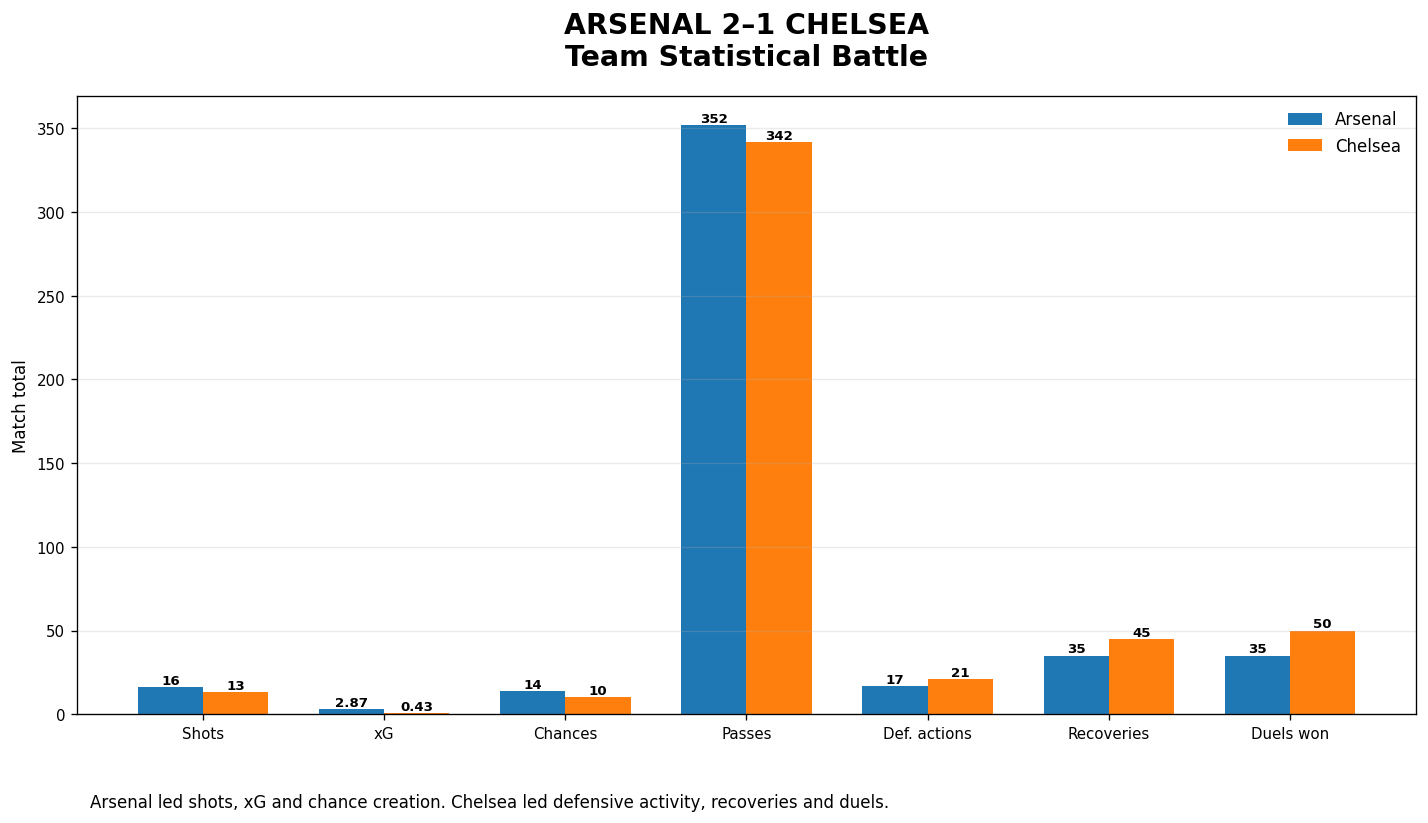


VISUAL 2 — CALIBRATED PLAYER RATINGS
------------------------------------------------------------------------------------------


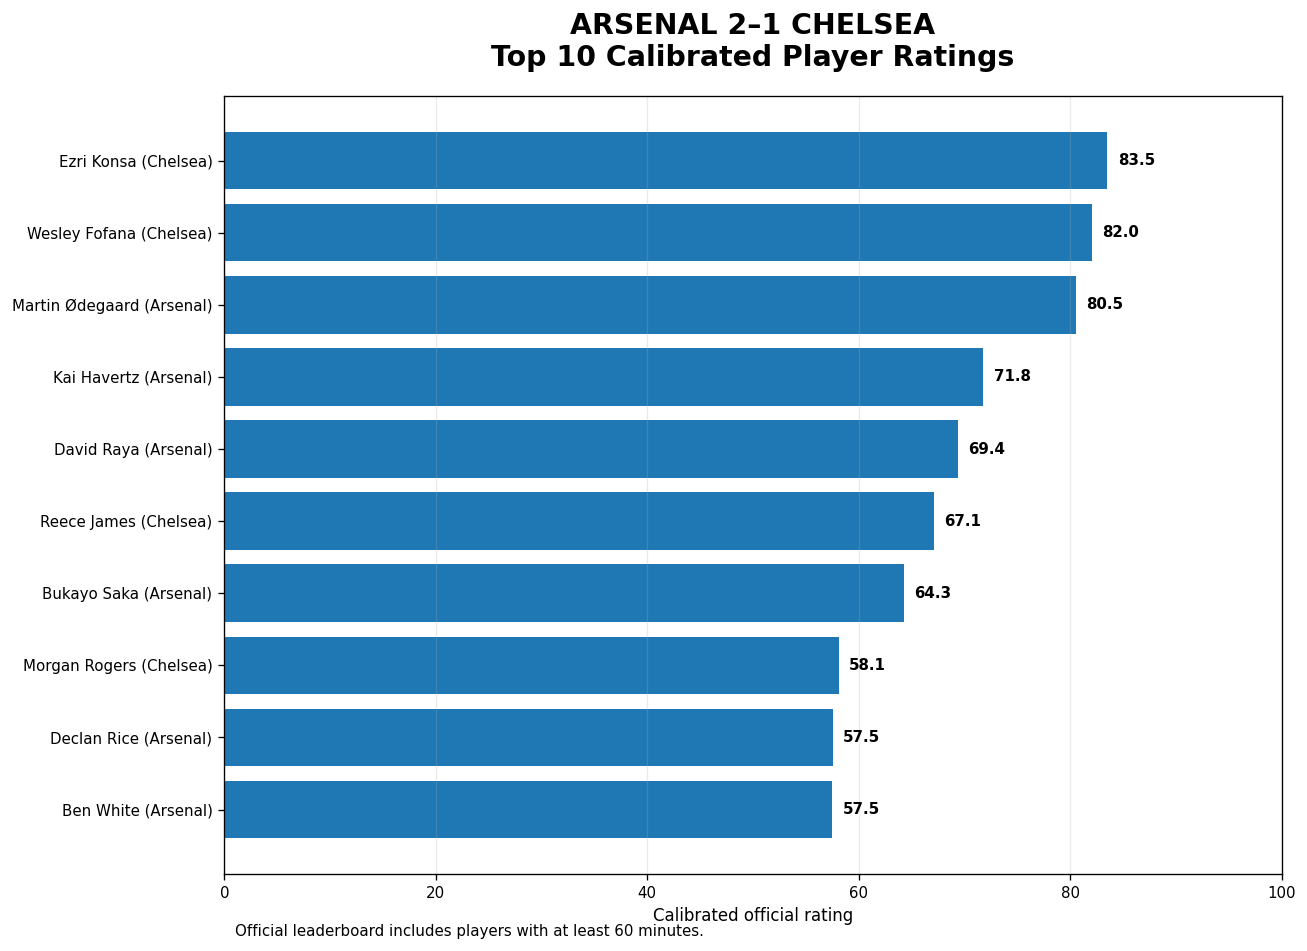


VISUAL 3 — ATTACKING CONTRIBUTIONS
------------------------------------------------------------------------------------------


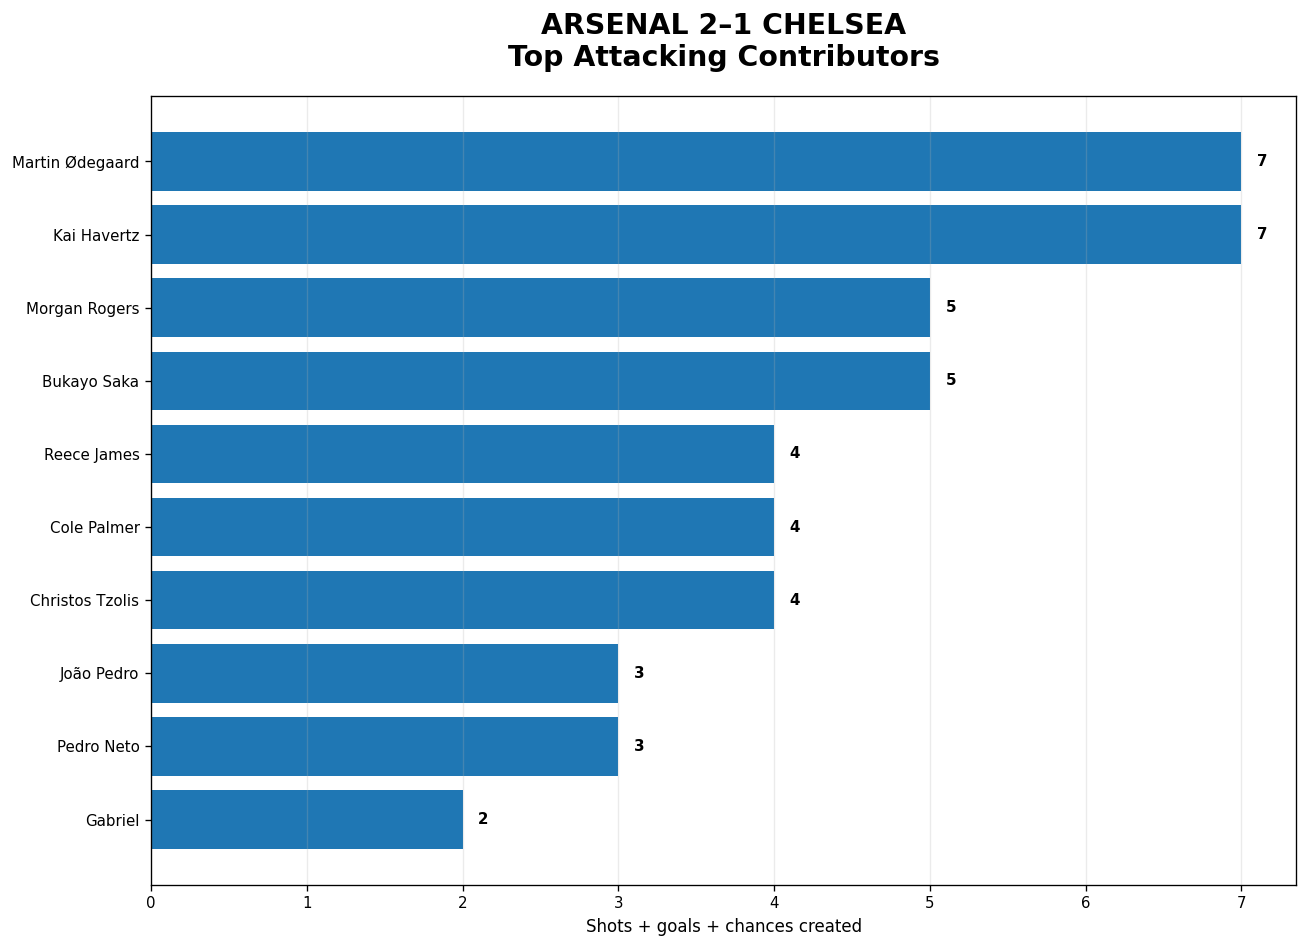


VISUAL 4 — DEFENSIVE CONTRIBUTIONS
------------------------------------------------------------------------------------------


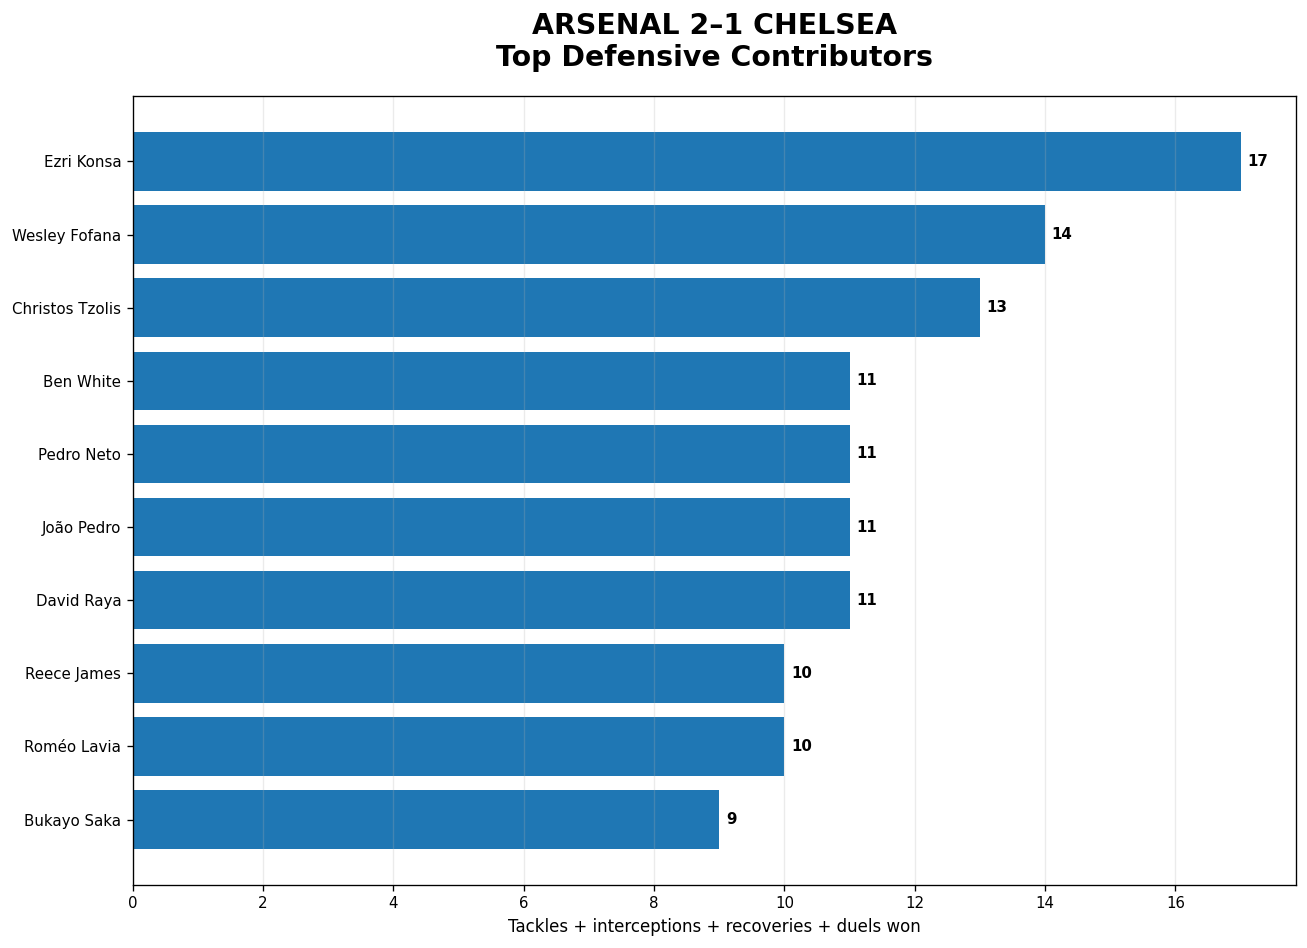


VISUAL 5 — POSITION GROUP RATINGS
------------------------------------------------------------------------------------------


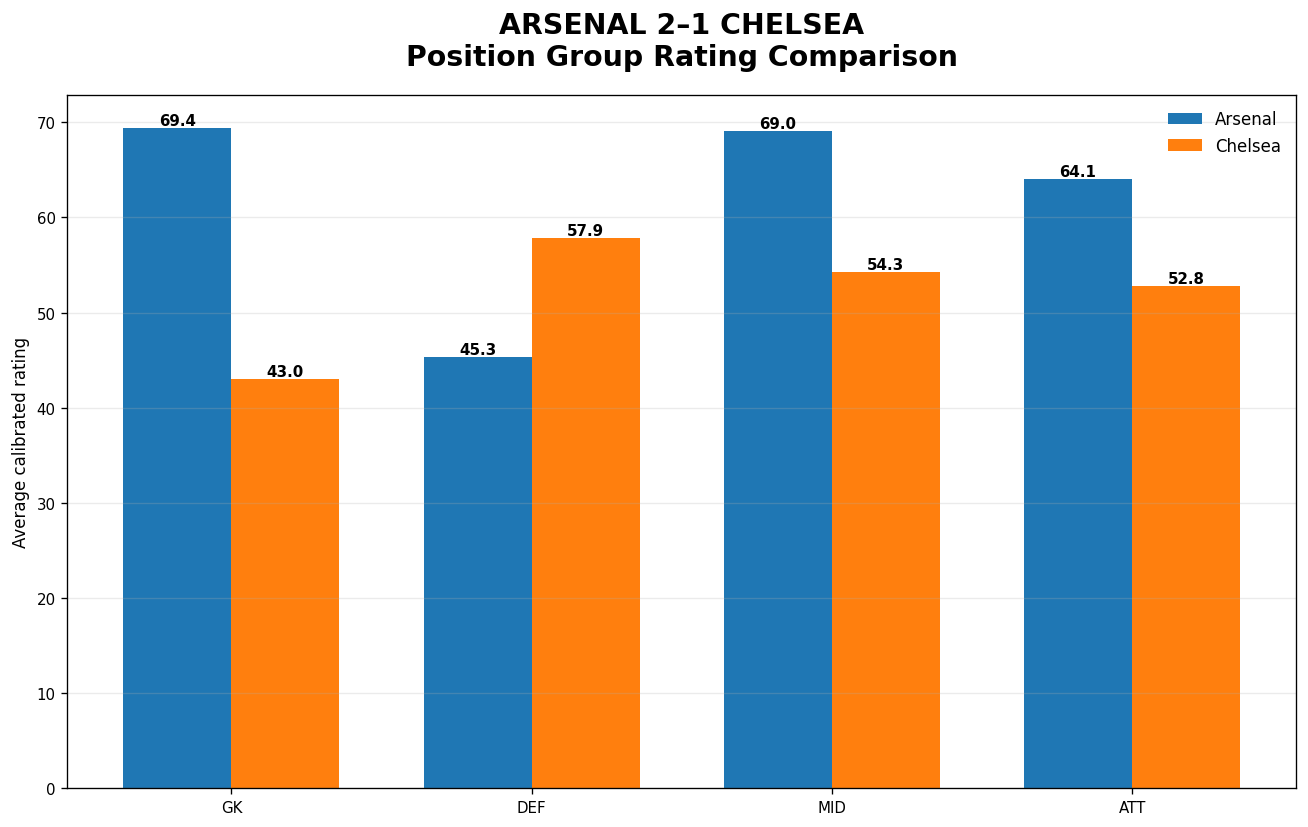


VISUAL 6 — PUBLICATION DASHBOARD
------------------------------------------------------------------------------------------


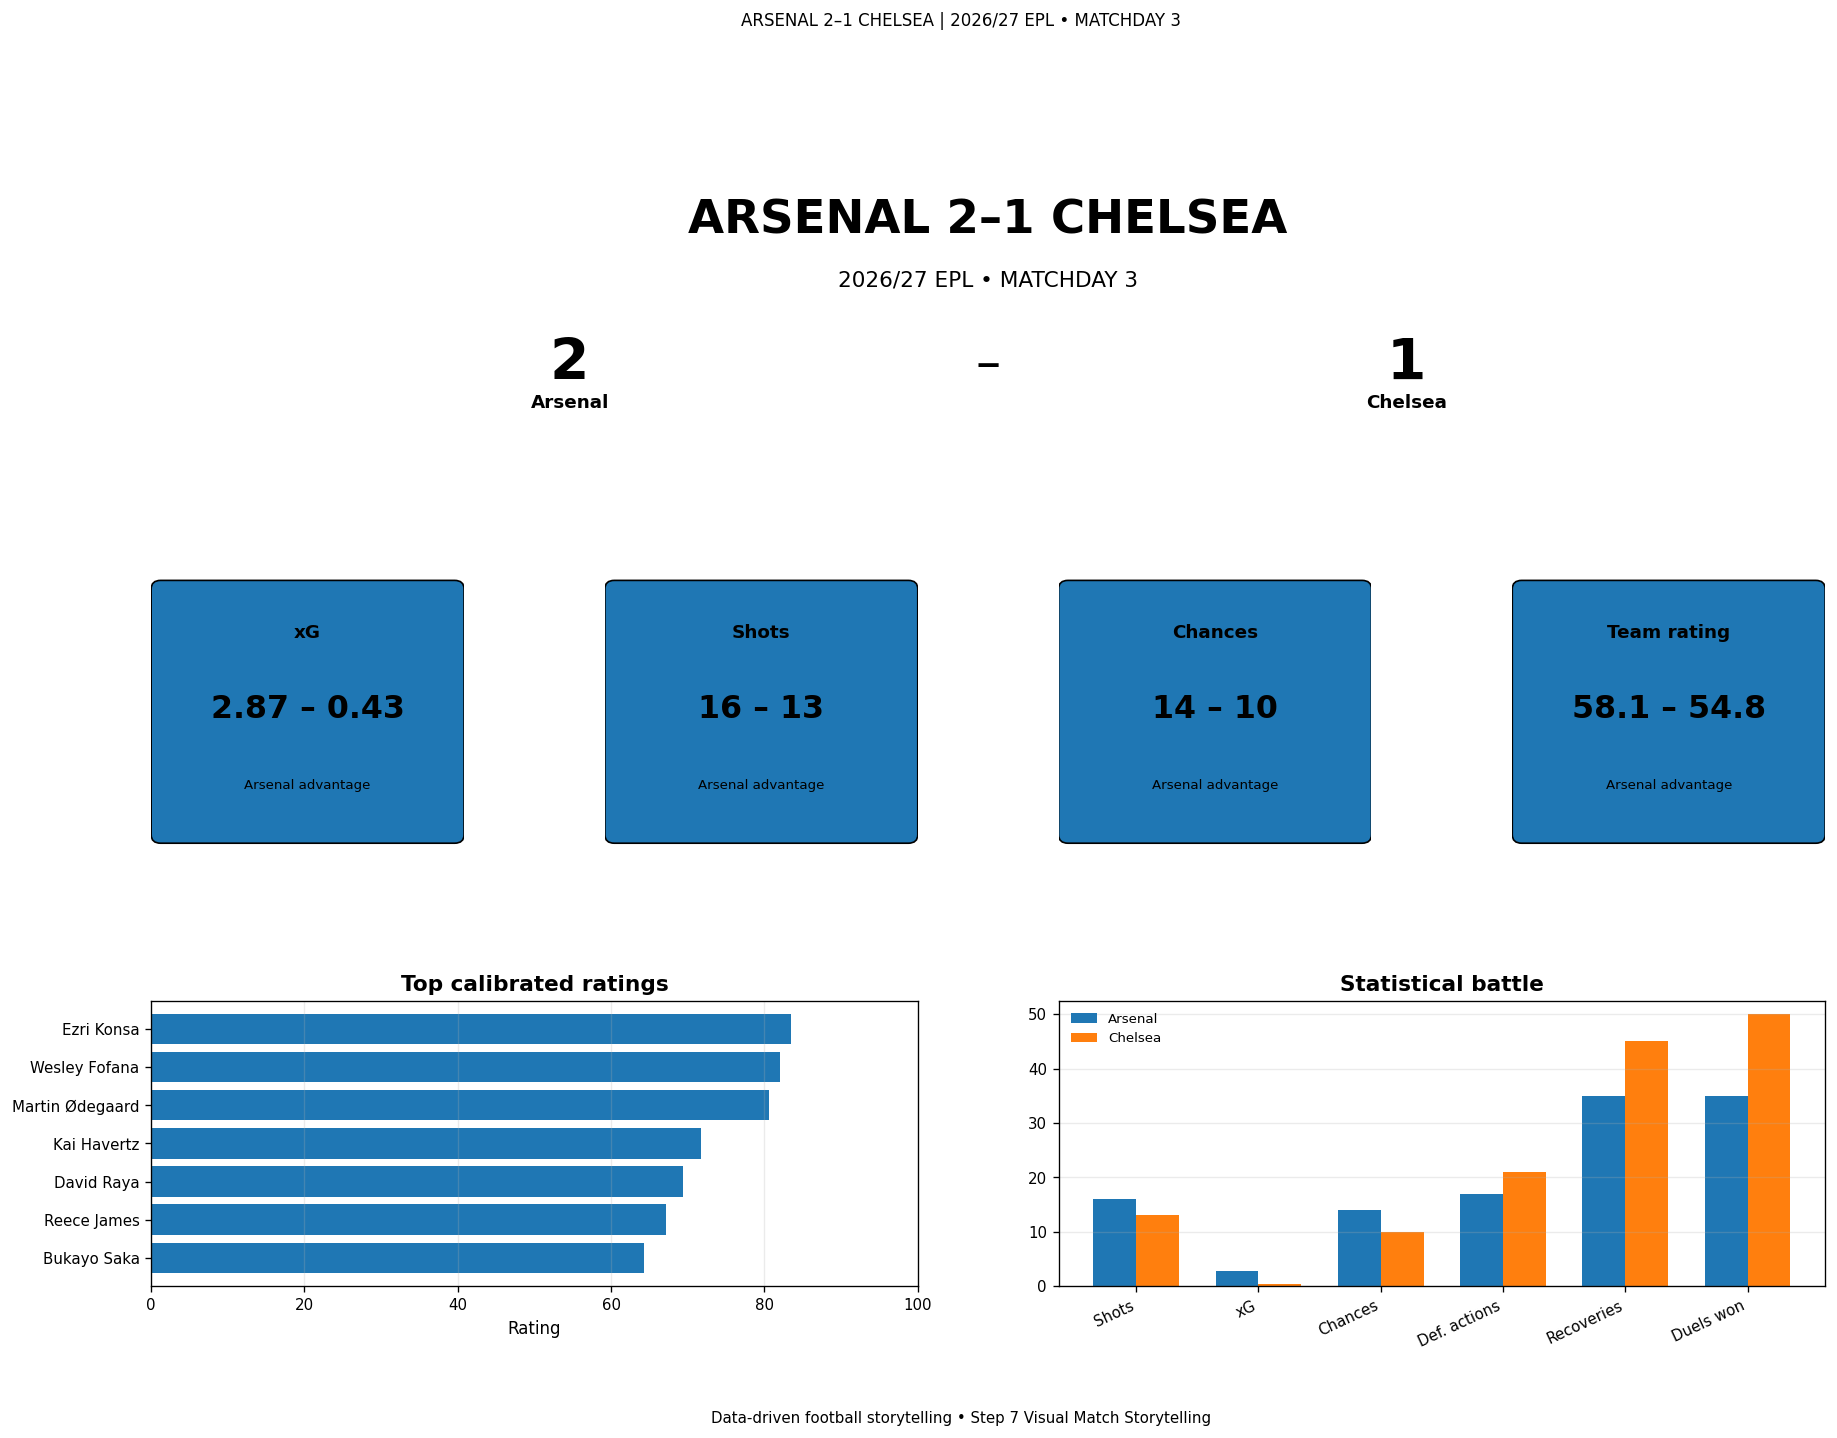


BUILDING STEP 7 VISUAL SUMMARY
------------------------------------------------------------------------------------------
              match  season competition  matchday                    metric   Arsenal   Chelsea  leader
ARSENAL 2–1 CHELSEA 2026/27         EPL         3                     Goals  2.000000  1.000000 Arsenal
ARSENAL 2–1 CHELSEA 2026/27         EPL         3                        xG  2.869600  0.430400 Arsenal
ARSENAL 2–1 CHELSEA 2026/27         EPL         3                     Shots 16.000000 13.000000 Arsenal
ARSENAL 2–1 CHELSEA 2026/27         EPL         3           Chances created 14.000000 10.000000 Arsenal
ARSENAL 2–1 CHELSEA 2026/27         EPL         3 Average calibrated rating 58.096365 54.759902 Arsenal
ARSENAL 2–1 CHELSEA 2026/27         EPL         3         Defensive actions 17.000000 21.000000 Chelsea
ARSENAL 2–1 CHELSEA 2026/27         EPL         3                Recoveries 35.000000 45.000000 Chelsea
ARSENAL 2–1 CHELSEA 2026/27         EPL      

In [30]:
# ==============================================================================
# ARSENAL 2–1 CHELSEA | 2026/27 EPL MATCHDAY 3
# STEP 7 — VISUAL MATCH STORYTELLING
# ==============================================================================
#
# PURPOSE
# ------------------------------------------------------------------------------
# Convert validated Step 6 match-level analysis into a publication-ready
# football analytics visual dashboard.
#
# INPUTS
# ------------------------------------------------------------------------------
# Arsenal_Chelsea_MD3_step6_match_story_players.csv
# Arsenal_Chelsea_MD3_step6_team_story.csv
# Arsenal_Chelsea_MD3_step6_position_story.csv
# Arsenal_Chelsea_MD3_step6_match_storyline.txt
#
# OUTPUTS
# ------------------------------------------------------------------------------
# Arsenal_Chelsea_MD3_step7_visual_dashboard.png
# Arsenal_Chelsea_MD3_step7_team_battle.png
# Arsenal_Chelsea_MD3_step7_player_ratings.png
# Arsenal_Chelsea_MD3_step7_attacking_contributions.png
# Arsenal_Chelsea_MD3_step7_defensive_contributions.png
# Arsenal_Chelsea_MD3_step7_position_groups.png
# Arsenal_Chelsea_MD3_step7_visual_summary.csv
# Arsenal_Chelsea_MD3_step7_visual_storyline.txt
#
# ==============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

# ==============================================================================
# CONFIGURATION
# ==============================================================================

MATCH_TITLE = "ARSENAL 2–1 CHELSEA"
MATCH_SUBTITLE = "2026/27 EPL • MATCHDAY 3"

HOME_TEAM = "Arsenal"
AWAY_TEAM = "Chelsea"

MIN_OFFICIAL_MINUTES = 60

PLAYER_FILE = "Arsenal_Chelsea_MD3_step6_match_story_players.csv"
TEAM_FILE = "Arsenal_Chelsea_MD3_step6_team_story.csv"
POSITION_FILE = "Arsenal_Chelsea_MD3_step6_position_story.csv"
STORY_FILE = "Arsenal_Chelsea_MD3_step6_match_storyline.txt"

OUTPUT_DASHBOARD = "Arsenal_Chelsea_MD3_step7_visual_dashboard.png"
OUTPUT_TEAM = "Arsenal_Chelsea_MD3_step7_team_battle.png"
OUTPUT_RATINGS = "Arsenal_Chelsea_MD3_step7_player_ratings.png"
OUTPUT_ATTACK = "Arsenal_Chelsea_MD3_step7_attacking_contributions.png"
OUTPUT_DEFENCE = "Arsenal_Chelsea_MD3_step7_defensive_contributions.png"
OUTPUT_POSITION = "Arsenal_Chelsea_MD3_step7_position_groups.png"
OUTPUT_SUMMARY = "Arsenal_Chelsea_MD3_step7_visual_summary.csv"
OUTPUT_STORY = "Arsenal_Chelsea_MD3_step7_visual_storyline.txt"

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def section(title):
    print("\n" + "=" * 90)
    print(title)
    print("-" * 90)


def safe_numeric(df, columns):
    """
    Convert selected columns to numeric where present.
    """
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def get_team_row(df, team):
    rows = df.loc[df["team"].eq(team)]

    if rows.empty:
        raise ValueError(f"Team '{team}' not found in team-level dataset.")

    return rows.iloc[0]


def add_value_label(ax, bar, value, fmt="{:.1f}", suffix=""):
    """
    Add a compact value label above/beside a bar.
    """
    width = bar.get_width()
    height = bar.get_height()

    if abs(width) > abs(height):
        x = width
        y = height

        ax.text(
            x,
            y,
            f"{fmt.format(value)}{suffix}",
            va="center",
            ha="left" if value >= 0 else "right",
            fontsize=9,
            fontweight="bold"
        )
    else:
        x = bar.get_x() + bar.get_width() / 2
        y = height

        ax.text(
            x,
            y,
            f"{fmt.format(value)}{suffix}",
            va="bottom",
            ha="center",
            fontsize=9,
            fontweight="bold"
        )


# ==============================================================================
# INPUT VALIDATION
# ==============================================================================

section("STEP 7 — INPUT DATA VALIDATION")

required_files = [
    PLAYER_FILE,
    TEAM_FILE,
    POSITION_FILE,
    STORY_FILE
]

missing_files = [f for f in required_files if not os.path.exists(f)]

if missing_files:
    raise FileNotFoundError(
        "The following required Step 6 files are missing:\n"
        + "\n".join(f"- {f}" for f in missing_files)
    )

for f in required_files:
    print(f"✓ FOUND: {f}")


# ==============================================================================
# LOAD STEP 6 OUTPUTS
# ==============================================================================

section("LOADING STEP 6 OUTPUTS")

players = pd.read_csv(PLAYER_FILE)
team_story = pd.read_csv(TEAM_FILE)
position_story = pd.read_csv(POSITION_FILE)

with open(STORY_FILE, "r", encoding="utf-8") as f:
    match_story_text = f.read()

print(f"Player rows    : {len(players)}")
print(f"Player columns : {len(players.columns)}")
print(f"Team rows      : {len(team_story)}")
print(f"Position rows  : {len(position_story)}")
print(f"Story chars    : {len(match_story_text)}")


# ==============================================================================
# NORMALISE NUMERIC COLUMNS
# ==============================================================================

numeric_player_columns = [
    "minutes",
    "calibrated_official_rating",
    "attacking_contribution",
    "defensive_contribution",
    "understat_shots",
    "understat_xG",
    "understat_goals",
    "chances_created",
    "understat_finishing_diff"
]

players = safe_numeric(players, numeric_player_columns)

numeric_team_columns = [
    "match_goals",
    "understat_shots",
    "understat_xG",
    "chances_created",
    "passes",
    "tackles",
    "interceptions",
    "recoveries",
    "total_duels_won",
    "defensive_actions_total",
    "understat_goals",
    "finishing_difference",
    "conversion_rate"
]

team_story = safe_numeric(team_story, numeric_team_columns)

numeric_position_columns = [
    "players",
    "average_rating",
    "average_xG",
    "total_xG",
    "total_shots",
    "chances_created",
    "defensive_actions",
    "recoveries",
    "duels_won",
    "Arsenal_average_rating",
    "Chelsea_average_rating",
    "rating_gap_Arsenal_minus_Chelsea"
]

position_story = safe_numeric(position_story, numeric_position_columns)


# ==============================================================================
# TEAM DATA
# ==============================================================================

section("TEAM MATCH PROFILE")

arsenal = get_team_row(team_story, HOME_TEAM)
chelsea = get_team_row(team_story, AWAY_TEAM)

arsenal_goals = float(arsenal["match_goals"])
chelsea_goals = float(chelsea["match_goals"])

arsenal_xg = float(arsenal["understat_xG"])
chelsea_xg = float(chelsea["understat_xG"])

arsenal_shots = float(arsenal["understat_shots"])
chelsea_shots = float(chelsea["understat_shots"])

arsenal_chances = float(arsenal["chances_created"])
chelsea_chances = float(chelsea["chances_created"])

print(f"{HOME_TEAM}: {int(arsenal_goals)} goals | {arsenal_xg:.2f} xG | {int(arsenal_shots)} shots")
print(f"{AWAY_TEAM}: {int(chelsea_goals)} goals | {chelsea_xg:.2f} xG | {int(chelsea_shots)} shots")


# ==============================================================================
# OFFICIAL PLAYER RATINGS
# ==============================================================================

official = players.loc[
    players["minutes"].ge(MIN_OFFICIAL_MINUTES)
    & players["calibrated_official_rating"].notna()
].copy()

official = official.sort_values(
    "calibrated_official_rating",
    ascending=False
)

print(f"\nOfficial-rated players: {len(official)}")

top_ratings = official.head(10).copy()


# ==============================================================================
# TOP ATTACKING CONTRIBUTORS
# ==============================================================================

attack_cols = [
    "player",
    "team",
    "understat_shots",
    "understat_xG",
    "understat_goals",
    "chances_created",
    "attacking_contribution"
]

attack_available = [c for c in attack_cols if c in players.columns]

top_attack = (
    players[attack_available]
    .copy()
    .sort_values(
        ["attacking_contribution", "understat_xG"],
        ascending=[False, False]
    )
    .head(10)
)


# ==============================================================================
# TOP DEFENSIVE CONTRIBUTORS
# ==============================================================================

defence_cols = [
    "player",
    "team",
    "tackles",
    "interceptions",
    "recoveries",
    "total_duels_won",
    "defensive_contribution",
    "calibrated_official_rating"
]

defence_available = [c for c in defence_cols if c in players.columns]

top_defence = (
    players[defence_available]
    .copy()
    .sort_values(
        "defensive_contribution",
        ascending=False
    )
    .head(10)
)


# ==============================================================================
# POSITION GROUP DATA
# ==============================================================================

position_order = ["GK", "DEF", "MID", "ATT"]

position_story = position_story.copy()

if "position" in position_story.columns:
    position_story["position"] = pd.Categorical(
        position_story["position"],
        categories=position_order,
        ordered=True
    )

position_story = position_story.sort_values(
    ["position", "team"]
)


# ==============================================================================
# VISUAL THEME
# ==============================================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120
})


# ==============================================================================
# VISUAL 1 — TEAM STATISTICAL BATTLE
# ==============================================================================

section("VISUAL 1 — TEAM STATISTICAL BATTLE")

battle_metrics = [
    ("Shots", "understat_shots"),
    ("xG", "understat_xG"),
    ("Chances", "chances_created"),
    ("Passes", "passes"),
    ("Def. actions", "defensive_actions_total"),
    ("Recoveries", "recoveries"),
    ("Duels won", "total_duels_won")
]

battle_df = pd.DataFrame([
    {
        "metric": label,
        HOME_TEAM: float(arsenal[col]),
        AWAY_TEAM: float(chelsea[col])
    }
    for label, col in battle_metrics
])

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(battle_df))
width = 0.36

bars1 = ax.bar(
    x - width / 2,
    battle_df[HOME_TEAM],
    width,
    label=HOME_TEAM
)

bars2 = ax.bar(
    x + width / 2,
    battle_df[AWAY_TEAM],
    width,
    label=AWAY_TEAM
)

ax.set_xticks(x)
ax.set_xticklabels(battle_df["metric"])
ax.set_title(
    f"{MATCH_TITLE}\nTeam Statistical Battle",
    fontsize=17,
    pad=18
)

ax.set_ylabel("Match total")
ax.legend(frameon=False)

ax.grid(
    axis="y",
    alpha=0.25
)

for bar in bars1:
    value = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}" if value < 10 else f"{value:.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

for bar in bars2:
    value = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}" if value < 10 else f"{value:.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

ax.text(
    0.01,
    -0.15,
    "Arsenal led shots, xG and chance creation. Chelsea led defensive activity, recoveries and duels.",
    transform=ax.transAxes,
    fontsize=10
)

plt.tight_layout()
plt.savefig(
    OUTPUT_TEAM,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==============================================================================
# VISUAL 2 — PLAYER RATINGS
# ==============================================================================

section("VISUAL 2 — CALIBRATED PLAYER RATINGS")

rating_df = top_ratings.copy()

rating_df["display_name"] = (
    rating_df["player"]
    + " ("
    + rating_df["team"]
    + ")"
)

rating_df = rating_df.sort_values(
    "calibrated_official_rating",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    rating_df["display_name"],
    rating_df["calibrated_official_rating"]
)

ax.set_xlim(0, 100)

ax.set_xlabel("Calibrated official rating")
ax.set_title(
    f"{MATCH_TITLE}\nTop 10 Calibrated Player Ratings",
    fontsize=17,
    pad=18
)

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, value in zip(
    bars,
    rating_df["calibrated_official_rating"]
):
    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.text(
    0.01,
    -0.08,
    "Official leaderboard includes players with at least 60 minutes.",
    transform=ax.transAxes,
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    OUTPUT_RATINGS,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==============================================================================
# VISUAL 3 — ATTACKING CONTRIBUTIONS
# ==============================================================================

section("VISUAL 3 — ATTACKING CONTRIBUTIONS")

attack_plot = top_attack.sort_values(
    "attacking_contribution",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    attack_plot["player"],
    attack_plot["attacking_contribution"]
)

ax.set_xlabel(
    "Shots + goals + chances created"
)

ax.set_title(
    f"{MATCH_TITLE}\nTop Attacking Contributors",
    fontsize=17,
    pad=18
)

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, value in zip(
    bars,
    attack_plot["attacking_contribution"]
):
    ax.text(
        value + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_ATTACK,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==============================================================================
# VISUAL 4 — DEFENSIVE CONTRIBUTIONS
# ==============================================================================

section("VISUAL 4 — DEFENSIVE CONTRIBUTIONS")

defence_plot = top_defence.sort_values(
    "defensive_contribution",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    defence_plot["player"],
    defence_plot["defensive_contribution"]
)

ax.set_xlabel(
    "Tackles + interceptions + recoveries + duels won"
)

ax.set_title(
    f"{MATCH_TITLE}\nTop Defensive Contributors",
    fontsize=17,
    pad=18
)

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, value in zip(
    bars,
    defence_plot["defensive_contribution"]
):
    ax.text(
        value + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_DEFENCE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==============================================================================
# VISUAL 5 — POSITION GROUP RATINGS
# ==============================================================================

section("VISUAL 5 — POSITION GROUP RATINGS")

position_rating = (
    position_story[
        [
            "position",
            "team",
            "average_rating"
        ]
    ]
    .dropna()
    .copy()
)

pivot_position = position_rating.pivot(
    index="position",
    columns="team",
    values="average_rating"
)

pivot_position = pivot_position.reindex(
    [p for p in position_order if p in pivot_position.index]
)

fig, ax = plt.subplots(figsize=(11, 7))

x = np.arange(len(pivot_position))
width = 0.36

arsenal_values = pivot_position[HOME_TEAM].values
chelsea_values = pivot_position[AWAY_TEAM].values

bars1 = ax.bar(
    x - width / 2,
    arsenal_values,
    width,
    label=HOME_TEAM
)

bars2 = ax.bar(
    x + width / 2,
    chelsea_values,
    width,
    label=AWAY_TEAM
)

ax.set_xticks(x)
ax.set_xticklabels(pivot_position.index)

ax.set_ylabel("Average calibrated rating")

ax.set_title(
    f"{MATCH_TITLE}\nPosition Group Rating Comparison",
    fontsize=17,
    pad=18
)

ax.legend(frameon=False)

ax.grid(
    axis="y",
    alpha=0.25
)

for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.tight_layout()
plt.savefig(
    OUTPUT_POSITION,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==============================================================================
# VISUAL 6 — PUBLICATION DASHBOARD
# ==============================================================================

section("VISUAL 6 — PUBLICATION DASHBOARD")

fig = plt.figure(figsize=(18, 12))

gs = fig.add_gridspec(
    3,
    4,
    height_ratios=[1.05, 1.25, 1.25],
    hspace=0.55,
    wspace=0.45
)


# ------------------------------------------------------------------------------
# HEADER
# ------------------------------------------------------------------------------

ax_header = fig.add_subplot(gs[0, :])
ax_header.axis("off")

ax_header.text(
    0.5,
    0.82,
    MATCH_TITLE,
    ha="center",
    va="center",
    fontsize=28,
    fontweight="bold"
)

ax_header.text(
    0.5,
    0.57,
    MATCH_SUBTITLE,
    ha="center",
    va="center",
    fontsize=13
)

ax_header.text(
    0.25,
    0.22,
    f"{int(arsenal_goals)}",
    ha="center",
    va="center",
    fontsize=34,
    fontweight="bold"
)

ax_header.text(
    0.5,
    0.22,
    "–",
    ha="center",
    va="center",
    fontsize=30
)

ax_header.text(
    0.75,
    0.22,
    f"{int(chelsea_goals)}",
    ha="center",
    va="center",
    fontsize=34,
    fontweight="bold"
)

ax_header.text(
    0.25,
    0.04,
    HOME_TEAM,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

ax_header.text(
    0.75,
    0.04,
    AWAY_TEAM,
    ha="center",
    fontsize=11,
    fontweight="bold"
)


# ------------------------------------------------------------------------------
# KPI CARDS
# ------------------------------------------------------------------------------

kpis = [
    (
        "xG",
        f"{arsenal_xg:.2f} – {chelsea_xg:.2f}",
        "Arsenal advantage"
    ),
    (
        "Shots",
        f"{int(arsenal_shots)} – {int(chelsea_shots)}",
        "Arsenal advantage"
    ),
    (
        "Chances",
        f"{int(arsenal_chances)} – {int(chelsea_chances)}",
        "Arsenal advantage"
    ),
    (
        "Team rating",
        f"{official.loc[official.team.eq(HOME_TEAM), 'calibrated_official_rating'].mean():.1f} – "
        f"{official.loc[official.team.eq(AWAY_TEAM), 'calibrated_official_rating'].mean():.1f}",
        "Arsenal advantage"
    )
]

for i, (label, value, note) in enumerate(kpis):

    ax = fig.add_subplot(gs[1, i])
    ax.axis("off")

    card = FancyBboxPatch(
        (0.02, 0.05),
        0.96,
        0.88,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=1
    )

    ax.add_patch(card)

    ax.text(
        0.5,
        0.75,
        label,
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.47,
        value,
        ha="center",
        fontsize=19,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.22,
        note,
        ha="center",
        fontsize=8
    )


# ------------------------------------------------------------------------------
# RATINGS PANEL
# ------------------------------------------------------------------------------

ax_rating = fig.add_subplot(gs[2, 0:2])

rating_short = top_ratings.head(7).copy()
rating_short = rating_short.sort_values(
    "calibrated_official_rating"
)

ax_rating.barh(
    rating_short["player"],
    rating_short["calibrated_official_rating"]
)

ax_rating.set_xlim(0, 100)
ax_rating.set_title(
    "Top calibrated ratings",
    fontsize=13,
    fontweight="bold"
)

ax_rating.set_xlabel("Rating")
ax_rating.grid(axis="x", alpha=0.25)


# ------------------------------------------------------------------------------
# TEAM BATTLE PANEL
# ------------------------------------------------------------------------------

ax_battle = fig.add_subplot(gs[2, 2:])

battle_short = battle_df[
    battle_df["metric"].isin(
        [
            "Shots",
            "xG",
            "Chances",
            "Def. actions",
            "Recoveries",
            "Duels won"
        ]
    )
].copy()

x = np.arange(len(battle_short))
width = 0.35

ax_battle.bar(
    x - width / 2,
    battle_short[HOME_TEAM],
    width,
    label=HOME_TEAM
)

ax_battle.bar(
    x + width / 2,
    battle_short[AWAY_TEAM],
    width,
    label=AWAY_TEAM
)

ax_battle.set_xticks(x)
ax_battle.set_xticklabels(
    battle_short["metric"],
    rotation=25,
    ha="right"
)

ax_battle.set_title(
    "Statistical battle",
    fontsize=13,
    fontweight="bold"
)

ax_battle.legend(
    frameon=False,
    fontsize=8
)

ax_battle.grid(
    axis="y",
    alpha=0.25
)


# ------------------------------------------------------------------------------
# FOOTER
# ------------------------------------------------------------------------------

fig.text(
    0.5,
    0.015,
    "Data-driven football storytelling • Step 7 Visual Match Storytelling",
    ha="center",
    fontsize=9
)

fig.suptitle(
    f"{MATCH_TITLE} | {MATCH_SUBTITLE}",
    fontsize=10,
    y=0.995
)

plt.savefig(
    OUTPUT_DASHBOARD,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==============================================================================
# BUILD VISUAL SUMMARY DATASET
# ==============================================================================

section("BUILDING STEP 7 VISUAL SUMMARY")

team_rating_home = official.loc[
    official["team"].eq(HOME_TEAM),
    "calibrated_official_rating"
].mean()

team_rating_away = official.loc[
    official["team"].eq(AWAY_TEAM),
    "calibrated_official_rating"
].mean()

summary_rows = [
    {
        "match": MATCH_TITLE,
        "season": "2026/27",
        "competition": "EPL",
        "matchday": 3,
        "metric": "Goals",
        "Arsenal": arsenal_goals,
        "Chelsea": chelsea_goals,
        "leader": HOME_TEAM if arsenal_goals > chelsea_goals else AWAY_TEAM
    },
    {
        "match": MATCH_TITLE,
        "season": "2026/27",
        "competition": "EPL",
        "matchday": 3,
        "metric": "xG",
        "Arsenal": arsenal_xg,
        "Chelsea": chelsea_xg,
        "leader": HOME_TEAM if arsenal_xg > chelsea_xg else AWAY_TEAM
    },
    {
        "match": MATCH_TITLE,
        "season": "2026/27",
        "competition": "EPL",
        "matchday": 3,
        "metric": "Shots",
        "Arsenal": arsenal_shots,
        "Chelsea": chelsea_shots,
        "leader": HOME_TEAM if arsenal_shots > chelsea_shots else AWAY_TEAM
    },
    {
        "match": MATCH_TITLE,
        "season": "2026/27",
        "competition": "EPL",
        "matchday": 3,
        "metric": "Chances created",
        "Arsenal": arsenal_chances,
        "Chelsea": chelsea_chances,
        "leader": HOME_TEAM if arsenal_chances > chelsea_chances else AWAY_TEAM
    },
    {
        "match": MATCH_TITLE,
        "season": "2026/27",
        "competition": "EPL",
        "matchday": 3,
        "metric": "Average calibrated rating",
        "Arsenal": team_rating_home,
        "Chelsea": team_rating_away,
        "leader": HOME_TEAM if team_rating_home > team_rating_away else AWAY_TEAM
    },
    {
        "match": MATCH_TITLE,
        "season": "2026/27",
        "competition": "EPL",
        "matchday": 3,
        "metric": "Defensive actions",
        "Arsenal": float(arsenal["defensive_actions_total"]),
        "Chelsea": float(chelsea["defensive_actions_total"]),
        "leader": HOME_TEAM
        if arsenal["defensive_actions_total"] > chelsea["defensive_actions_total"]
        else AWAY_TEAM
    },
    {
        "match": MATCH_TITLE,
        "season": "2026/27",
        "competition": "EPL",
        "matchday": 3,
        "metric": "Recoveries",
        "Arsenal": float(arsenal["recoveries"]),
        "Chelsea": float(chelsea["recoveries"]),
        "leader": HOME_TEAM
        if arsenal["recoveries"] > chelsea["recoveries"]
        else AWAY_TEAM
    },
    {
        "match": MATCH_TITLE,
        "season": "2026/27",
        "competition": "EPL",
        "matchday": 3,
        "metric": "Duels won",
        "Arsenal": float(arsenal["total_duels_won"]),
        "Chelsea": float(chelsea["total_duels_won"]),
        "leader": HOME_TEAM
        if arsenal["total_duels_won"] > chelsea["total_duels_won"]
        else AWAY_TEAM
    }
]

visual_summary = pd.DataFrame(summary_rows)

visual_summary.to_csv(
    OUTPUT_SUMMARY,
    index=False
)

print(visual_summary.to_string(index=False))


# ==============================================================================
# BUILD STEP 7 VISUAL STORYLINE
# ==============================================================================

section("BUILDING STEP 7 VISUAL STORYLINE")

rating_gap = team_rating_home - team_rating_away
xg_gap = arsenal_xg - chelsea_xg
shot_gap = arsenal_shots - chelsea_shots
chance_gap = arsenal_chances - chelsea_chances

storyline = f"""
{MATCH_TITLE} | {MATCH_SUBTITLE}

STEP 7 — VISUAL MATCH STORY

MATCH RESULT
Arsenal defeated Chelsea 2–1.

ATTACKING CONTROL
Arsenal generated {arsenal_xg:.2f} xG from {int(arsenal_shots)} shots,
compared with Chelsea's {chelsea_xg:.2f} xG from {int(chelsea_shots)} shots.

Arsenal therefore held an xG advantage of {xg_gap:.2f}.

Arsenal also created {int(arsenal_chances)} chances compared with
Chelsea's {int(chelsea_chances)}, a difference of {chance_gap:.0f}.

PLAYER PERFORMANCE
Ezri Konsa was the highest-rated official player at 83.51.

Martin Ødegaard was Arsenal's highest-rated player at 80.53.

TEAM RATING PROFILE
Arsenal's official-rated players averaged {team_rating_home:.2f},
while Chelsea's averaged {team_rating_away:.2f}.

This produced a calibrated team-rating advantage of {rating_gap:.2f}
for Arsenal.

DEFENSIVE CONTRAST
Chelsea recorded stronger defensive activity, including more recoveries
and more total duels won.

The match therefore presents a useful contrast:
Arsenal produced the stronger attacking profile, while Chelsea showed
greater defensive activity and stronger individual defensive ratings.

FINISHING
Arsenal finished at {float(arsenal["finishing_difference"]):+.2f} goals
relative to xG.

Chelsea finished at {float(chelsea["finishing_difference"]):+.2f} goals
relative to xG.

The stronger finishing differential therefore belonged to Chelsea,
despite Arsenal winning the match.

VISUAL CONCLUSION
The visual evidence supports a nuanced match narrative:

Arsenal's victory was driven primarily by superior attacking threat,
chance creation and expected-goal production.

Chelsea remained competitive through defensive activity, recoveries,
duels and elite individual defensive performances.

The match should therefore be interpreted through the combination of
result, xG, shot volume, chance creation, defensive activity,
position-group ratings and calibrated player ratings rather than
through any single metric.
""".strip()

with open(
    OUTPUT_STORY,
    "w",
    encoding="utf-8"
) as f:
    f.write(storyline)

print(storyline)


# ==============================================================================
# STEP 7 VALIDATION
# ==============================================================================

section("STEP 7 VALIDATION")

validation_passed = True

# Player count
if len(players) == 31:
    print("PASS — Player count preserved: 31")
else:
    print(f"FAIL — Expected 31 players, found {len(players)}")
    validation_passed = False

# Team count
if set(team_story["team"]) >= {HOME_TEAM, AWAY_TEAM}:
    print("PASS — Arsenal and Chelsea present")
else:
    print("FAIL — Missing one or both teams")
    validation_passed = False

# Official ratings
if official["minutes"].min() >= MIN_OFFICIAL_MINUTES:
    print("PASS — No sub-60-minute official ratings")
else:
    print("FAIL — Sub-60-minute player found in official ratings")
    validation_passed = False

# Rating range
if official["calibrated_official_rating"].between(0, 100).all():
    print("PASS — Official ratings remain 0–100")
else:
    print("FAIL — Rating outside 0–100")
    validation_passed = False

# Team story
if len(team_story) == 2:
    print("PASS — Team-level visual story available")
else:
    print("FAIL — Team-level visual story invalid")
    validation_passed = False

# Position story
if not position_story.empty:
    print("PASS — Position-level visual story available")
else:
    print("FAIL — Position-level visual story empty")
    validation_passed = False

# xG
if arsenal_xg > chelsea_xg:
    print("PASS — Arsenal xG advantage confirmed")
else:
    print("WARNING — Arsenal does not lead xG")

# Actual result
if arsenal_goals > chelsea_goals:
    print("PASS — Arsenal actual result confirmed")
else:
    print("FAIL — Match result inconsistent")
    validation_passed = False

# Output files
output_files = [
    OUTPUT_DASHBOARD,
    OUTPUT_TEAM,
    OUTPUT_RATINGS,
    OUTPUT_ATTACK,
    OUTPUT_DEFENCE,
    OUTPUT_POSITION,
    OUTPUT_SUMMARY,
    OUTPUT_STORY
]

for filename in output_files:
    if os.path.exists(filename):
        print(f"PASS — Output created: {filename}")
    else:
        print(f"FAIL — Output missing: {filename}")
        validation_passed = False


# ==============================================================================
# FINAL STATUS
# ==============================================================================

section("STEP 7 FINAL STATUS")

if validation_passed:
    print("✓ STEP 7 VALIDATION PASSED")
    print("✓ VISUAL MATCH STORYTELLING COMPLETE")
else:
    print("⚠ STEP 7 COMPLETED WITH VALIDATION WARNINGS")

print("\nOUTPUT FILES")
print("-" * 90)

for filename in output_files:
    if os.path.exists(filename):
        size_kb = os.path.getsize(filename) / 1024
        print(f"✓ {filename:<65} {size_kb:>8.1f} KB")

print("\n" + "=" * 90)
print("STEP 7 COMPLETE")
print("=" * 90)